# Proyek Analisis Data: Air Quality Dataset
- **Nama:** Alfian Aldy Hamdani
- **Email:** alfian.hamdani04@gmail.com
- **ID Dicoding:** alfianaldyhamdani

## Menentukan Pertanyaan Bisnis

### Penjelasan

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

### Contoh


**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

### Pertanyaan


Specific:
1. Faktor apa saja yang memengaruhi tingginya konsentrasi polutan (PM2.5 & PM10)?

Measurable:
1. Berapa persentase kenaikan tiap parameter kualitas udara tiap tahun?

Action-Oriented:
1. Pada staion manakah yang memiliki kualitas udara paling parah?

Relevant:
1. Parameter kualitas udara apa yang paling parah persentase kenaikannya?

Time-bound:
1. Di setiap bulan berapakah kualitas udara paling buruk di setiap tahunnya di setiap station dari tahun 2013-2017?

Pertanyaan:
1. **Pertanyaan 1:** Faktor apa saja yang memengaruhi tingginya konsentrasi polutan di setiap station tiap tahun?
1. **Pertanyaan 2:** Apakah konsentrasi rata-rata polutan menunjukkan perbaikan kualitas udara dari 2013-207 di setiap station?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import zipfile
import glob
import os
import re

## Data Wrangling

### Gathering Data

#### Download and unzip data

In [2]:
!gdown 1RhU3gJlkteaAQfyn9XOVAz7a5o1-etgr

Downloading...
From: https://drive.google.com/uc?id=1RhU3gJlkteaAQfyn9XOVAz7a5o1-etgr
To: /content/Air-quality-dataset.zip
100% 7.96M/7.96M [00:00<00:00, 17.5MB/s]


In [3]:
with zipfile.ZipFile('Air-quality-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('Air-quality-dataset')

#### Data insight

In [4]:
csv_files = glob.glob(
    '/content/Air-quality-dataset/**/**.csv',
    recursive=True
)
df_list = {}

for file_path in csv_files:
    # get file name
    file_name = os.path.basename(file_path)

    # get name with regex
    regex_search = re.search(r'PRSA_Data_(.*?)_', file_name)
    df_name = regex_search.group(1).lower()

    df_list[df_name] = pd.read_csv(file_path)

df_list.keys()

dict_keys(['changping', 'gucheng', 'guanyuan', 'wanliu', 'dongsi', 'dingling', 'huairou', 'wanshouxigong', 'aotizhongxin', 'nongzhanguan', 'tiantan', 'shunyi'])

In [5]:
df_list['aotizhongxin'].head(25)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin
5,6,2013,3,1,5,5.0,5.0,18.0,18.0,400.0,66.0,-2.2,1025.6,-19.6,0.0,N,3.7,Aotizhongxin
6,7,2013,3,1,6,3.0,3.0,18.0,32.0,500.0,50.0,-2.6,1026.5,-19.1,0.0,NNE,2.5,Aotizhongxin
7,8,2013,3,1,7,3.0,6.0,19.0,41.0,500.0,43.0,-1.6,1027.4,-19.1,0.0,NNW,3.8,Aotizhongxin
8,9,2013,3,1,8,3.0,6.0,16.0,43.0,500.0,45.0,0.1,1028.3,-19.2,0.0,NNW,4.1,Aotizhongxin
9,10,2013,3,1,9,3.0,8.0,12.0,28.0,400.0,59.0,1.2,1028.5,-19.3,0.0,N,2.6,Aotizhongxin


##### Insight

1. Data direkam per jam setiap hari
1. Parameter kualitas udara yang direkam adalah
    - PM2.5 dan PM10
    - Sulfur Dioksida (SO2)
    - Nitrogen Dioksida (NO2)
    - Karbon Monoksida (CO)
    - Ozon Permukaan (03)
    - Suhu udara (TEMP / Temperature)
    - Tekanan udara (PRES / Pressure)
    - Titik embun (DEWP / Dew point)
    - Curah hujan (RAIN)
    - Arah angin (wd / Wind direction)
    - Kecepatan angin (WSPM / Wind Speed per Meter/Second)
1. Variabel dibagi menjadi 3:
    - Variabel utama: PM2.5, PM10
    - Variabel kedua: SO2, NO2, CO, O3
    - Variabel pendukung: temp, pres, dewp, rain, wd, wspm
1. Wind Direction terbagi menjadi 16:

| Singkatan | Kepanjangan         |
|-----------|---------------------|
| N         | North               |
| E         | East                |
| S         | South               |
| W         | West                |
| NE        | Northeast           |
| SE        | Southeast           |
| SW        | Southwest           |
| NW        | Northwest           |
| NNE       | North-Northeast     |
| ENE       | East-Northeast      |
| ESE       | East-Southeast      |
| SSE       | South-Southeast     |
| SSW       | South-Southwest     |
| WSW       | West-Southwest      |
| WNW       | West-Northwest      |
| NNW       | North-Northwest     |


### Assessing Data

#### Check headers

In [6]:
def is_all_df_have_same_header(df_list, selected_city_for_guide = 'aotizhongxin'):
    headers_guide = set(list(df_list[selected_city_for_guide]))

    for key, value in df_list.items():
        if key is selected_city_for_guide: continue

        df_headers = set(list(value))

        if df_headers != headers_guide:
            print(f"Header in {key} doesn't match with {selected_city_for_guide}")
            return False

    return True


if is_all_df_have_same_header(df_list):
    print("All df have same header")
else:
    print("Not all df have same header")

All df have same header


#### Assessing data

In [7]:
def assessing_data(df_list):
    for key, value in df_list.items():
        print(key)

        print(f"""Info: {value.info()}\n
Duplicated: {value.duplicated().sum()}\n
isna: \n{value.isna().sum()}\n""")

        print("=========================================================")

In [8]:
assessing_data(df_list)

changping
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   No       35064 non-null  int64  
 1   year     35064 non-null  int64  
 2   month    35064 non-null  int64  
 3   day      35064 non-null  int64  
 4   hour     35064 non-null  int64  
 5   PM2.5    34290 non-null  float64
 6   PM10     34482 non-null  float64
 7   SO2      34436 non-null  float64
 8   NO2      34397 non-null  float64
 9   CO       33543 non-null  float64
 10  O3       34460 non-null  float64
 11  TEMP     35011 non-null  float64
 12  PRES     35014 non-null  float64
 13  DEWP     35011 non-null  float64
 14  RAIN     35013 non-null  float64
 15  wd       34924 non-null  object 
 16  WSPM     35021 non-null  float64
 17  station  35064 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 4.8+ MB
Info: None

Duplicated: 0

isna: 
No            0
year    

In [281]:
primary_params = ['PM2.5', 'PM10']
secondary_params = ['SO2', 'NO2', 'CO', 'O3']
support_params = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
pollutant_params = primary_params + secondary_params
all_params = pollutant_params + support_params

#### Describe all dataframe

In [10]:
df_list['dongsi'].describe(include='all')

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34314.000000,34511.000000,34401.000000,33463.000000,31867.000000,34400.000000,35044.000000,35044.000000,35044.000000,35044.000000,34986,35050.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENE,NaN,Dongsi
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3861,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,86.194297,110.336742,18.531107,53.699443,1330.069131,57.210637,13.671490,1012.547419,2.447535,0.064020,NaN,1.860785,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,86.575127,98.219860,22.905655,33.959230,1191.305887,58.033275,11.458418,10.266059,13.810696,0.786282,NaN,1.280368,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.642600,-16.800000,987.100000,-35.300000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,4.000000,27.000000,600.000000,12.000000,3.100000,1004.000000,-8.800000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,61.000000,86.000000,10.000000,47.000000,1000.000000,44.125200,14.600000,1012.200000,3.000000,0.000000,NaN,1.500000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,119.000000,151.000000,24.000000,73.000000,1700.000000,81.000000,23.500000,1020.900000,15.000000,0.000000,NaN,2.400000,NaN


In [11]:
df_list['tiantan'].describe(include='all')

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34387.000000,34467.000000,33946.000000,34320.000000,33938.000000,34221.000000,35044.000000,35044.000000,35044.000000,35044.000000,34986,35050.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENE,NaN,Tiantan
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3861,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.164911,106.363672,14.367615,53.162646,1298.303318,55.984297,13.671490,1012.547419,2.447535,0.064020,NaN,1.860785,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,80.921384,89.700157,20.144631,31.946224,1170.593297,59.081528,11.458418,10.266059,13.810696,0.786282,NaN,1.280368,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.571200,2.000000,100.000000,0.428400,-16.800000,987.100000,-35.300000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,41.000000,3.000000,28.000000,500.000000,8.000000,3.100000,1004.000000,-8.800000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,85.000000,7.000000,47.000000,900.000000,40.000000,14.600000,1012.200000,3.000000,0.000000,NaN,1.500000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,113.000000,144.000000,17.000000,71.000000,1600.000000,81.000000,23.500000,1020.900000,15.000000,0.000000,NaN,2.400000,NaN


In [12]:
df_list['wanshouxigong'].describe(include='all')

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34368.000000,34580.000000,34395.000000,34310.00000,33767.000000,33986.000000,35045.000000,35045.000000,35045.000000,35045.000000,34985,35051.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,NaN,Wanshouxigong
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3568,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,85.024136,112.223459,17.148603,55.52956,1370.395031,56.229904,13.784477,1011.511804,2.707442,0.064320,NaN,1.745314,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,85.975981,97.593210,23.940834,35.80805,1223.139114,57.082710,11.385156,10.570928,13.704139,0.796981,NaN,1.206355,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.00000,100.000000,0.214200,-16.800000,985.100000,-35.300000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,39.000000,3.000000,28.00000,600.000000,8.000000,3.400000,1002.800000,-8.500000,0.000000,NaN,0.900000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,60.000000,91.000000,8.000000,49.00000,1000.000000,42.000000,14.800000,1011.000000,3.300000,0.000000,NaN,1.400000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,154.000000,21.000000,77.00000,1700.000000,82.000000,23.500000,1020.000000,15.200000,0.000000,NaN,2.300000,NaN


In [13]:
df_list['huairou'].describe(include='all')

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34111.000000,34287.000000,34084.000000,33425.000000,33642.000000,33913.000000,35013.000000,35011.000000,35011.000000,35009.000000,34762,35015.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NW,NaN,Huairou
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4943,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,69.626367,91.482690,12.121553,32.497250,1022.554545,59.824713,12.445426,1007.598568,2.238619,0.067940,NaN,1.652021,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,71.224916,83.289578,18.896912,26.489531,898.738241,54.605746,11.751103,10.022101,14.052541,0.849046,NaN,1.199143,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.800000,-43.400000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,17.000000,28.000000,2.000000,12.000000,400.000000,18.000000,2.100000,999.300000,-9.600000,0.000000,NaN,0.900000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,47.000000,69.000000,4.000000,25.000000,800.000000,49.000000,13.600000,1007.300000,2.700000,0.000000,NaN,1.300000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,98.000000,131.000000,14.000000,46.000000,1300.000000,83.000000,22.300000,1015.500000,15.300000,0.000000,NaN,2.000000,NaN


In [14]:
df_list['guanyuan'].describe(include='all')

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34448.000000,34635.000000,34590.000000,34405.000000,33311.000000,33891.000000,35044.000000,35044.000000,35044.000000,35044.000000,34983,35050.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,NaN,Guanyuan
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5140,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.933372,109.023303,17.590941,57.901643,1271.294377,55.795044,13.584607,1011.846920,3.123062,0.067421,NaN,1.708496,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,80.933497,91.573709,23.600367,35.150857,1164.854945,57.436983,11.399097,10.404047,13.688896,0.910056,NaN,1.204071,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,1.000000,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,40.000000,3.000000,31.000000,500.000000,7.000000,3.100000,1003.300000,-8.100000,0.000000,NaN,0.900000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,89.000000,8.000000,51.000000,900.000000,41.000000,14.500000,1011.400000,3.800000,0.000000,NaN,1.400000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,115.000000,149.000000,22.000000,78.000000,1600.000000,81.000000,23.300000,1020.100000,15.600000,0.000000,NaN,2.200000,NaN


In [15]:
df_list['shunyi'].describe(include='all')

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34151.000000,34516.000000,33768.000000,33699.000000,32886.000000,33575.000000,35013.000000,35013.000000,35010.000000,35013.000000,34581,35020.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NNE,NaN,Shunyi
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4540,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.491602,98.737026,13.572039,43.908865,1187.063979,55.201321,13.387969,1013.061938,2.465036,0.061094,NaN,1.807533,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,81.231739,89.143718,19.572068,30.996828,1156.374102,54.873726,11.483588,10.177339,13.726622,0.761668,NaN,1.287817,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,988.000000,-36.000000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,19.000000,31.000000,2.000000,19.000000,400.000000,10.000000,3.000000,1004.700000,-8.800000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,77.000000,5.000000,37.000000,800.000000,43.000000,14.400000,1012.700000,3.100000,0.000000,NaN,1.500000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,112.000000,138.000000,17.000000,62.000000,1500.000000,77.000000,23.200000,1021.000000,15.100000,0.000000,NaN,2.300000,NaN


In [16]:
df_list['nongzhanguan'].describe(include='all')

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34436.000000,34624.000000,34618.000000,34372.000000,33858.000000,34558.000000,35044.000000,35044.000000,35044.000000,35044.000000,34986,35050.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ENE,NaN,Nongzhanguan
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3861,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,84.838483,108.991096,18.689242,58.097172,1324.350198,58.534682,13.671490,1012.547419,2.447535,0.064020,NaN,1.860785,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,86.225344,95.341177,24.280665,36.297740,1245.166124,58.401448,11.458418,10.266059,13.810696,0.786282,NaN,1.280368,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.571200,2.000000,100.000000,0.214200,-16.800000,987.100000,-35.300000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,29.000000,500.000000,10.000000,3.100000,1004.000000,-8.800000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,85.000000,9.000000,51.000000,900.000000,45.000000,14.600000,1012.200000,3.000000,0.000000,NaN,1.500000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,149.000000,23.000000,80.000000,1600.000000,84.000000,23.500000,1020.900000,15.000000,0.000000,NaN,2.400000,NaN


In [17]:
df_list['aotizhongxin'].describe(include='all')

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34139.000000,34346.000000,34129.000000,34041.000000,33288.000000,33345.000000,35044.000000,35044.000000,35044.000000,35044.000000,34983,35050.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,NaN,Aotizhongxin
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5140,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,82.773611,110.060391,17.375901,59.305833,1262.945145,56.353358,13.584607,1011.846920,3.123062,0.067421,NaN,1.708496,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.135694,95.223005,22.823017,37.116200,1221.436236,57.916327,11.399097,10.404047,13.688896,0.910056,NaN,1.204071,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.900000,-35.300000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,22.000000,38.000000,3.000000,30.000000,500.000000,8.000000,3.100000,1003.300000,-8.100000,0.000000,NaN,0.900000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,58.000000,87.000000,9.000000,53.000000,900.000000,42.000000,14.500000,1011.400000,3.800000,0.000000,NaN,1.400000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,114.000000,155.000000,21.000000,82.000000,1500.000000,82.000000,23.300000,1020.100000,15.600000,0.000000,NaN,2.200000,NaN


In [18]:
df_list['gucheng'].describe(include='all')

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34418.000000,34683.000000,34557.000000,34396.000000,33663.000000,34335.000000,35013.000000,35014.000000,35013.000000,35021.000000,34905,35022.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,Gucheng
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3949,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,83.852089,118.861978,15.366162,55.871075,1323.974423,57.694879,13.864524,1008.829592,2.610442,0.064453,NaN,1.343310,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,82.796445,96.742626,21.204526,36.473860,1208.957772,57.019587,11.292857,10.103256,13.782991,0.838654,NaN,1.151064,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-15.600000,984.000000,-34.600000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,24.000000,45.000000,2.000000,26.000000,600.000000,10.000000,3.600000,1000.500000,-8.900000,0.000000,NaN,0.600000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,60.000000,99.000000,7.000000,50.000000,900.000000,45.000000,14.800000,1008.500000,3.000000,0.000000,NaN,1.000000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,115.750000,167.000000,20.000000,79.000000,1600.000000,83.000000,23.500000,1017.000000,15.300000,0.000000,NaN,1.800000,NaN


In [19]:
df_list['wanliu'].describe(include='all')

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34682.000000,34780.000000,34489.000000,33994.000000,33252.000000,32957.000000,35044.000000,35044.000000,35044.000000,35044.000000,34941,35050.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,NaN,Wanliu
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6703,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,83.374716,110.464618,18.376481,65.258789,1319.353513,48.873614,13.428865,1011.097536,3.266588,0.068263,NaN,1.501215,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,81.905568,92.795065,22.609648,37.996088,1268.114331,55.111740,11.346931,10.355247,13.678060,0.896726,NaN,1.104472,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.642400,100.000000,0.214200,-15.800000,985.900000,-34.900000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,23.000000,40.000000,4.000000,36.000000,500.000000,4.000000,3.200000,1002.500000,-8.100000,0.000000,NaN,0.800000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,59.000000,88.000000,10.000000,60.000000,900.000000,32.000000,14.300000,1010.800000,4.000000,0.000000,NaN,1.200000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,116.000000,153.000000,23.000000,88.000000,1600.000000,73.000000,22.900000,1019.400000,15.800000,0.000000,NaN,2.000000,NaN


In [20]:
df_list['changping'].describe(include='all')

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34290.000000,34482.000000,34436.000000,34397.000000,33543.000000,34460.000000,35011.000000,35014.000000,35011.000000,35013.000000,34924,35021.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NNW,NaN,Changping
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4776,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,71.099743,94.657871,14.958906,44.182086,1152.301345,57.940003,13.686111,1007.760278,1.505495,0.060366,NaN,1.853836,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,72.326926,83.441738,20.975331,29.519796,1103.056282,54.316674,11.365313,10.225664,13.822099,0.752899,NaN,1.309808,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.847700,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,18.000000,34.000000,2.000000,22.000000,500.000000,15.636600,3.400000,999.300000,-10.200000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,46.000000,72.000000,7.000000,36.000000,800.000000,46.000000,14.700000,1007.400000,1.800000,0.000000,NaN,1.500000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,100.000000,131.000000,18.000000,60.358200,1400.000000,80.000000,23.300000,1016.000000,14.200000,0.000000,NaN,2.300000,NaN


In [21]:
df_list['dingling'].describe(include='all')

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,34285.000000,34408.000000,34334.000000,33830.000000,33052.000000,33850.000000,35011.000000,35014.000000,35011.000000,35013.000000,34924,35021.000000,35064
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NNW,NaN,Dingling
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4776,NaN,35064
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,65.989497,83.739723,11.749650,27.585467,904.896073,68.548371,13.686111,1007.760278,1.505495,0.060366,NaN,1.853836,NaN
std,10122.249256,1.177213,3.448752,8.800218,6.922285,72.267723,79.541685,15.519259,26.383882,903.306220,53.764424,11.365313,10.225664,13.822099,0.752899,NaN,1.309808,NaN
min,1.000000,2013.000000,1.000000,1.000000,0.000000,3.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,NaN,0.000000,NaN
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,14.000000,26.000000,2.000000,9.000000,300.000000,31.000000,3.400000,999.300000,-10.200000,0.000000,NaN,1.000000,NaN
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,41.000000,60.000000,5.000000,19.000000,600.000000,61.000000,14.700000,1007.400000,1.800000,0.000000,NaN,1.500000,NaN
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,93.000000,117.000000,15.000000,38.000000,1200.000000,90.000000,23.300000,1016.000000,14.200000,0.000000,NaN,2.300000,NaN


#### Missing value

##### Add season column

In [22]:
def add_season_column(df_list):
    season_mapping = {
        1: 'Winter',
        2: 'Winter',
        3: 'Spring',
        4: 'Spring',
        5: 'Spring',
        6: 'Summer',
        7: 'Summer',
        8: 'Summer',
        9: 'Autumn',
        10: 'Autumn',
        11: 'Autumn',
        12: 'Winter'
    }

    for key, value in df_list.items():
        value['season'] = value['month'].map(season_mapping)


add_season_column(df_list)

In [23]:
df_list

{'changping':           No  year  month  day  hour  PM2.5  PM10   SO2   NO2     CO    O3  \
 0          1  2013      3    1     0    3.0   6.0  13.0   7.0  300.0  85.0   
 1          2  2013      3    1     1    3.0   3.0   6.0   6.0  300.0  85.0   
 2          3  2013      3    1     2    3.0   3.0  22.0  13.0  400.0  74.0   
 3          4  2013      3    1     3    3.0   6.0  12.0   8.0  300.0  81.0   
 4          5  2013      3    1     4    3.0   3.0  14.0   8.0  300.0  81.0   
 ...      ...   ...    ...  ...   ...    ...   ...   ...   ...    ...   ...   
 35059  35060  2017      2   28    19   28.0  47.0   4.0  14.0  300.0   NaN   
 35060  35061  2017      2   28    20   12.0  12.0   3.0  23.0  500.0  64.0   
 35061  35062  2017      2   28    21    7.0  23.0   5.0  17.0  500.0  68.0   
 35062  35063  2017      2   28    22   11.0  20.0   3.0  15.0  500.0  72.0   
 35063  35064  2017      2   28    23   20.0  25.0   6.0  28.0  900.0  54.0   
 
        TEMP    PRES  DEWP  RAIN   wd

In [24]:
df_list['aotizhongxin'].head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,Spring
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,Spring
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,Spring
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,Spring
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,Spring


##### Assess null value

In [25]:
df_list['aotizhongxin'][df_list['aotizhongxin'].isna().any(axis=1)].head(50)

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
74,75,2013,3,4,2,34.0,62.0,NaN,14.0000,300.0,68.0,8.1,1016.7,-11.8,0.0,N,4.3,Aotizhongxin,Spring
75,76,2013,3,4,3,12.0,34.0,6.0000,12.0000,NaN,77.0,7.2,1016.9,-11.6,0.0,N,2.8,Aotizhongxin,Spring
76,77,2013,3,4,4,7.0,18.0,14.0000,NaN,400.0,42.0,6.0,1018.0,-11.6,0.0,NNW,1.0,Aotizhongxin,Spring
124,125,2013,3,6,4,192.0,203.0,83.6808,140.4252,NaN,22.0,3.9,1007.3,-6.1,0.0,NE,1.4,Aotizhongxin,Spring
170,171,2013,3,8,2,339.0,400.0,NaN,162.0000,3899.0,84.0,2.5,998.2,-1.9,0.0,SW,0.8,Aotizhongxin,Spring
171,172,2013,3,8,3,324.0,373.0,71.0000,154.0000,NaN,84.0,1.8,997.9,-1.8,0.0,N,0.0,Aotizhongxin,Spring
172,173,2013,3,8,4,322.0,345.0,62.0000,NaN,3299.0,84.0,1.3,998.5,-1.8,0.0,W,1.0,Aotizhongxin,Spring
178,179,2013,3,8,10,326.0,844.0,125.9496,179.2269,NaN,84.0,19.1,1000.9,-0.4,0.0,SSW,1.9,Aotizhongxin,Spring
204,205,2013,3,9,12,78.0,NaN,10.0000,10.0000,300.0,68.0,12.4,1004.3,-14.4,0.0,NW,7.9,Aotizhongxin,Spring
267,268,2013,3,12,3,117.0,127.0,73.0000,81.0000,NaN,47.0,6.4,1005.8,-1.0,0.1,N,2.2,Aotizhongxin,Spring


In [26]:
def check_nan_gap_row(series):
    is_na = series.isna()
    groups = (is_na != is_na.shift()).cumsum()

    gap_info = (
        series[is_na]
        .groupby(groups[is_na])
        .apply(
            lambda x: pd.Series({
                'start': x.index[0],
                'end': x.index[-1],
                'length': len(x)
        }))
    ).unstack().reset_index(drop=True)

    return gap_info


def check_multi_col_gap(df, pollutant_cols):
    # Hitung berapa banyak kolom polutan yang NaN di tiap baris
    n_nan_per_row = df[pollutant_cols].isna().sum(axis=1)

    # Tandai baris yang punya minimal 1 polutan NaN
    is_gap_row = n_nan_per_row > 0

    # Kelompokkan baris NaN yang berurutan (gap) berdasarkan
    # jumlah kolom NaN yang SAMA persis di setiap barisnya
    # (biar gap dengan komposisi jumlah NaN berbeda dianggap grup terpisah)
    change_point = (n_nan_per_row != n_nan_per_row.shift()).cumsum()

    hasil = (
        df[is_gap_row]
        .groupby(change_point[is_gap_row])
        .apply(lambda x: pd.Series({
            'start': int(x.index[0]),
            'end': int(x.index[-1]),
            'length': len(x),
            'col_nan_count': n_nan_per_row.loc[x.index[0]],
            'start_season': df.loc[x.index[0], 'season'],
            'end_season': df.loc[x.index[-1], 'season']

        }))
        .reset_index(drop=True)
    )

    if not hasil.empty:
        hasil['start'] = hasil['start'].astype(int)
        hasil['end'] = hasil['end'].astype(int)

    return hasil

In [27]:
series = check_nan_gap_row(df_list['aotizhongxin']['PM2.5'])
series.sort_values('length', ascending=False)

,start,end,length
60,15754,16096,343
24,10121,10184,64
154,27254,27281,28
176,29825,29849,25
106,21233,21256,24
...,...,...,...
197,33546,33546,1
193,31834,31834,1
202,34866,34866,1
206,34883,34883,1


In [28]:
series = check_multi_col_gap(df_list['aotizhongxin'], primary_params + secondary_params)
series.sort_values(['length', 'col_nan_count'], ascending=False)

,start,end,length,col_nan_count,start_season,end_season
513,15754,16096,343,6,Winter,Winter
402,10121,10184,64,6,Spring,Spring
323,6964,7023,60,1,Winter,Winter
333,7260,7313,54,1,Winter,Winter
486,14146,14192,47,4,Autumn,Autumn
...,...,...,...,...,...,...
1183,33899,33899,1,1,Winter,Winter
1188,34411,34411,1,1,Winter,Winter
1190,34602,34602,1,1,Winter,Winter
1192,34861,34861,1,1,Winter,Winter


In [29]:
series.describe(include='all')

,start,end,length,col_nan_count,start_season,end_season
count,1204.000000,1204.000000,1204.000000,1204.000000,1204,1204
unique,NaN,NaN,NaN,NaN,4,4
top,NaN,NaN,NaN,NaN,Summer,Summer
freq,NaN,NaN,NaN,NaN,329,329
mean,17562.931894,17564.563123,2.631229,1.816445,NaN,NaN
std,10570.901786,10569.887755,10.976445,1.553810,NaN,NaN
min,74.000000,76.000000,1.000000,1.000000,NaN,NaN
25%,6889.500000,6890.250000,1.000000,1.000000,NaN,NaN
50%,18736.500000,18741.500000,1.000000,1.000000,NaN,NaN
75%,27171.250000,27171.250000,2.000000,2.000000,NaN,NaN


In [30]:
np.percentile(series['length'], [75, 90])

array([2., 4.])

array([[<Axes: title={'center': 'length'}>,
        <Axes: title={'center': 'col_nan_count'}>]], dtype=object)

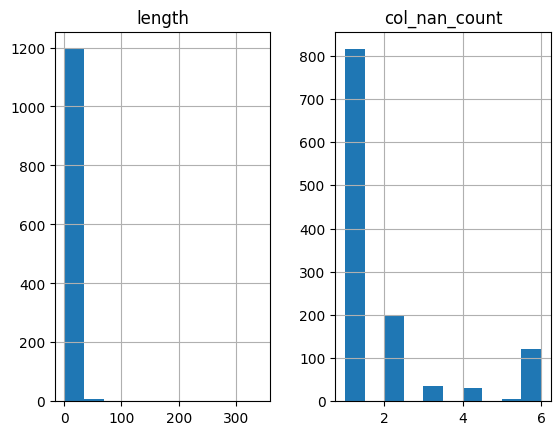

In [31]:
series.hist(column= ['length', 'col_nan_count'])

In [32]:
series[series['start_season'] != series['end_season']]

,start,end,length,col_nan_count,start_season,end_season
782,24111,24120,10,1,Autumn,Winter


In [33]:
df_list['aotizhongxin'].iloc[15754:16096, :]

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
15754,15755,2014,12,17,10,NaN,NaN,NaN,NaN,NaN,NaN,-0.8,1021.0,-16.7,0.0,W,1.0,Aotizhongxin,Winter
15755,15756,2014,12,17,11,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1017.0,-15.5,0.0,ENE,1.5,Aotizhongxin,Winter
15756,15757,2014,12,17,12,NaN,NaN,NaN,NaN,NaN,NaN,2.3,1019.0,-14.8,0.0,ENE,0.9,Aotizhongxin,Winter
15757,15758,2014,12,17,13,NaN,NaN,NaN,NaN,NaN,NaN,2.7,1023.7,-16.4,0.0,E,1.8,Aotizhongxin,Winter
15758,15759,2014,12,17,14,NaN,NaN,NaN,NaN,NaN,NaN,5.0,1016.0,-15.6,0.0,WSW,2.2,Aotizhongxin,Winter
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16091,16092,2014,12,31,11,NaN,NaN,NaN,NaN,NaN,NaN,-1.8,1027.0,-25.1,0.0,N,2.2,Aotizhongxin,Winter
16092,16093,2014,12,31,12,NaN,NaN,NaN,NaN,NaN,NaN,-1.3,1029.0,-24.7,0.0,NNW,4.7,Aotizhongxin,Winter
16093,16094,2014,12,31,13,NaN,NaN,NaN,NaN,NaN,NaN,-0.5,1028.0,-24.8,0.0,NW,5.9,Aotizhongxin,Winter
16094,16095,2014,12,31,14,NaN,NaN,NaN,NaN,NaN,NaN,-0.2,1029.0,-24.6,0.0,NNW,4.6,Aotizhongxin,Winter


In [34]:
series = check_multi_col_gap(df_list['aotizhongxin'], support_params)
series.sort_values(['length', 'col_nan_count'], ascending=False)

,start,end,length,col_nan_count,start_season,end_season
3,31315,31319,5,5,Autumn,Autumn
7,34083,34087,5,5,Winter,Winter
9,34285,34286,2,5,Winter,Winter
0,16748,16748,1,5,Winter,Winter
1,17263,17263,1,5,Winter,Winter
2,31047,31047,1,4,Autumn,Autumn
4,31320,31320,1,4,Autumn,Autumn
5,33872,33872,1,4,Winter,Winter
6,33882,33882,1,4,Winter,Winter
8,34088,34088,1,4,Winter,Winter


array([[<Axes: title={'center': 'length'}>,
        <Axes: title={'center': 'col_nan_count'}>]], dtype=object)

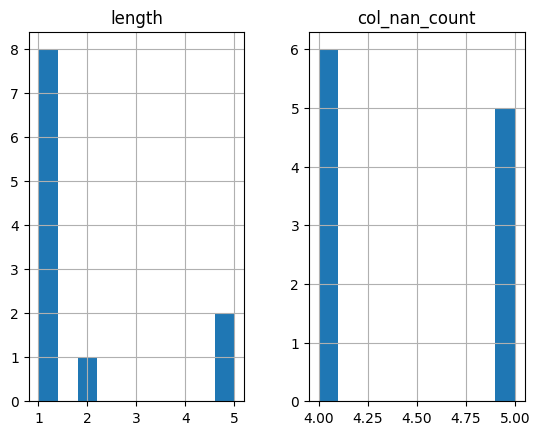

In [35]:
series.hist(column= ['length', 'col_nan_count'])

#### Check inaccurate data

Data berdasarkan AQI China

| Polutan | Baik   | Sedang    | Tidak sehat    | Berbahaya |
|---------|------  |--------   |-------------   |-----------|
| PM2.5   | 0-35   | 35-75     | 75-150         | >150      |
| PM10    | 0-50   | 50-150    | 150-250        | >250      |
| SO2     | 0-50   | 50-150    | 150-475        | >475      |
| NO2     | 0-40   | 40-80     | 80-180         | >180      |
| CO      | 0-2000 | 2000-4000 | 4000-14000     | >14000    |
| O3      | 0-100  | 100-160   | 160-215        | >215      |

##### Time

In [36]:
def check_time_min_max(df_list):
    min_year = 2013
    max_year = 2017
    min_month = 1
    max_month = 12
    min_day = 1
    max_day = 31
    min_hour = 0
    max_hour = 23

    for key, value in df_list.items():
        is_min_year_correct = value['year'].min()
        is_max_year_correct = value['year'].max()
        is_min_month_correct = value['month'].min()
        is_max_month_correct = value['month'].max()
        is_min_day_correct = value['day'].min()
        is_max_day_correct = value['day'].max()
        is_min_hour_correct = value['hour'].min()
        is_max_hour_correct = value['hour'].max()

        if (
            is_min_year_correct == min_year and
            is_max_year_correct == max_year and
            is_min_month_correct == min_month and
            is_max_month_correct == max_month and
            is_min_day_correct == min_day and
            is_max_day_correct == max_day and
            is_min_hour_correct == min_hour and
            is_max_hour_correct == max_hour
        ):
            print(f"Data is correct ({key})")
        else:
            print(f"Data is not correct ({key})")


check_time_min_max(df_list)

Data is correct (changping)
Data is correct (gucheng)
Data is correct (guanyuan)
Data is correct (wanliu)
Data is correct (dongsi)
Data is correct (dingling)
Data is correct (huairou)
Data is correct (wanshouxigong)
Data is correct (aotizhongxin)
Data is correct (nongzhanguan)
Data is correct (tiantan)
Data is correct (shunyi)


##### Primary params

In [37]:
for key, value in df_list.items():
    print(key)

    print(value.sort_values(by='PM2.5', ascending=False).head(5).loc[:, 'PM2.5'])

changping
25778    882.0
33660    662.0
33397    596.0
8698     581.0
33396    576.0
Name: PM2.5, dtype: float64
gucheng
8422     770.0
34298    767.0
24133    741.0
34297    739.0
24132    733.0
Name: PM2.5, dtype: float64
guanyuan
24134    680.0
24135    666.0
34298    664.0
34303    663.0
24133    645.0
Name: PM2.5, dtype: float64
wanliu
25778    957.0
25780    791.0
25781    770.0
24134    718.0
24135    708.0
Name: PM2.5, dtype: float64
dongsi
8423     737.0
25779    695.0
24116    685.0
24117    685.0
8422     684.0
Name: PM2.5, dtype: float64
dingling
25777    881.0
24716    647.0
24714    632.0
24715    617.0
24713    614.0
Name: PM2.5, dtype: float64
huairou
17282    762.0
25777    683.0
17281    659.0
24137    559.0
33666    558.0
Name: PM2.5, dtype: float64
wanshouxigong
25778    999.0
25779    857.0
25777    826.0
34299    823.0
34297    804.0
Name: PM2.5, dtype: float64
aotizhongxin
25778    898.0
25779    713.0
34301    713.0
34302    697.0
34300    682.0
Name: PM2.5, dty

In [38]:
df_list['wanshouxigong'].sort_values(by='PM2.5', ascending=False).head(50).loc[:, primary_params+secondary_params]

,PM2.5,PM10,SO2,NO2,CO,O3
25778,999.0,NaN,299.0,82.0,2700.0,6.0
25779,857.0,NaN,256.0,82.0,2400.0,6.0
25777,826.0,NaN,411.0,81.0,2400.0,7.0
34299,823.0,915.0,170.0,82.0,3200.0,6.0
34297,804.0,952.0,189.0,79.0,200.0,9.0
25780,748.0,929.0,236.0,83.0,2900.0,9.0
34298,730.0,950.0,163.0,80.0,2200.0,8.0
8423,704.0,836.0,158.0,148.0,4200.0,1.0
24132,690.0,690.0,41.0,159.0,NaN,13.0
24112,687.0,704.0,44.0,199.0,8700.0,11.0


In [39]:
for key, value in df_list.items():
    print(key)

    print(value.sort_values(by='PM10', ascending=False).head(5).loc[:, 'PM10'])

changping
7887     999.0
17355    992.0
17354    980.0
18179    976.0
27888    933.0
Name: PM10, dtype: float64
gucheng
34298    994.0
27888    986.0
203      983.0
206      957.0
202      947.0
Name: PM10, dtype: float64
guanyuan
5819     999.0
204      987.0
18620    961.0
34298    917.0
27887    906.0
Name: PM10, dtype: float64
wanliu
18620    951.0
7796     923.0
25780    919.0
25781    893.0
18179    845.0
Name: PM10, dtype: float64
dongsi
34297    955.0
34300    915.0
34298    907.0
26973    891.0
26401    888.0
Name: PM10, dtype: float64
dingling
17355    905.0
17352    904.0
9153     895.0
25778    864.0
17351    842.0
Name: PM10, dtype: float64
huairou
15359    993.0
17281    991.0
17356    973.0
25777    973.0
15360    948.0
Name: PM10, dtype: float64
wanshouxigong
205      961.0
34297    952.0
34298    950.0
18182    931.0
25780    929.0
Name: PM10, dtype: float64
aotizhongxin
18618    984.0
10292    948.0
18620    944.0
25779    884.0
18182    874.0
Name: PM10, dtype: float

##### Secondary params

In [40]:
for key, value in df_list.items():
    print(key)

    print(value.sort_values(by='O3', ascending=False).head(5).loc[:, 'O3'])

changping
3640     429.0
12303    413.0
3641     387.0
10936    366.0
11679    365.0
Name: O3, dtype: float64
gucheng
18159    450.0
10936    374.0
20728    359.0
10937    357.0
10935    355.0
Name: O3, dtype: float64
guanyuan
33857    415.0
3902     356.0
21494    352.0
10935    352.0
10936    346.0
Name: O3, dtype: float64
wanliu
19577    364.0
20726    357.0
19576    357.0
20727    353.0
20728    352.0
Name: O3, dtype: float64
dongsi
4056    1071.0
4054    1071.0
4053    1071.0
4049    1071.0
4031    1071.0
Name: O3, dtype: float64
dingling
33542    500.0
28311    500.0
29258    500.0
29256    500.0
29270    500.0
Name: O3, dtype: float64
huairou
6429     444.0
21497    413.0
12303    391.0
21496    386.0
12304    385.0
Name: O3, dtype: float64
wanshouxigong
3902     358.0
21567    355.0
10935    347.0
28480    340.0
10936    338.0
Name: O3, dtype: float64
aotizhongxin
20727    423.0
20726    406.0
20728    397.0
20725    380.0
20752    365.0
Name: O3, dtype: float64
nongzhanguan
30

In [41]:
df_list['dongsi'].sort_values(by='O3', ascending=False).head(50).loc[:, primary_params+secondary_params]

,PM2.5,PM10,SO2,NO2,CO,O3
4056,197.0,198.0,9.0000,101.0000,2300.0,1071.0000
4054,198.0,233.0,7.0000,102.0000,2300.0,1071.0000
4053,202.0,242.0,7.0000,95.0000,3100.0,1071.0000
4049,206.0,267.0,7.0000,65.0000,2000.0,1071.0000
4031,195.0,206.0,6.0000,40.0000,1600.0,1071.0000
4032,203.0,206.0,6.0000,34.0000,1500.0,1071.0000
4055,201.0,219.0,8.0000,118.0000,2700.0,1071.0000
4052,202.0,232.0,7.0000,98.0000,3300.0,1071.0000
4051,187.0,222.0,8.0000,86.0000,2100.0,1071.0000
4058,161.0,188.0,7.0000,97.0000,1900.0,1071.0000


In [42]:
for key, value in df_list.items():
    print(key)

    print(value.sort_values(by='CO', ascending=False).head(5).loc[:, 'CO'])

changping
7428     10000.0
33394    10000.0
33673     9900.0
24730     9900.0
24141     9900.0
Name: CO, dtype: float64
gucheng
33744    10000.0
33388    10000.0
33739    10000.0
33673     9900.0
24649     9900.0
Name: CO, dtype: float64
guanyuan
19821    10000.0
19819    10000.0
19868    10000.0
19869    10000.0
19834    10000.0
Name: CO, dtype: float64
wanliu
24916    10000.0
33740    10000.0
19835    10000.0
19821    10000.0
177      10000.0
Name: CO, dtype: float64
dongsi
19869    10000.0
19868    10000.0
24131    10000.0
19830    10000.0
19815    10000.0
Name: CO, dtype: float64
dingling
33746    10000.0
33745     9600.0
24716     9400.0
33386     9400.0
24717     9100.0
Name: CO, dtype: float64
huairou
19822    10000.0
24137    10000.0
19823    10000.0
24136     9800.0
33742     9800.0
Name: CO, dtype: float64
wanshouxigong
33381    9800.0
24657    9800.0
24123    9700.0
33410    9700.0
24124    9600.0
Name: CO, dtype: float64
aotizhongxin
24817    10000.0
24126    10000.0
24705 

In [43]:
for key, value in df_list.items():
    print(key)

    print(value.sort_values(by='NO2', ascending=False).head(5).loc[:, 'NO2'])

changping
33397    226.0
26115    208.0
33398    205.0
33660    203.0
33402    202.0
Name: NO2, dtype: float64
gucheng
33734    276.0
33738    271.0
33739    270.0
33740    261.0
33735    258.0
Name: NO2, dtype: float64
guanyuan
156      270.0
23037    239.0
155      233.0
18396    231.0
14327    230.0
Name: NO2, dtype: float64
wanliu
8658    264.0
8657    263.0
8701    259.0
8656    257.0
8686    253.0
Name: NO2, dtype: float64
dongsi
166      258.0
165      257.0
23037    256.0
156      254.0
167      249.0
Name: NO2, dtype: float64
dingling
33398    205.0000
5921     190.3131
33661    190.0000
33399    188.0000
5922     187.0283
Name: NO2, dtype: float64
huairou
5921    231.0
9355    219.0
164     205.0
162     199.0
163     198.0
Name: NO2, dtype: float64
wanshouxigong
33732    251.0
155      241.0
33400    235.0
33399    229.0
33401    228.0
Name: NO2, dtype: float64
aotizhongxin
23036    290.0
14325    285.0
14326    280.0
23037    277.0
14324    277.0
Name: NO2, dtype: float64
n

In [44]:
for key, value in df_list.items():
    print(key)

    print(value.sort_values(by='SO2', ascending=False).head(5).loc[:, 'SO2'])

changping
17645    310.0
25777    257.0
7665     235.0
25778    215.0
7710     195.0
Name: SO2, dtype: float64
gucheng
25204    500.0
10552    500.0
25777    500.0
18241    248.0
34297    247.0
Name: SO2, dtype: float64
guanyuan
34465    293.0
25777    277.0
34321    274.0
7707     263.0
34417    247.0
Name: SO2, dtype: float64
wanliu
25778    282.0
8674     225.0
7704     221.0
7716     216.0
7703     215.0
Name: SO2, dtype: float64
dongsi
33789    300.0
25777    278.0
8422     230.0
25779    201.0
8423     200.0
Name: SO2, dtype: float64
dingling
25777    156.0
15896    150.0
7889     145.0
8630     141.0
8631     137.0
Name: SO2, dtype: float64
huairou
8651     315.0
17281    314.0
8703     268.0
7736     254.0
7886     253.0
Name: SO2, dtype: float64
wanshouxigong
25777    411.0
25778    299.0
16381    273.0
16382    272.0
25779    256.0
Name: SO2, dtype: float64
aotizhongxin
25778    341.0
25779    229.0
7896     197.0
7699     196.0
25777    192.0
Name: SO2, dtype: float64
nongzh

In [45]:
df_list['gucheng'].sort_values(by='SO2', ascending=False).head(50).loc[:, primary_params+secondary_params]

,PM2.5,PM10,SO2,NO2,CO,O3
25204,38.0,75.0,500.0,31.0,1200.0,5.0
10552,NaN,35.0,500.0,21.0,300.0,74.0
25777,NaN,NaN,500.0,65.0,2200.0,23.0
18241,176.0,276.0,248.0,52.0,1300.0,77.0
34297,739.0,NaN,247.0,84.0,2200.0,6.0
17281,540.0,707.0,246.0,53.0,1400.0,16.0
19825,64.0,64.0,227.0,63.0,7000.0,10.0
19873,20.0,50.0,220.0,52.0,6000.0,23.0
19921,30.0,73.0,220.0,58.0,600.0,50.0
30241,128.0,128.0,218.0,62.0,1100.0,30.0


In [46]:
for key, value in df_list.items():
    print(key)

    print(value.sort_values(by='WSPM', ascending=False).head(5).loc[:, 'WSPM'])

changping
15358    10.0
15350     9.6
34331     9.6
17343     9.6
25426     9.4
Name: WSPM, dtype: float64
gucheng
34327    12.0
34264    11.4
34095    11.0
34140    10.9
34099    10.7
Name: WSPM, dtype: float64
guanyuan
17345    11.2
22667     9.2
10284     9.1
30883     8.9
24180     8.8
Name: WSPM, dtype: float64
wanliu
17345    11.2
10284     9.1
34093     8.6
15708     8.4
34094     8.3
Name: WSPM, dtype: float64
dongsi
7195     10.5
15357    10.3
7194     10.2
10290     9.9
15589     9.9
Name: WSPM, dtype: float64
dingling
15358    10.0
15350     9.6
34331     9.6
17343     9.6
25426     9.4
Name: WSPM, dtype: float64
huairou
204      12.9
974      11.8
15357    11.7
1909     11.0
1043     10.9
Name: WSPM, dtype: float64
wanshouxigong
202      13.2
11322    10.1
6827     10.0
201       9.9
9068      9.5
Name: WSPM, dtype: float64
aotizhongxin
17345    11.2
22667     9.2
10284     9.1
30883     8.9
24180     8.8
Name: WSPM, dtype: float64
nongzhanguan
7195     10.5
15357    10.3
7

#### Check outlier

In [47]:
def check_outlier(df, params):
    for param in params:
        param_df = df[param]
        q25, q75 = param_df.quantile([0.25, 0.75])
        iqr = q75 - q25
        cut_off = iqr * 1.5
        minimum, maximum = q25 - cut_off, q75 + cut_off

        outlier_sum = ((param_df < minimum) | (param_df > maximum)).sum()
        outlier_percentage = outlier_sum / len(param_df) * 100

        print(f"{param}: {outlier_sum} ({outlier_percentage:.2f})")

In [48]:
def plot_outlier_boxplots(df: pd.DataFrame, parameters: list, ncols: int = 3,
                           figsize_per_plot: tuple = (5, 4),):
    """
    Menampilkan boxplot untuk setiap parameter pengukuran dalam
    grid subplot, untuk melihat sebaran dan outlier tiap parameter.

    Parameters:
        df               : dataframe yang berisi data pengukuran
        parameters       : list nama kolom (parameter) yang ingin di-boxplot
        ncols            : jumlah kolom grid subplot (default 3)
        figsize_per_plot : ukuran (lebar, tinggi) untuk masing-masing subplot
        save_path        : path untuk menyimpan hasil gambar

    Return: None (menampilkan & menyimpan plot)
    """
    n_params = len(parameters)
    nrows = int(np.ceil(n_params / ncols))

    fig_width = figsize_per_plot[0] * ncols
    fig_height = figsize_per_plot[1] * nrows

    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height))

    # Pastikan axes berbentuk 2D (nrows x ncols) supaya urutan pengisian
    # bisa dikontrol eksplisit: kiri -> kanan, baru lanjut baris berikutnya
    axes = np.array(axes).reshape(nrows, ncols)

    # Flatten dengan order='C' -> mengisi per BARIS dari kiri ke kanan
    # dulu, baru pindah ke baris berikutnya (bukan per kolom/atas-bawah)
    axes = axes.flatten(order="C")

    for i, col in enumerate(parameters):
        if col not in df.columns:
            print(f"Peringatan: kolom '{col}' tidak ditemukan di dataframe, dilewati.")
            axes[i].axis("off")
            continue

        sns.boxplot(y=df[col].dropna(), ax=axes[i], color="skyblue")
        axes[i].set_title(col)
        axes[i].set_ylabel("Nilai")

        # Hitung & tampilkan jumlah outlier (metode IQR) di judul subplot
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        n_outlier = ((df[col] < lower) | (df[col] > upper)).sum()

        axes[i].set_title(f"{col}\n(outlier: {n_outlier})")

    # Matikan subplot kosong sisa (kalau jumlah parameter tidak pas grid)
    for j in range(n_params, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


In [49]:
for key, value in df_list.items():
    print(key)
    check_outlier(value, pollutant_params)
    print()

changping
PM2.5: 1674 (4.77)
PM10: 1313 (3.74)
SO2: 3136 (8.94)
NO2: 799 (2.28)
CO: 2590 (7.39)
O3: 1612 (4.60)

gucheng
PM2.5: 1584 (4.52)
PM10: 884 (2.52)
SO2: 2639 (7.53)
NO2: 392 (1.12)
CO: 2670 (7.61)
O3: 1372 (3.91)

guanyuan
PM2.5: 1504 (4.29)
PM10: 1186 (3.38)
SO2: 3020 (8.61)
NO2: 664 (1.89)
CO: 2167 (6.18)
O3: 1343 (3.83)

wanliu
PM2.5: 1566 (4.47)
PM10: 1221 (3.48)
SO2: 2870 (8.19)
NO2: 490 (1.40)
CO: 2687 (7.66)
O3: 1386 (3.95)

dongsi
PM2.5: 1622 (4.63)
PM10: 1335 (3.81)
SO2: 2606 (7.43)
NO2: 600 (1.71)
CO: 1976 (5.64)
O3: 1318 (3.76)

dingling
PM2.5: 1831 (5.22)
PM10: 1430 (4.08)
SO2: 2787 (7.95)
NO2: 1805 (5.15)
CO: 1848 (5.27)
O3: 1616 (4.61)

huairou
PM2.5: 1626 (4.64)
PM10: 1067 (3.04)
SO2: 3359 (9.58)
NO2: 917 (2.62)
CO: 1647 (4.70)
O3: 1494 (4.26)

wanshouxigong
PM2.5: 1727 (4.93)
PM10: 1311 (3.74)
SO2: 3191 (9.10)
NO2: 582 (1.66)
CO: 2332 (6.65)
O3: 1286 (3.67)

aotizhongxin
PM2.5: 1624 (4.63)
PM10: 1080 (3.08)
SO2: 3054 (8.71)
NO2: 472 (1.35)
CO: 2607 (7.43)
O3: 1

In [50]:
for key, value in df_list.items():
    print(key)
    check_outlier(value, support_params)
    print()

changping
TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
RAIN: 1350 (3.85)
WSPM: 2382 (6.79)

gucheng
TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
RAIN: 1348 (3.84)
WSPM: 1639 (4.67)

guanyuan
TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
RAIN: 1380 (3.94)
WSPM: 1742 (4.97)

wanliu
TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
RAIN: 1436 (4.10)
WSPM: 1555 (4.43)

dongsi
TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
RAIN: 1371 (3.91)
WSPM: 1609 (4.59)

dingling
TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
RAIN: 1350 (3.85)
WSPM: 2382 (6.79)

huairou
TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
RAIN: 1491 (4.25)
WSPM: 2375 (6.77)

wanshouxigong
TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
RAIN: 1361 (3.88)
WSPM: 1517 (4.33)

aotizhongxin
TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
RAIN: 1380 (3.94)
WSPM: 1742 (4.97)

nongzhanguan
TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
RAIN: 1371 (3.91)
WSPM: 1609 (4.59)

tiantan
TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
RAIN: 1371 (3.91)
WSPM: 1609 

#### Steps

- Melihat apakah semua tabel memiliki header yang sama
- Menilai data yang disajikan dari
    - Info (jumlah baris, data type)
    - Duplicated data
    - Null data
    - Check null value
    - Inaccurate data (year, month, day, hour)
    - Check outlier

#### Insight

Info
1. Semua tabel memiliki header yang sama
1. Jumlah baris tiap station = 35064
1. Jumlah station ada 12 station
1. Data direkam dari tahun 2013-2017
1. Saya membagi data menjadi 3 bagian:
    - Primary: PM2.5, PM10
    - Secondary: CO, NO2, SO2, O3
    - Support: temp, pres, dewp, wspm, rain, wd

Duplicate data
1. Duplicate data tidak ada sama sekali

Tipe data
1. Tipe data untuk wind direction (WD) dan station seharusnya string

Null data
1. Semua station (dataframe) memiliki beberapa parameter kualitas udara yang null
1. Diambil salah satu station untuk dilakukan pengecekan null value, yaitu di aotizhongxin. Terdapat 343 jam (selama 14 hari) berturut-turut, data polutan tidak terekam.
1. Baris polutan yang memiliki NaN memiliki variasi jumlah kolom yang NaN. Paling tinggi terdapat 6 kolom polutan yang NaN.
1. Demikian juga untuk data secondary, terdapat null value.

Inaccurate data
1. Inaccurate data bagian waktu (year, month, day, hour) tidak ada
1. Inaccurate data terdeteksi di bagian O3 dan SO2 karena kenaikannya sangat tinggi
    1. O3 dari 500 sampai 1071
    1. SO2 dari 248 sampai 500

### Cleaning Data

#### Drop number column

In [51]:
def drop_number_column(df_list):
    for key, value in df_list.items():
        value.drop(columns=['No'], inplace=True)


clean_df_list = df_list.copy()
drop_number_column(clean_df_list)
clean_df_list['changping'].describe()

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,34290.000000,34482.000000,34436.000000,34397.000000,33543.000000,34460.000000,35011.000000,35014.000000,35011.000000,35013.000000,35021.000000
mean,2014.662560,6.522930,15.729637,11.500000,71.099743,94.657871,14.958906,44.182086,1152.301345,57.940003,13.686111,1007.760278,1.505495,0.060366,1.853836
std,1.177213,3.448752,8.800218,6.922285,72.326926,83.441738,20.975331,29.519796,1103.056282,54.316674,11.365313,10.225664,13.822099,0.752899,1.309808
min,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.847700,100.000000,0.214200,-16.600000,982.400000,-35.100000,0.000000,0.000000
25%,2014.000000,4.000000,8.000000,5.750000,18.000000,34.000000,2.000000,22.000000,500.000000,15.636600,3.400000,999.300000,-10.200000,0.000000,1.000000
50%,2015.000000,7.000000,16.000000,11.500000,46.000000,72.000000,7.000000,36.000000,800.000000,46.000000,14.700000,1007.400000,1.800000,0.000000,1.500000
75%,2016.000000,10.000000,23.000000,17.250000,100.000000,131.000000,18.000000,60.358200,1400.000000,80.000000,23.300000,1016.000000,14.200000,0.000000,2.300000
max,2017.000000,12.000000,31.000000,23.000000,882.000000,999.000000,310.000000,226.000000,10000.000000,429.000000,41.400000,1036.500000,27.200000,52.100000,10.000000


#### Change station and WD data type to string

In [52]:
string_columns = ['wd', 'station']

for key, value in clean_df_list.items():
    for column in string_columns:
        value[column] = value[column].astype('string')

clean_df_list['huairou'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     35064 non-null  int64  
 1   month    35064 non-null  int64  
 2   day      35064 non-null  int64  
 3   hour     35064 non-null  int64  
 4   PM2.5    34111 non-null  float64
 5   PM10     34287 non-null  float64
 6   SO2      34084 non-null  float64
 7   NO2      33425 non-null  float64
 8   CO       33642 non-null  float64
 9   O3       33913 non-null  float64
 10  TEMP     35013 non-null  float64
 11  PRES     35011 non-null  float64
 12  DEWP     35011 non-null  float64
 13  RAIN     35009 non-null  float64
 14  wd       34762 non-null  string 
 15  WSPM     35015 non-null  float64
 16  station  35064 non-null  string 
 17  season   35064 non-null  object 
dtypes: float64(11), int64(4), object(1), string(2)
memory usage: 4.8+ MB


#### Combine all time columns into one datetime column

In [53]:
def combine_time_columns(df_map):
    for key, value in df_map.items():
        value['date'] = pd.to_datetime(
            value[['year', 'month', 'day', 'hour']].astype(str).agg('-'.join, axis=1),
            format='%Y-%m-%d-%H'
        )

        value.drop(columns=['year', 'month', 'day', 'hour'], inplace=True)


combine_time_columns(clean_df_list)

In [54]:
def reorder_date_column(df_list):
    for key, value in df_list.items():
        value.insert(0, 'date', value.pop('date'))


reorder_date_column(clean_df_list)

In [55]:
clean_df_list['guanyuan'].head()

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
0,2013-03-01 00:00:00,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan,Spring
1,2013-03-01 01:00:00,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan,Spring
2,2013-03-01 02:00:00,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan,Spring
3,2013-03-01 03:00:00,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan,Spring
4,2013-03-01 04:00:00,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan,Spring


#### Inaccurate data

Make all data be NaN

In [56]:
for key, value in clean_df_list.items():
    print(key)

    print(value.sort_values(by='O3', ascending=False).head(5).loc[:, 'O3'])

changping
3640     429.0
12303    413.0
3641     387.0
10936    366.0
11679    365.0
Name: O3, dtype: float64
gucheng
18159    450.0
10936    374.0
20728    359.0
10937    357.0
10935    355.0
Name: O3, dtype: float64
guanyuan
33857    415.0
3902     356.0
21494    352.0
10935    352.0
10936    346.0
Name: O3, dtype: float64
wanliu
19577    364.0
20726    357.0
19576    357.0
20727    353.0
20728    352.0
Name: O3, dtype: float64
dongsi
4056    1071.0
4054    1071.0
4053    1071.0
4049    1071.0
4031    1071.0
Name: O3, dtype: float64
dingling
33542    500.0
28311    500.0
29258    500.0
29256    500.0
29270    500.0
Name: O3, dtype: float64
huairou
6429     444.0
21497    413.0
12303    391.0
21496    386.0
12304    385.0
Name: O3, dtype: float64
wanshouxigong
3902     358.0
21567    355.0
10935    347.0
28480    340.0
10936    338.0
Name: O3, dtype: float64
aotizhongxin
20727    423.0
20726    406.0
20728    397.0
20725    380.0
20752    365.0
Name: O3, dtype: float64
nongzhanguan
30

In [57]:
clean_df_list['dongsi'].sort_values(by='O3', ascending=False).head(50).loc[:, primary_params+secondary_params]

,PM2.5,PM10,SO2,NO2,CO,O3
4056,197.0,198.0,9.0000,101.0000,2300.0,1071.0000
4054,198.0,233.0,7.0000,102.0000,2300.0,1071.0000
4053,202.0,242.0,7.0000,95.0000,3100.0,1071.0000
4049,206.0,267.0,7.0000,65.0000,2000.0,1071.0000
4031,195.0,206.0,6.0000,40.0000,1600.0,1071.0000
4032,203.0,206.0,6.0000,34.0000,1500.0,1071.0000
4055,201.0,219.0,8.0000,118.0000,2700.0,1071.0000
4052,202.0,232.0,7.0000,98.0000,3300.0,1071.0000
4051,187.0,222.0,8.0000,86.0000,2100.0,1071.0000
4058,161.0,188.0,7.0000,97.0000,1900.0,1071.0000


In [58]:
clean_df_list['dongsi'].loc[clean_df_list['dongsi']['O3'] > 500, 'O3'] = np.nan

clean_df_list['dongsi'][clean_df_list['dongsi']['O3'] > 500]

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [59]:
clean_df_list['dongsi'].sort_values(by='O3', ascending=False).head().loc[:, primary_params+secondary_params]

,PM2.5,PM10,SO2,NO2,CO,O3
33783,245.0,256.0,27.000,128.0000,500.0,500.0
4033,73.0,73.0,3.000,28.0000,900.0,413.0
33784,247.0,256.0,24.000,133.0000,900.0,346.0
30471,88.0,89.0,2.000,36.0000,1000.0,342.0
3902,150.0,203.0,17.136,37.1593,NaN,338.0


In [60]:
clean_df_list['dongsi'].loc[4050:4060]

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
4050,2013-08-16 18:00:00,207.0,273.0,8.0,85.0,2200.0,NaN,30.0,993.3,28.4,0.0,ENE,1.5,Dongsi,Summer
4051,2013-08-16 19:00:00,187.0,222.0,8.0,86.0,2100.0,NaN,29.5,993.6,28.4,0.0,ESE,1.2,Dongsi,Summer
4052,2013-08-16 20:00:00,202.0,232.0,7.0,98.0,3300.0,NaN,28.9,994.5,28.2,0.0,SSE,0.6,Dongsi,Summer
4053,2013-08-16 21:00:00,202.0,242.0,7.0,95.0,3100.0,NaN,28.8,994.1,28.3,0.5,SE,1.1,Dongsi,Summer
4054,2013-08-16 22:00:00,198.0,233.0,7.0,102.0,2300.0,NaN,28.4,994.1,28.1,0.0,E,0.8,Dongsi,Summer
4055,2013-08-16 23:00:00,201.0,219.0,8.0,118.0,2700.0,NaN,28.3,994.0,28.0,0.1,E,1.0,Dongsi,Summer
4056,2013-08-17 00:00:00,197.0,198.0,9.0,101.0,2300.0,NaN,28.2,993.7,27.9,0.0,NE,1.6,Dongsi,Summer
4057,2013-08-17 01:00:00,168.0,169.0,7.0,75.0,2000.0,NaN,27.8,994.1,27.5,0.0,NNE,0.0,Dongsi,Summer
4058,2013-08-17 02:00:00,161.0,188.0,7.0,97.0,1900.0,NaN,27.3,994.2,27.1,0.0,N,0.0,Dongsi,Summer
4059,2013-08-17 03:00:00,164.0,188.0,7.0,70.0,1600.0,NaN,29.1,994.3,21.6,0.0,NW,1.7,Dongsi,Summer


In [61]:
for key, value in clean_df_list.items():
    print(key)

    print(value.sort_values(by='SO2', ascending=False).head(5).loc[:, 'SO2'])

changping
17645    310.0
25777    257.0
7665     235.0
25778    215.0
7710     195.0
Name: SO2, dtype: float64
gucheng
25204    500.0
10552    500.0
25777    500.0
18241    248.0
34297    247.0
Name: SO2, dtype: float64
guanyuan
34465    293.0
25777    277.0
34321    274.0
7707     263.0
34417    247.0
Name: SO2, dtype: float64
wanliu
25778    282.0
8674     225.0
7704     221.0
7716     216.0
7703     215.0
Name: SO2, dtype: float64
dongsi
33789    300.0
25777    278.0
8422     230.0
25779    201.0
8423     200.0
Name: SO2, dtype: float64
dingling
25777    156.0
15896    150.0
7889     145.0
8630     141.0
8631     137.0
Name: SO2, dtype: float64
huairou
8651     315.0
17281    314.0
8703     268.0
7736     254.0
7886     253.0
Name: SO2, dtype: float64
wanshouxigong
25777    411.0
25778    299.0
16381    273.0
16382    272.0
25779    256.0
Name: SO2, dtype: float64
aotizhongxin
25778    341.0
25779    229.0
7896     197.0
7699     196.0
25777    192.0
Name: SO2, dtype: float64
nongzh

In [62]:
clean_df_list['gucheng'].sort_values(by='SO2', ascending=False).head(50).loc[:, primary_params+secondary_params]

,PM2.5,PM10,SO2,NO2,CO,O3
25204,38.0,75.0,500.0,31.0,1200.0,5.0
10552,NaN,35.0,500.0,21.0,300.0,74.0
25777,NaN,NaN,500.0,65.0,2200.0,23.0
18241,176.0,276.0,248.0,52.0,1300.0,77.0
34297,739.0,NaN,247.0,84.0,2200.0,6.0
17281,540.0,707.0,246.0,53.0,1400.0,16.0
19825,64.0,64.0,227.0,63.0,7000.0,10.0
19873,20.0,50.0,220.0,52.0,6000.0,23.0
19921,30.0,73.0,220.0,58.0,600.0,50.0
30241,128.0,128.0,218.0,62.0,1100.0,30.0


In [63]:
clean_df_list['gucheng'].loc[clean_df_list['gucheng']['SO2'] == 500, 'SO2'] = np.nan

clean_df_list['gucheng'][clean_df_list['gucheng']['SO2'] == 500]

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [64]:
clean_df_list['gucheng'].sort_values(by='SO2', ascending=False).head()

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
18241,2015-03-31 01:00:00,176.0,276.0,248.0,52.0,1300.0,77.0,17.70,1001.1,8.8,0.0,E,0.8,Gucheng,Spring
34297,2017-01-28 01:00:00,739.0,NaN,247.0,84.0,2200.0,6.0,-4.12,1014.0,-13.2,0.0,NW,1.8,Gucheng,Winter
17281,2015-02-19 01:00:00,540.0,707.0,246.0,53.0,1400.0,16.0,3.00,1025.0,-10.3,0.0,WSW,1.2,Gucheng,Winter
19825,2015-06-05 01:00:00,64.0,64.0,227.0,63.0,7000.0,10.0,18.40,991.7,14.1,0.0,NW,0.6,Gucheng,Summer
19873,2015-06-07 01:00:00,20.0,50.0,220.0,52.0,6000.0,23.0,23.00,998.7,5.9,0.0,W,0.9,Gucheng,Summer


#### Missing values

Pemrosesan missing value dibagi jadi 2 bagian:
1. Primary dan secondary params
2. Support params

##### Primary dan secondary params

Cara menangani missing value (limitasi)

| Jumlah Kolom NaN	| ≤5 jam | 6-12 jam | 12-48 jam | >48 jam |
|-------------------|--------|----------|-----------|---------|
| 1 kolom           | Linear | Regresi  | Regresi   | Regresi |
| 2 kolom           | Linear | Custom   | Custom    | Custom  |
| 3-6 kolom         | Linear | Custom   | Custom    | NaN/drop|

Saya membagi kolom NaN menjadi 3 kategori:
1. 1 kolom (sedikit)
1. 2 kolom (sedang)
1. 3-6 kolom (sedang)

Saya membagi durasi gap waktu menjadi 4 kategori dengan alasan:
1. kategori cepat: ≤5 jam, masih bisa dianggap ringan atau mati biasa
1. kategori lama: 6-12 jam, sudah dianggap ada kendala teknis
1. kategori sangat lama: 12-48 jam, ada kendala sensor atau station
1. kategori anomali: >48 jam

Saya membagi metode mengatasi missing value menjadi 4 cara:
1. Linear: interpolasi linear biasa. Cocok untuk durasi pendek.
1. Regresi: pengisian variabel yang hilang dengan mempertimbangkan variabel lain. Cocok untuk kolom NaN sedikit.
1. Custom: pengisian variabel yang hilang dengan mengambil median/mean (bergantung pada skewness data) 3 hari sebelum dan/atau sesudah di jam yang sama.
    1. Fallback: jika data sebelum dan sesudah null, maka akan diambil data median/mean berdasarkan musiman (station + season + bulan + jam)
1. NaN/Drop: dibiarkan NaN atau di-drop di akhir jika memang persentasenya sedikit (< 1-2% seluruh data station)

###### Fungsi linear

In [65]:
def create_nan_df(df, param):
    nan_df = check_multi_col_gap(df, param)
    if nan_df.empty: return nan_df
    return nan_df.sort_values(['length', 'col_nan_count'], ascending=False)

In [66]:
def interpolate_linear(df, cols, limit):
    df_copy = df.copy()

    for col in cols:
        # 1. Identify contiguous blocks of NaNs
        is_nan = df_copy[col].isna()
        # Group consecutive NaNs by cumulative sum of non-NaN values
        nan_groups = is_nan.groupby((~is_nan).cumsum())
        # Measure the exact size of each NaN gap
        gap_sizes = nan_groups.transform('sum')

        interpolated = df_copy[col].interpolate(
            method="linear",
            limit_direction="both"
        )

        # 3. Only apply interpolation where the total gap size is <= limit
        df_copy[col] = df_copy[col].where(gap_sizes > limit, interpolated)

    return df_copy

###### Fungsi seasonal

In [67]:
def interpolate_seasonal(df, nan_df, cols):
    df_copy = df.copy()

    if nan_df.empty:
        return df_copy

    for col in cols:
        for _, value in nan_df.iterrows():
            start_idx = value['start']
            end_idx = value['end']
            idx_range = list(range(start_idx, end_idx + 1))

            for idx in idx_range:
                if pd.notna(df.loc[idx, col]): continue

                season = df.at[idx, 'season']
                month = df.at[idx, 'date'].month
                hour = df.at[idx, 'date'].hour

                rows = (
                    (df_copy['season'] == season) &
                    (df_copy['date'].dt.month == month) &
                    (df_copy['date'].dt.hour == hour) &
                    (df_copy[col].notna())
                )
                ref = df.loc[rows, col]

                if len(ref) == 0:
                    rows = (
                        (df_copy['season'] == season) &
                        (df_copy['date'].dt.month == month) &
                        (df_copy[col].notna())
                    )
                    ref = df.loc[rows, col]

                if len(ref) == 0:
                    rows = (
                        (df_copy['season'] == season) &
                        (df_copy[col].notna())
                    )
                    ref = df.loc[rows, col]

                if len(ref) == 0: continue

                # Choose median or mean by data skewness
                if ref.skew() > 0:
                    df_copy.at[idx, col] = ref.median()
                else:
                    df_copy.at[idx, col] = ref.mean()

    return df_copy

###### Fungsi log breakpoint graph

In [68]:
def print_gap_buckets(data: pd.Series):
    """
    Menampilkan tabel jumlah gap per rentang durasi (bucket manual),
    sebagai pelengkap histogram untuk melihat breakpoint natural
    secara lebih presisi lewat angka.
    """
    bucket_edges = [0, 1, 2, 3, 5, 10, 20, 50, 100, 200, np.inf]
    bucket_labels = [
        "1 jam", "2 jam", "3 jam", "4-5 jam", "6-10 jam",
        "11-20 jam", "21-50 jam", "51-100 jam", "101-200 jam", ">200 jam"
    ]

    bucketed = pd.cut(data, bins=bucket_edges, labels=bucket_labels)
    counts = bucketed.value_counts().sort_index()
    percentages = (counts / counts.sum() * 100).round(2)

    summary = pd.DataFrame({
        "jumlah_gap": counts,
        "persentase (%)": percentages
    })

    print("\n=== Tabel jumlah gap per rentang durasi ===")
    print(summary.to_string())
    print("\nPerhatikan di rentang mana terjadi penurunan jumlah gap paling drastis")
    print("(persentase turun tajam) -> itu kandidat breakpoint natural.")


def plot_gap_histogram_log(gap_df: pd.DataFrame, length_col: str = "length",
                            title: str = "Distribusi Durasi Gap NaN",
                            bins: int = 30):
    """
    Plot histogram durasi gap dengan sumbu-x skala logaritmik.

    Parameters:
        gap_df     : dataframe hasil deteksi gap (punya kolom durasi gap)
        length_col : nama kolom yang berisi panjang/durasi gap
        title      : judul plot
        bins       : jumlah bin histogram (dalam skala log)
    """
    data = gap_df[length_col].dropna()
    data = data[data > 0]  # log tidak bisa untuk nilai 0

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ------------------------------------------------------------
    # Plot 1: Histogram skala LINEAR (untuk perbandingan)
    # ------------------------------------------------------------
    axes[0].hist(data, bins=30, color="skyblue", edgecolor="black")
    axes[0].set_title(f"{title}\n(Skala Linear - untuk perbandingan)")
    axes[0].set_xlabel("Durasi gap (jam)")
    axes[0].set_ylabel("Jumlah gap")

    # ------------------------------------------------------------
    # Plot 2: Histogram skala LOG (untuk melihat breakpoint natural)
    # ------------------------------------------------------------
    # Bin dibuat merata dalam skala log, bukan skala linear
    log_bins = np.logspace(np.log10(data.min()), np.log10(data.max()), bins)

    axes[1].hist(data, bins=log_bins, color="salmon", edgecolor="black")
    axes[1].set_xscale("log")
    axes[1].set_title(f"{title}\n(Skala Log - cari breakpoint di sini)")
    axes[1].set_xlabel("Durasi gap (jam, skala log)")
    axes[1].set_ylabel("Jumlah gap")

    # Tambahkan garis bantu di beberapa titik referensi umum
    for ref_line in [3, 10, 24, 100]:
        if data.min() <= ref_line <= data.max():
            axes[1].axvline(ref_line, color="gray", linestyle="--", alpha=0.5)
            axes[1].text(ref_line, axes[1].get_ylim()[1] * 0.9, f"{ref_line}j",
                         rotation=90, fontsize=8, color="gray")

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Cetak juga tabel ringkasan per rentang (bucket) sebagai pelengkap visual
    # ------------------------------------------------------------
    print_gap_buckets(data)

###### Fungsi regresi

In [69]:
def fit_ols(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    Menghitung koefisien regresi linear berganda secara manual
    menggunakan rumus normal equation: beta = (X^T X)^-1 X^T y

    X : matrix prediktor (n_samples, n_features), TANPA kolom intercept
        (intercept akan ditambahkan otomatis di dalam fungsi ini)
    y : vector target (n_samples,)

    Return: array koefisien [intercept, beta_1, beta_2, ...]
    """
    # Tambahkan kolom 1 di awal untuk intercept
    X_with_intercept = np.column_stack([np.ones(X.shape[0]), X])

    # Normal equation: beta = (X^T X)^-1 X^T y
    # Menggunakan pinv (pseudo-inverse) supaya tetap stabil
    # walau ada multikolinearitas antar prediktor
    XtX = X_with_intercept.T @ X_with_intercept
    Xty = X_with_intercept.T @ y
    beta = np.linalg.pinv(XtX) @ Xty

    return beta


def predict_ols(X: np.ndarray, beta: np.ndarray) -> np.ndarray:
    """Menghitung prediksi y dari X dan koefisien beta hasil fit_ols()."""
    X_with_intercept = np.column_stack([np.ones(X.shape[0]), X])
    return X_with_intercept @ beta


def regression_fill_single_column(
    df_station: pd.DataFrame,
    target_col: str,
    predictor_cols: list,
    min_train_samples: int = 30,
) -> pd.Series:
    """
    Mengisi NaN pada `target_col` menggunakan regresi linear berganda
    dari `predictor_cols` (kolom-kolom lain yang tersedia/tidak NaN).

    Hanya baris yang:
      - target_col NaN
      - SEMUA predictor_cols TIDAK NaN
    yang akan diisi. Kalau prediktor juga NaN, baris itu dilewati
    (akan tetap NaN, ditangani metode lain / fallback).

    Return: Series hasil (target_col yang sudah terisi sebagian)
    """
    result = df_station[target_col].copy()

    # --- Data training: baris yang target & SEMUA prediktor lengkap ---
    train_mask = df_station[target_col].notna()
    for col in predictor_cols:
        train_mask &= df_station[col].notna()

    n_train = train_mask.sum()
    if n_train < min_train_samples:
        print(f"  [{target_col}] Data training terlalu sedikit ({n_train} baris), "
              f"model regresi dilewati untuk kolom ini.")
        return result

    X_train = df_station.loc[train_mask, predictor_cols].values
    y_train = df_station.loc[train_mask, target_col].values

    # --- Fit model OLS ---
    beta = fit_ols(X_train, y_train)

    # --- Data yang perlu diprediksi: target NaN, tapi SEMUA prediktor lengkap ---
    predict_mask = df_station[target_col].isna()
    for col in predictor_cols:
        predict_mask &= df_station[col].notna()

    n_predict = predict_mask.sum()
    if n_predict == 0:
        return result

    X_predict = df_station.loc[predict_mask, predictor_cols].values
    y_predict = predict_ols(X_predict, beta)

    # --- Pastikan hasil prediksi tidak negatif (konsentrasi polutan >= 0) ---
    y_predict = np.clip(y_predict, a_min=0, a_max=None)

    result.loc[predict_mask] = y_predict

    print(f"  [{target_col}] Model dilatih dari {n_train} baris, "
          f"berhasil mengisi {n_predict} baris NaN.")

    return result


def regression_impute_station(
    df_station: pd.DataFrame,
    pollutant_cols: list = pollutant_params,
    extra_predictor_cols: list = None,
) -> pd.DataFrame:
    """
    Menerapkan imputasi regresi untuk SEMUA kolom polutan pada 1 station,
    KHUSUS untuk baris yang memenuhi syarat: jumlah kolom polutan NaN
    pada baris tsb == 1.

    extra_predictor_cols: kolom tambahan non-polutan yang bisa dipakai
        sebagai prediktor juga, misal ["temp", "pres", "dewp", "wspm"].
        Kolom ini HARUS sudah lengkap/tidak NaN (atau sudah dibersihkan
        sebelumnya) supaya bisa dipakai sebagai prediktor.

    Return: df_station dengan kolom polutan yang sudah terisi (untuk baris
        yang memenuhi syarat), plus kolom f"{col}_status" untuk menandai.
    """
    df_station = df_station.copy()
    extra_predictor_cols = extra_predictor_cols or []

    # Inisialisasi kolom status jika belum ada
    # for col in pollutant_cols:
    #     status_col = f"{col}_status"
    #     if status_col not in df_station.columns:
    #         df_station[status_col] = "original"

    # --- Hitung jumlah kolom polutan NaN per baris ---
    n_nan_per_row = df_station[pollutant_cols].isna().sum(axis=1)

    # --- Filter baris yang memenuhi syarat utk regresi ---
    eligible_rows = (n_nan_per_row == 1)

    if eligible_rows.sum() == 0:
        print("Tidak ada baris yang memenuhi syarat untuk imputasi regresi (1 kolom NaN).")
        return df_station

    print(f"Jumlah baris yang memenuhi syarat regresi "
          f"(1 kolom NaN): {eligible_rows.sum()}")

    for target_col in pollutant_cols:
        # Prediktor = semua kolom polutan lain + kolom tambahan (cuaca, dll)
        predictor_cols = [c for c in pollutant_cols if c != target_col] + extra_predictor_cols

        # Hanya proses baris yang termasuk 'eligible_rows' DAN kolom ini NaN
        mask_target_nan_eligible = df_station[target_col].isna() & eligible_rows

        if mask_target_nan_eligible.sum() == 0:
            continue

        print(f"Predictor: {predictor_cols} target: {target_col}")
        print(f"\nMemproses kolom target: {target_col} "
              f"({mask_target_nan_eligible.sum()} baris kandidat)")

        filled_series = regression_fill_single_column(
            df_station, target_col, predictor_cols
        )

        # Update hanya baris yang eligible & berhasil diisi (tidak lagi NaN)
        newly_filled_mask = mask_target_nan_eligible & filled_series.notna()
        df_station.loc[newly_filled_mask, target_col] = filled_series.loc[newly_filled_mask]
        # df_station.loc[newly_filled_mask, f"{target_col}_status"] = "interpolated_regression"

    return df_station


###### Fungsi custom

In [70]:
def _get_reference_values(
    df_station: pd.DataFrame,
    col: str,
    idx,
) -> np.ndarray:
    """
    Mengambil nilai referensi (tidak NaN) pada JAM YANG SAMA dengan
    baris `idx`, dari 3 hari sebelum & 3 hari sesudah (diperluas jadi
    6 hari pada salah satu sisi jika sisi lainnya kosong total).

    target_datetime DIAMBIL LANGSUNG dari df_station.at[idx, "datetime"]
    (requirement 6) -- tidak diinput manual sebagai argumen terpisah.
    """
    # --- Requirement 6: ambil target_datetime dari baris itu sendiri ---
    target_datetime = df_station.at[idx, "date"]
    target_hour = target_datetime.hour

    # Ambil semua baris di station ini yang jamnya sama dengan target
    same_hour_df = df_station[df_station["date"].dt.hour == target_hour]

    def get_values_for_offsets(offsets):
        values = []

        for offset in offsets:
            ref_date = (target_datetime + pd.Timedelta(days=offset)).date()
            row = same_hour_df[same_hour_df["date"].dt.date == ref_date]

            if row.empty: continue
            val = row[col].iloc[0]
            if pd.isna(val): continue
            values.append(val)

        return values

    # --- Tahap 1: coba +-3 hari ---
    before_values = get_values_for_offsets([-3, -2, -1])
    after_values = get_values_for_offsets([1, 2, 3])

    # --- Tahap 2: perluas sisi yang tersedia jadi 6 hari jika sisi lain kosong ---
    if len(before_values) == 0 and len(after_values) > 0:
        after_values = get_values_for_offsets([1, 2, 3, 4, 5, 6])
    elif len(after_values) == 0 and len(before_values) > 0:
        before_values = get_values_for_offsets([-1, -2, -3, -4, -5, -6])

    return np.array(before_values + after_values)


def _choose_aggregation(series: pd.Series) -> tuple:
    """
    Requirement 5: pilih MEAN atau MEDIAN secara otomatis berdasarkan
    skewness dari ref_values itu sendiri.

    Aturan:
        |skewness| < 0  -> MEAN
        |skewness| > 0  -> MEDIAN

    Skewness dihitung manual dengan rumus Fisher-Pearson (via pandas .skew()).
    Kalau jumlah data referensi < 3, skewness tidak reliable dihitung,
    maka default ke MEDIAN (lebih aman/robust untuk sampel sangat kecil).

    Return: (nilai_hasil_agregasi, metode_yang_dipakai, skewness_value)
    """
    skewness = series.skew()

    if skewness < 0:
        return "mean", skewness
    else:
        return "median", skewness


def nearby_days_fill(
    df: pd.DataFrame,
    cols: list[str],
    target_indices: list,
) -> pd.DataFrame:
    """
    Mengisi NaN pada `col` untuk baris-baris di `target_indices`
    menggunakan referensi hari berdekatan (jam yang sama).

    df_station : dataframe 1 station, harus punya kolom 'datetime'
                 (bertipe datetime) dan sudah terurut
    col        : nama kolom yang akan diisi
    target_indices : list index baris yang NaN dan perlu diisi

    Return: df_station dengan kolom `col` terisi (untuk baris yang
        berhasil), plus kolom f"{col}_status":
            - "interpolated_nearby_days_mean"   -> diisi pakai mean
            - "interpolated_nearby_days_median" -> diisi pakai median
            - "needs_seasonal_fallback"         -> gagal, perlu musiman
    """
    df_station = df.copy()
    # status_col = f"{col}_status"
    # if status_col not in df_station.columns:
    #     df_station[status_col] = "original"

    for col in cols:
        n_filled_mean = 0
        n_filled_median = 0
        n_failed = 0

        # Requirement 5: pilih mean/median otomatis berdasarkan skewness
        method_used, skew_value = _choose_aggregation(df_station[col])

        for idx in target_indices:
            if pd.notna(df_station.at[idx, col]): continue  # sudah ada nilainya, lewati

            # Requirement 6: target_datetime diambil di dalam fungsi ini
            # dari baris idx itu sendiri (bukan diinput manual)
            ref_values = _get_reference_values(df_station, col, idx)

            if len(ref_values) <= 0:
                # df_station.at[idx, status_col] = "needs_seasonal_fallback"
                n_failed += 1
                continue

            if method_used == "mean":
                fill_value = np.mean(ref_values)
                n_filled_mean += 1
            else:
                fill_value = np.median(ref_values)
                n_filled_median += 1

            df_station.at[idx, col] = fill_value
            # df_station.at[idx, status_col] = f"interpolated_nearby_days_{method_used}"

        print(f"[{col}] Diisi pakai MEAN (skew rendah): {n_filled_mean} baris")
        print(f"[{col}] Diisi pakai MEDIAN (skew tinggi/sampel kecil): {n_filled_median} baris")
        print(f"[{col}] Gagal, perlu fallback musiman: {n_failed} baris\n")

    return df_station


###### Research Station

In [71]:
station_name = 'wanshouxigong'
nan_df = create_nan_df(clean_df_list[station_name], pollutant_params)
nan_df

,start,end,length,col_nan_count,start_season,end_season
350,8500,8556,57,4,Winter,Winter
422,14483,14529,47,4,Autumn,Autumn
663,29105,29147,43,6,Summer,Summer
402,12062,12098,37,1,Summer,Summer
272,6162,6195,34,1,Autumn,Autumn
...,...,...,...,...,...,...
739,34386,34386,1,1,Winter,Winter
741,34718,34718,1,1,Winter,Winter
751,34900,34900,1,1,Winter,Winter
757,34948,34948,1,1,Winter,Winter


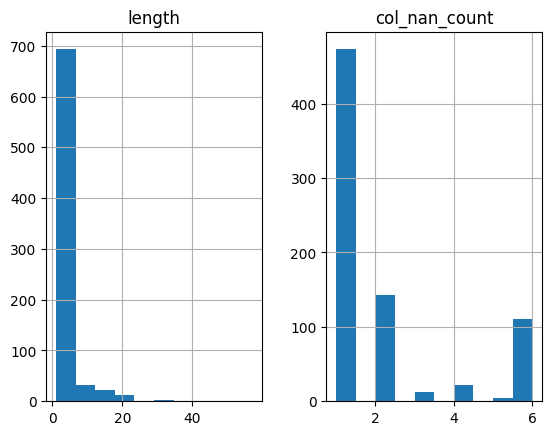

In [72]:
nan_df.hist(column=['length', 'col_nan_count'])
plt.show()

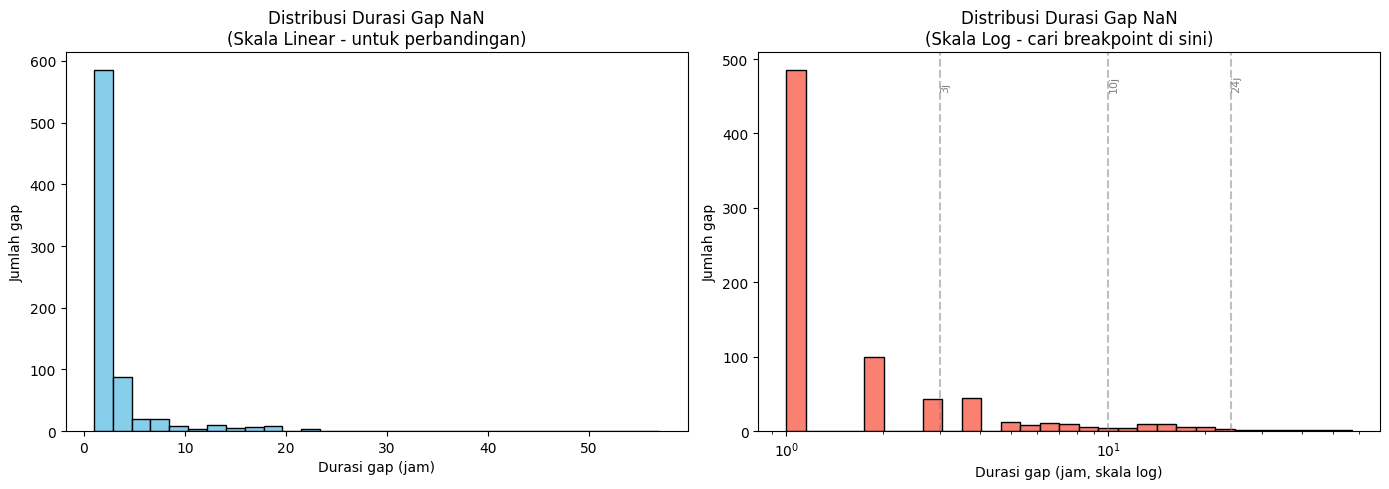


=== Tabel jumlah gap per rentang durasi ===
             jumlah_gap  persentase (%)
length                                 
1 jam               485           63.23
2 jam               100           13.04
3 jam                43            5.61
4-5 jam              57            7.43
6-10 jam             37            4.82
11-20 jam            34            4.43
21-50 jam            10            1.30
51-100 jam            1            0.13
101-200 jam           0            0.00
>200 jam              0            0.00

Perhatikan di rentang mana terjadi penurunan jumlah gap paling drastis
(persentase turun tajam) -> itu kandidat breakpoint natural.


In [73]:
plot_gap_histogram_log(nan_df)

In [74]:
nan_df.describe(include='all', percentiles=[0.75, 0.90])

,start,end,length,col_nan_count,start_season,end_season
count,767.000000,767.000000,767.000000,767.000000,767,767
unique,NaN,NaN,NaN,NaN,4,4
top,NaN,NaN,NaN,NaN,Summer,Summer
freq,NaN,NaN,NaN,NaN,243,243
mean,14124.771838,14126.663625,2.891786,2.056063,NaN,NaN
std,10954.423133,10954.100665,5.059182,1.767338,NaN,NaN
min,2.000000,2.000000,1.000000,1.000000,NaN,NaN
50%,9538.000000,9538.000000,1.000000,1.000000,NaN,NaN
75%,22666.000000,22666.000000,2.000000,2.000000,NaN,NaN
90%,30347.600000,30349.600000,6.000000,6.000000,NaN,NaN


Fungsi linear

In [75]:
limit = 5
filter_nan_df = nan_df[nan_df['length'] <= limit]
filter_nan_df

,start,end,length,col_nan_count,start_season,end_season
585,23403,23407,5,6,Autumn,Autumn
238,5141,5145,5,2,Autumn,Autumn
477,18637,18641,5,2,Spring,Spring
93,2630,2634,5,1,Summer,Summer
165,3278,3282,5,1,Summer,Summer
...,...,...,...,...,...,...
739,34386,34386,1,1,Winter,Winter
741,34718,34718,1,1,Winter,Winter
751,34900,34900,1,1,Winter,Winter
757,34948,34948,1,1,Winter,Winter


In [76]:
print(f'total row(s) affected: {filter_nan_df.length.sum()}')

total row(s) affected: 1054


In [77]:
clean_df_list[station_name].loc[23400: 23410, :]

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
23400,2015-11-01 00:00:00,114.0,160.0,3.0,85.0,1400.0,3.0,2.9,1023.2,0.6,0.0,E,1.1,Wanshouxigong,Autumn
23401,2015-11-01 01:00:00,118.0,156.0,2.0,78.0,1500.0,3.0,3.0,1022.8,0.7,0.0,ENE,1.1,Wanshouxigong,Autumn
23402,2015-11-01 02:00:00,111.0,148.0,2.0,69.0,1700.0,4.0,2.1,1022.8,0.3,0.0,ENE,1.2,Wanshouxigong,Autumn
23403,2015-11-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.9,1022.3,0.3,0.0,ESE,1.1,Wanshouxigong,Autumn
23404,2015-11-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.7,1021.6,-0.1,0.0,NE,0.2,Wanshouxigong,Autumn
23405,2015-11-01 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.1,1021.4,-0.5,0.0,NE,0.0,Wanshouxigong,Autumn
23406,2015-11-01 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,0.8,1021.2,-2.4,0.0,E,0.6,Wanshouxigong,Autumn
23407,2015-11-01 07:00:00,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1021.3,-2.2,0.0,ENE,1.1,Wanshouxigong,Autumn
23408,2015-11-01 08:00:00,27.0,46.0,2.0,50.0,700.0,3.0,2.0,1021.5,-0.6,0.0,SE,0.5,Wanshouxigong,Autumn
23409,2015-11-01 09:00:00,27.0,46.0,2.0,50.0,700.0,3.0,8.4,1021.6,-2.0,0.0,NNE,1.4,Wanshouxigong,Autumn


In [78]:
new_df = interpolate_linear(
    clean_df_list[station_name], pollutant_params, 5
)

In [79]:
new_df.loc[23400: 23410, :]

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
23400,2015-11-01 00:00:00,114.0,160.0,3.0,85.000000,1400.000000,3.000000,2.9,1023.2,0.6,0.0,E,1.1,Wanshouxigong,Autumn
23401,2015-11-01 01:00:00,118.0,156.0,2.0,78.000000,1500.000000,3.000000,3.0,1022.8,0.7,0.0,ENE,1.1,Wanshouxigong,Autumn
23402,2015-11-01 02:00:00,111.0,148.0,2.0,69.000000,1700.000000,4.000000,2.1,1022.8,0.3,0.0,ENE,1.2,Wanshouxigong,Autumn
23403,2015-11-01 03:00:00,97.0,131.0,2.0,65.833333,1533.333333,3.833333,1.9,1022.3,0.3,0.0,ESE,1.1,Wanshouxigong,Autumn
23404,2015-11-01 04:00:00,83.0,114.0,2.0,62.666667,1366.666667,3.666667,1.7,1021.6,-0.1,0.0,NE,0.2,Wanshouxigong,Autumn
23405,2015-11-01 05:00:00,69.0,97.0,2.0,59.500000,1200.000000,3.500000,1.1,1021.4,-0.5,0.0,NE,0.0,Wanshouxigong,Autumn
23406,2015-11-01 06:00:00,55.0,80.0,2.0,56.333333,1033.333333,3.333333,0.8,1021.2,-2.4,0.0,E,0.6,Wanshouxigong,Autumn
23407,2015-11-01 07:00:00,41.0,63.0,2.0,53.166667,866.666667,3.166667,1.0,1021.3,-2.2,0.0,ENE,1.1,Wanshouxigong,Autumn
23408,2015-11-01 08:00:00,27.0,46.0,2.0,50.000000,700.000000,3.000000,2.0,1021.5,-0.6,0.0,SE,0.5,Wanshouxigong,Autumn
23409,2015-11-01 09:00:00,27.0,46.0,2.0,50.000000,700.000000,3.000000,8.4,1021.6,-2.0,0.0,NNE,1.4,Wanshouxigong,Autumn


In [80]:
new_nan_df = create_nan_df(new_df, pollutant_params)
new_nan_df

,start,end,length,col_nan_count,start_season,end_season
60,8481,8556,76,4,Winter,Winter
77,14483,14533,51,4,Autumn,Autumn
98,29105,29147,43,6,Summer,Summer
72,12062,12098,37,1,Summer,Summer
50,6162,6195,34,1,Autumn,Autumn
...,...,...,...,...,...,...
61,8677,8677,1,1,Winter,Winter
63,8685,8685,1,1,Winter,Winter
83,18642,18642,1,1,Spring,Spring
92,24666,24666,1,1,Winter,Winter


In [81]:
filter_nan_df = new_nan_df[new_nan_df['length'] <= limit]
print(filter_nan_df.length.sum())
filter_nan_df

28


,start,end,length,col_nan_count,start_season,end_season
76,14480,14482,3,6,Autumn,Autumn
19,3006,3008,3,1,Summer,Summer
29,4581,4583,3,1,Autumn,Autumn
12,2652,2653,2,1,Summer,Summer
33,5129,5130,2,1,Autumn,Autumn
97,29004,29005,2,1,Summer,Summer
64,8688,8688,1,4,Winter,Winter
99,29148,29148,1,4,Summer,Summer
13,2654,2654,1,2,Summer,Summer
15,2675,2675,1,2,Summer,Summer


Fungsi Regresi

In [82]:
nan_df = create_nan_df(new_df, pollutant_params)
filter_nan_df = nan_df[
    (nan_df['col_nan_count'] == 1)
]
filter_nan_df.sort_values(by='length')

,start,end,length,col_nan_count,start_season,end_season
0,576,576,1,1,Spring,Spring
94,24684,24684,1,1,Winter,Winter
92,24666,24666,1,1,Winter,Winter
83,18642,18642,1,1,Spring,Spring
63,8685,8685,1,1,Winter,Winter
...,...,...,...,...,...,...
11,2434,2459,26,1,Summer,Summer
103,33860,33887,28,1,Winter,Winter
81,17022,17051,30,1,Winter,Winter
50,6162,6195,34,1,Autumn,Autumn


In [83]:
print(f'total row(s) affected: {filter_nan_df.length.sum()}')

total row(s) affected: 802


In [84]:
new_df.loc[2430:2460, :]

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
2430,2013-06-10 06:00:00,11.0,11.0,2.5704,26.2784,NaN,NaN,16.4,1007.4,16.1,0.0,NE,0.7,Wanshouxigong,Summer
2431,2013-06-10 07:00:00,17.0,21.0,3.7128,24.8413,NaN,NaN,17.4,1008.0,16.6,0.0,SSE,0.0,Wanshouxigong,Summer
2432,2013-06-10 08:00:00,29.0,59.0,4.5696,34.9010,NaN,NaN,19.5,1007.8,16.2,0.0,W,0.5,Wanshouxigong,Summer
2433,2013-06-10 09:00:00,28.0,28.0,4.2840,47.6296,NaN,NaN,21.7,1007.5,15.5,0.0,W,1.5,Wanshouxigong,Summer
2434,2013-06-10 10:00:00,22.0,22.0,5.9976,42.0865,NaN,18.8496,23.4,1007.2,14.4,0.0,WSW,2.1,Wanshouxigong,Summer
2435,2013-06-10 11:00:00,31.0,31.0,6.5688,26.2784,NaN,50.7654,24.6,1006.8,13.2,0.0,SW,1.9,Wanshouxigong,Summer
2436,2013-06-10 12:00:00,12.0,16.0,7.7112,20.7353,NaN,81.8244,25.6,1005.8,12.4,0.0,SSW,1.8,Wanshouxigong,Summer
2437,2013-06-10 13:00:00,21.0,21.0,5.9976,16.8346,NaN,98.5320,26.3,1005.4,11.2,0.0,SSW,1.3,Wanshouxigong,Summer
2438,2013-06-10 14:00:00,24.0,24.0,5.1408,15.1922,NaN,102.6018,26.1,1004.7,9.0,0.0,WSW,0.7,Wanshouxigong,Summer
2439,2013-06-10 15:00:00,13.0,13.0,2.5704,12.3180,NaN,87.3936,25.9,1004.5,9.3,0.0,SSE,0.8,Wanshouxigong,Summer


In [85]:
new_df = regression_impute_station(new_df)

Jumlah baris yang memenuhi syarat regresi (1 kolom NaN): 802
Predictor: ['PM10', 'SO2', 'NO2', 'CO', 'O3'] target: PM2.5

Memproses kolom target: PM2.5 (62 baris kandidat)
  [PM2.5] Model dilatih dari 33771 baris, berhasil mengisi 62 baris NaN.
Predictor: ['PM2.5', 'PM10', 'NO2', 'CO', 'O3'] target: SO2

Memproses kolom target: SO2 (30 baris kandidat)
  [SO2] Model dilatih dari 33833 baris, berhasil mengisi 30 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'CO', 'O3'] target: NO2

Memproses kolom target: NO2 (52 baris kandidat)
  [NO2] Model dilatih dari 33863 baris, berhasil mengisi 52 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'O3'] target: CO

Memproses kolom target: CO (380 baris kandidat)
  [CO] Model dilatih dari 33915 baris, berhasil mengisi 380 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO'] target: O3

Memproses kolom target: O3 (278 baris kandidat)
  [O3] Model dilatih dari 34295 baris, berhasil mengisi 278 baris NaN.


In [86]:
new_df.loc[2430:2460, :]

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
2430,2013-06-10 06:00:00,11.0,11.0,2.5704,26.2784,NaN,NaN,16.4,1007.4,16.1,0.0,NE,0.7,Wanshouxigong,Summer
2431,2013-06-10 07:00:00,17.0,21.0,3.7128,24.8413,NaN,NaN,17.4,1008.0,16.6,0.0,SSE,0.0,Wanshouxigong,Summer
2432,2013-06-10 08:00:00,29.0,59.0,4.5696,34.9010,NaN,NaN,19.5,1007.8,16.2,0.0,W,0.5,Wanshouxigong,Summer
2433,2013-06-10 09:00:00,28.0,28.0,4.2840,47.6296,NaN,NaN,21.7,1007.5,15.5,0.0,W,1.5,Wanshouxigong,Summer
2434,2013-06-10 10:00:00,22.0,22.0,5.9976,42.0865,738.649474,18.8496,23.4,1007.2,14.4,0.0,WSW,2.1,Wanshouxigong,Summer
2435,2013-06-10 11:00:00,31.0,31.0,6.5688,26.2784,630.320422,50.7654,24.6,1006.8,13.2,0.0,SW,1.9,Wanshouxigong,Summer
2436,2013-06-10 12:00:00,12.0,16.0,7.7112,20.7353,396.859485,81.8244,25.6,1005.8,12.4,0.0,SSW,1.8,Wanshouxigong,Summer
2437,2013-06-10 13:00:00,21.0,21.0,5.9976,16.8346,400.302981,98.5320,26.3,1005.4,11.2,0.0,SSW,1.3,Wanshouxigong,Summer
2438,2013-06-10 14:00:00,24.0,24.0,5.1408,15.1922,397.561499,102.6018,26.1,1004.7,9.0,0.0,WSW,0.7,Wanshouxigong,Summer
2439,2013-06-10 15:00:00,13.0,13.0,2.5704,12.3180,286.793394,87.3936,25.9,1004.5,9.3,0.0,SSE,0.8,Wanshouxigong,Summer


In [87]:
new_nan_df = create_nan_df(new_df, pollutant_params)
new_nan_df[new_nan_df['col_nan_count'] == 1].length.sum()

np.int64(0)

Fungsi custom

In [88]:
nan_df = create_nan_df(new_df, pollutant_params)
filter_nan_df = nan_df[
    ((nan_df['col_nan_count'] > 1) &
    (nan_df['length'] > 5) &
    (nan_df['length'] <= 48)) |
    ((nan_df['col_nan_count'] == 2) &
    (nan_df['length'] > 48))
]
filter_nan_df.sort_values(by='length')

,start,end,length,col_nan_count,start_season,end_season
5,3000,3005,6,2,Summer,Summer
6,4584,4589,6,2,Autumn,Autumn
27,22386,22391,6,6,Autumn,Autumn
24,15790,15795,6,6,Winter,Winter
12,8678,8684,7,6,Winter,Winter
14,8689,8695,7,6,Winter,Winter
17,10738,10744,7,6,Spring,Spring
9,7762,7768,7,4,Winter,Winter
0,577,584,8,2,Spring,Spring
25,18634,18641,8,2,Spring,Spring


In [89]:
filter_nan_df.length.sum()

np.int64(356)

In [90]:
indices = [i for _, row in filter_nan_df.iterrows() for i in range(row['start'], row['end'] + 1) ]
len(indices)

356

In [91]:
print(f'total row(s) affected: {filter_nan_df.length.sum()}')

total row(s) affected: 356


In [92]:
new_df.loc[10360:10390, :]

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
10360,2014-05-06 16:00:00,NaN,NaN,NaN,NaN,NaN,NaN,20.8,997.1,4.4,0.0,WSW,1.6,Wanshouxigong,Spring
10361,2014-05-06 17:00:00,NaN,NaN,NaN,NaN,NaN,NaN,20.5,996.9,4.9,0.0,W,2.1,Wanshouxigong,Spring
10362,2014-05-06 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN,20.1,996.6,4.9,0.0,W,2.2,Wanshouxigong,Spring
10363,2014-05-06 19:00:00,NaN,NaN,NaN,NaN,NaN,NaN,20.0,997.0,6.0,0.0,WNW,3.1,Wanshouxigong,Spring
10364,2014-05-06 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,18.5,997.0,7.3,0.0,NW,1.2,Wanshouxigong,Spring
10365,2014-05-06 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,16.4,997.9,7.9,0.0,WNW,1.5,Wanshouxigong,Spring
10366,2014-05-06 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,18.4,997.1,6.9,0.0,W,1.3,Wanshouxigong,Spring
10367,2014-05-06 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,14.6,996.8,11.6,0.2,NW,0.5,Wanshouxigong,Spring
10368,2014-05-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,16.5,996.9,9.7,0.0,WNW,1.5,Wanshouxigong,Spring
10369,2014-05-07 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,16.0,996.6,9.4,0.0,NW,1.1,Wanshouxigong,Spring


In [93]:
new_df = nearby_days_fill(new_df, pollutant_params, indices)

[PM2.5] Diisi pakai MEAN (skew rendah): 0 baris
[PM2.5] Diisi pakai MEDIAN (skew tinggi/sampel kecil): 291 baris
[PM2.5] Gagal, perlu fallback musiman: 0 baris

[PM10] Diisi pakai MEAN (skew rendah): 0 baris
[PM10] Diisi pakai MEDIAN (skew tinggi/sampel kecil): 271 baris
[PM10] Gagal, perlu fallback musiman: 0 baris

[SO2] Diisi pakai MEAN (skew rendah): 0 baris
[SO2] Diisi pakai MEDIAN (skew tinggi/sampel kecil): 300 baris
[SO2] Gagal, perlu fallback musiman: 0 baris

[NO2] Diisi pakai MEAN (skew rendah): 0 baris
[NO2] Diisi pakai MEDIAN (skew tinggi/sampel kecil): 300 baris
[NO2] Gagal, perlu fallback musiman: 0 baris

[CO] Diisi pakai MEAN (skew rendah): 0 baris
[CO] Diisi pakai MEDIAN (skew tinggi/sampel kecil): 348 baris
[CO] Gagal, perlu fallback musiman: 0 baris

[O3] Diisi pakai MEAN (skew rendah): 0 baris
[O3] Diisi pakai MEDIAN (skew tinggi/sampel kecil): 313 baris
[O3] Gagal, perlu fallback musiman: 0 baris



In [94]:
new_df.loc[10370:10390, :]

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
10370,2014-05-07 02:00:00,46.5,79.5,13.5,57.0,1050.0,54.0,13.8,996.2,9.2,0.0,WSW,0.7,Wanshouxigong,Spring
10371,2014-05-07 03:00:00,46.5,74.5,12.5,56.0,850.0,53.5,12.5,996.1,9.9,0.0,NW,1.1,Wanshouxigong,Spring
10372,2014-05-07 04:00:00,49.0,75.0,10.0,54.5,900.0,39.0,14.3,997.1,8.7,0.0,NW,0.7,Wanshouxigong,Spring
10373,2014-05-07 05:00:00,48.0,76.5,9.0,50.0,1000.0,33.5,13.0,997.7,9.6,0.0,NW,0.9,Wanshouxigong,Spring
10374,2014-05-07 06:00:00,51.0,90.5,9.0,64.5,1250.0,29.0,16.2,998.6,7.1,0.0,NW,2.3,Wanshouxigong,Spring
10375,2014-05-07 07:00:00,49.5,93.0,15.5,64.0,1350.0,43.5,18.8,999.1,2.6,0.0,NNW,4.0,Wanshouxigong,Spring
10376,2014-05-07 08:00:00,53.0,94.0,27.5,48.5,1300.0,63.5,20.5,999.5,-1.4,0.0,WNW,3.2,Wanshouxigong,Spring
10377,2014-05-07 09:00:00,33.0,33.0,33.0,46.0,1200.0,71.0,20.7,999.8,-1.2,0.0,NW,3.2,Wanshouxigong,Spring
10378,2014-05-07 10:00:00,33.0,33.0,32.0,43.5,950.0,73.5,22.2,1000.1,-0.5,0.0,W,2.2,Wanshouxigong,Spring
10379,2014-05-07 11:00:00,13.0,13.0,17.0,25.0,750.0,89.0,23.4,1000.3,-3.1,0.0,NNE,3.6,Wanshouxigong,Spring


In [95]:
nan_df = create_nan_df(new_df, pollutant_params)
nan_df

,start,end,length,col_nan_count,start_season,end_season
2,8481,8556,76,4,Winter,Winter
6,14483,14533,51,4,Autumn,Autumn
5,14480,14482,3,6,Autumn,Autumn
3,8688,8688,1,4,Winter,Winter
7,29148,29148,1,4,Summer,Summer
0,2654,2654,1,2,Summer,Summer
1,2675,2675,1,2,Summer,Summer
4,10745,10745,1,2,Spring,Spring


In [96]:
limit = 5
filter_nan_df = nan_df[nan_df['length'] <= limit]
filter_nan_df

,start,end,length,col_nan_count,start_season,end_season
5,14480,14482,3,6,Autumn,Autumn
3,8688,8688,1,4,Winter,Winter
7,29148,29148,1,4,Summer,Summer
0,2654,2654,1,2,Summer,Summer
1,2675,2675,1,2,Summer,Summer
4,10745,10745,1,2,Spring,Spring


In [97]:
print(f'total row(s) affected: {filter_nan_df.length.sum()}')

total row(s) affected: 8


In [98]:
new_df = interpolate_linear(new_df, pollutant_params, limit)

In [99]:
new_nan_df = create_nan_df(new_df, pollutant_params)
new_nan_df

,start,end,length,col_nan_count,start_season,end_season
0,8481,8556,76,4,Winter,Winter
1,14480,14533,54,4,Autumn,Autumn


In [100]:
check_outlier(new_df, pollutant_params)

PM2.5: 1758 (5.01)
PM10: 1368 (3.90)
SO2: 3264 (9.31)
NO2: 585 (1.67)
CO: 2402 (6.85)
O3: 1301 (3.71)


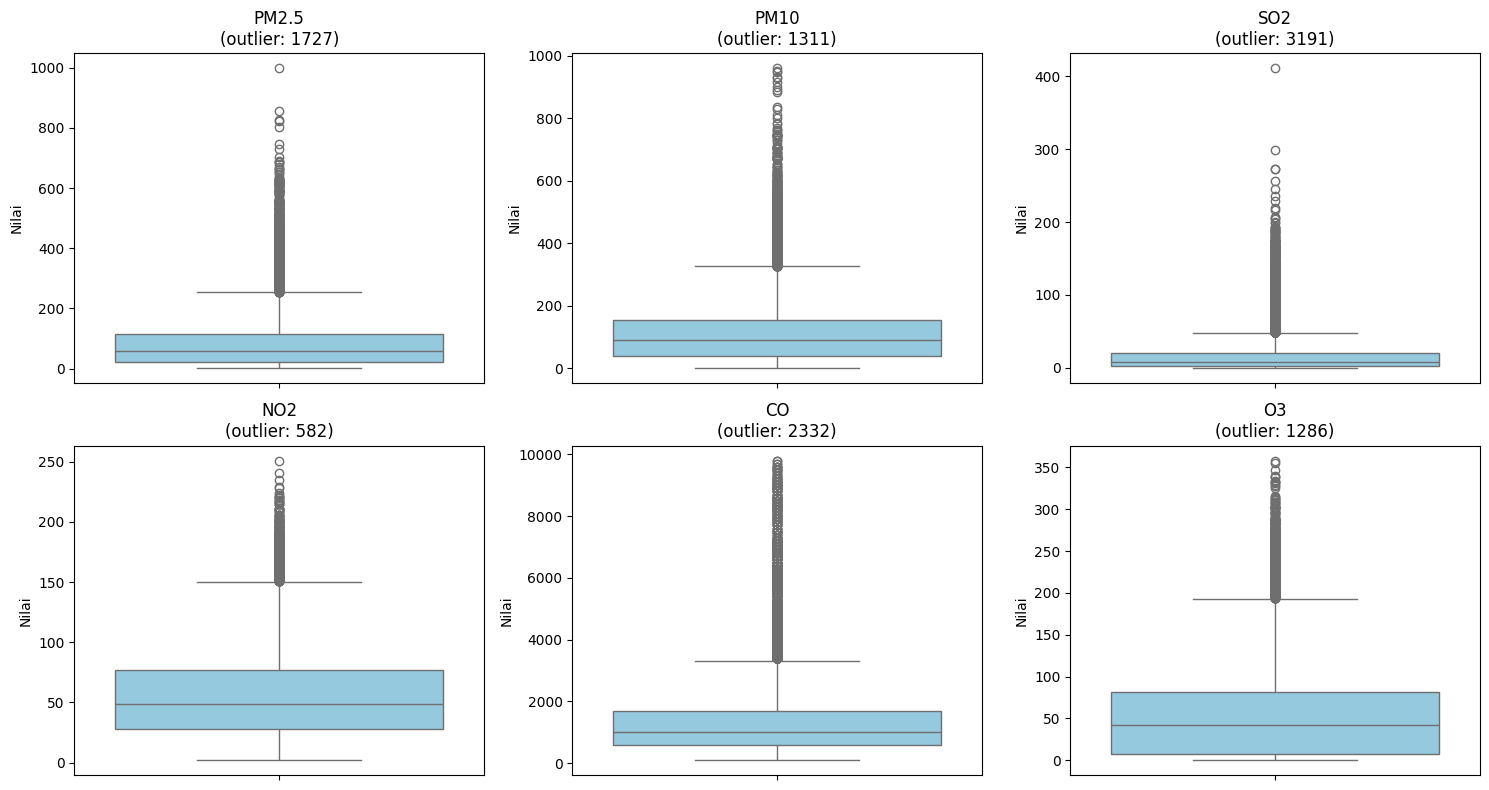

In [101]:
plot_outlier_boxplots(clean_df_list[station_name], pollutant_params)

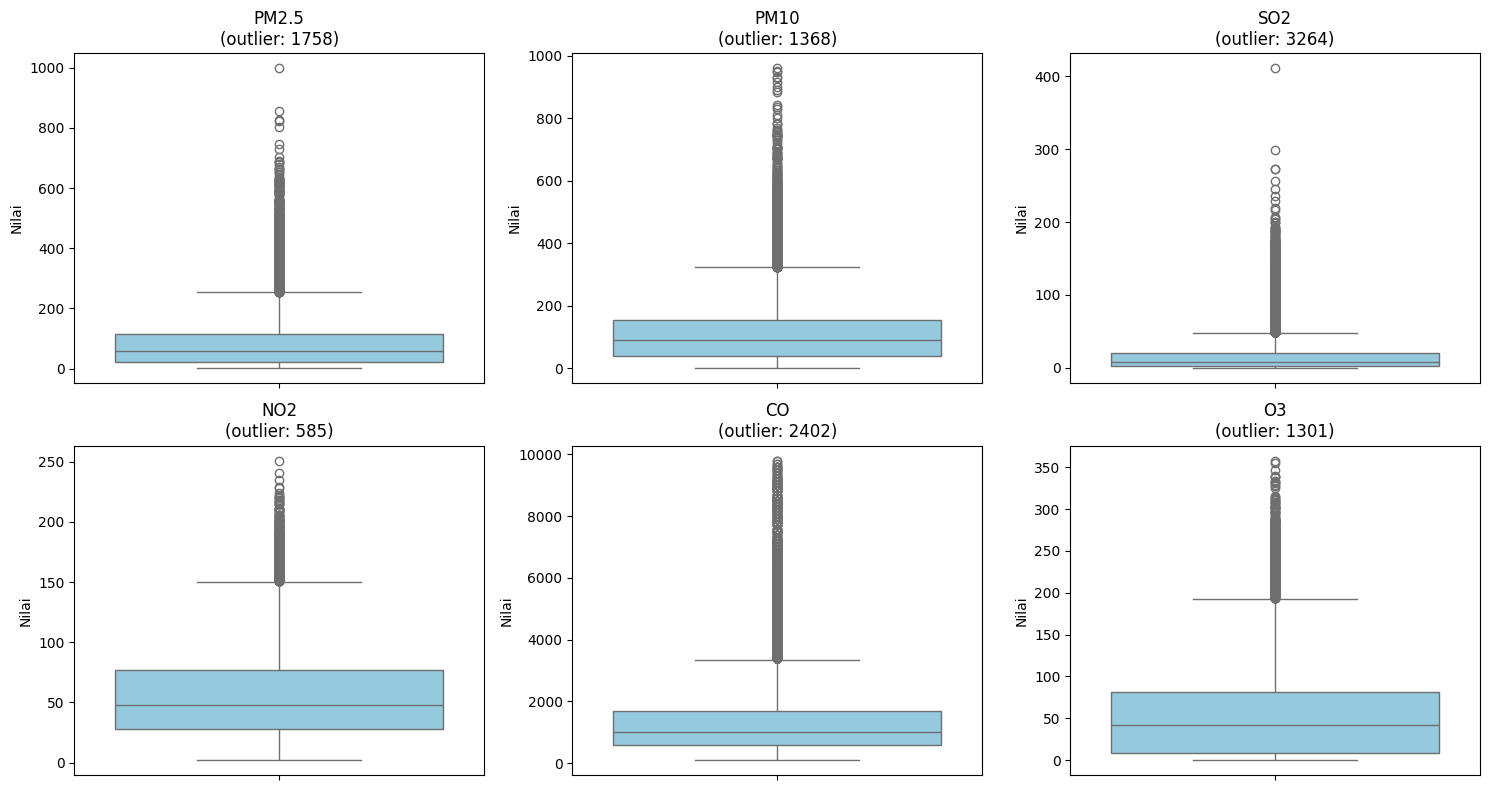

In [102]:
plot_outlier_boxplots(new_df, pollutant_params)

###### Overall

In [103]:
def _clean_col_station_linear(df_station, params, limit):
    df_result = df_station.copy()
    new_df = interpolate_linear(
        df_result, params, limit
    )

    return new_df


def _clean_col_station_regression(df_station, params):
    df_result = df_station.copy()
    new_df = regression_impute_station(df_result)

    return new_df


def _clean_col_station_custom(df_station, params):
    df_result = df_station.copy()

    # Fungsi custom
    nan_df = create_nan_df(df_result, params)

    if nan_df.empty: return df_result

    filter_nan_df = nan_df[
        ((nan_df['col_nan_count'] > 1) &
        (nan_df['length'] > 5) &
        (nan_df['length'] <= 48)) |
        ((nan_df['col_nan_count'] == 2) &
        (nan_df['length'] > 48))
    ]

    indices = [
        i
        for _, row in filter_nan_df.iterrows()
        for i in range(row['start'], row['end'] + 1)
    ]

    new_df = nearby_days_fill(
        df_result, params, indices
    )

    return new_df


def _clean_col_station_seasonal(df_station, params):
    df_result = df_station.copy()

    nan_df = create_nan_df(df_result, params)

    if nan_df.empty: return df_result

    filter_nan_df = nan_df[
        ((nan_df['col_nan_count'] > 1) &
        (nan_df['length'] > 5) &
        (nan_df['length'] <= 48)) |
        ((nan_df['col_nan_count'] == 2) &
        (nan_df['length'] > 48))
    ]

    new_df = interpolate_seasonal(df_result, filter_nan_df, params)

    return new_df


def clean_pollutant_col_station(
        df_station: pd.DataFrame,
        steps: list[str],
        params=pollutant_params,
        limit=5
) -> pd.DataFrame:
    df_result = df_station.copy()

    for step in steps:
        print(f'{step}\n')

        match step:
            case 'linear':
                df_result = _clean_col_station_linear(df_result, params, limit)

            case 'regression':
                df_result = _clean_col_station_regression(df_result, params)

            case 'custom':
                df_result = _clean_col_station_custom(df_result, params)

            case 'season':
                df_result = _clean_col_station_seasonal(df_result, params)

        print()

    check_outlier(df_result, params)

    return df_result

In [104]:
missing_value_result_df_map = {}
for key in df_list.keys():
    missing_value_result_df_map[key] = None

###### Station aotizhongxin

In [105]:
limit = 5
station_name = 'aotizhongxin'
station_df = clean_pollutant_col_station(
    clean_df_list[station_name],
    ['linear', 'regression', 'custom', 'linear'],
    pollutant_params
)

linear


regression

Jumlah baris yang memenuhi syarat regresi (1 kolom NaN): 1238
Predictor: ['PM10', 'SO2', 'NO2', 'CO', 'O3'] target: PM2.5

Memproses kolom target: PM2.5 (135 baris kandidat)
  [PM2.5] Model dilatih dari 33170 baris, berhasil mengisi 135 baris NaN.
Predictor: ['PM2.5', 'PM10', 'NO2', 'CO', 'O3'] target: SO2

Memproses kolom target: SO2 (66 baris kandidat)
  [SO2] Model dilatih dari 33305 baris, berhasil mengisi 66 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'CO', 'O3'] target: NO2

Memproses kolom target: NO2 (42 baris kandidat)
  [NO2] Model dilatih dari 33371 baris, berhasil mengisi 42 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'O3'] target: CO

Memproses kolom target: CO (634 baris kandidat)
  [CO] Model dilatih dari 33413 baris, berhasil mengisi 634 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO'] target: O3

Memproses kolom target: O3 (361 baris kandidat)
  [O3] Model dilatih dari 34047 baris, berhasil mengisi 361 baris NaN.

custom

[P

In [106]:
new_nan_df = create_nan_df(station_df, pollutant_params)
new_nan_df

,start,end,length,col_nan_count,start_season,end_season
1,15754,16096,343,6,Winter,Winter
0,10121,10184,64,6,Spring,Spring


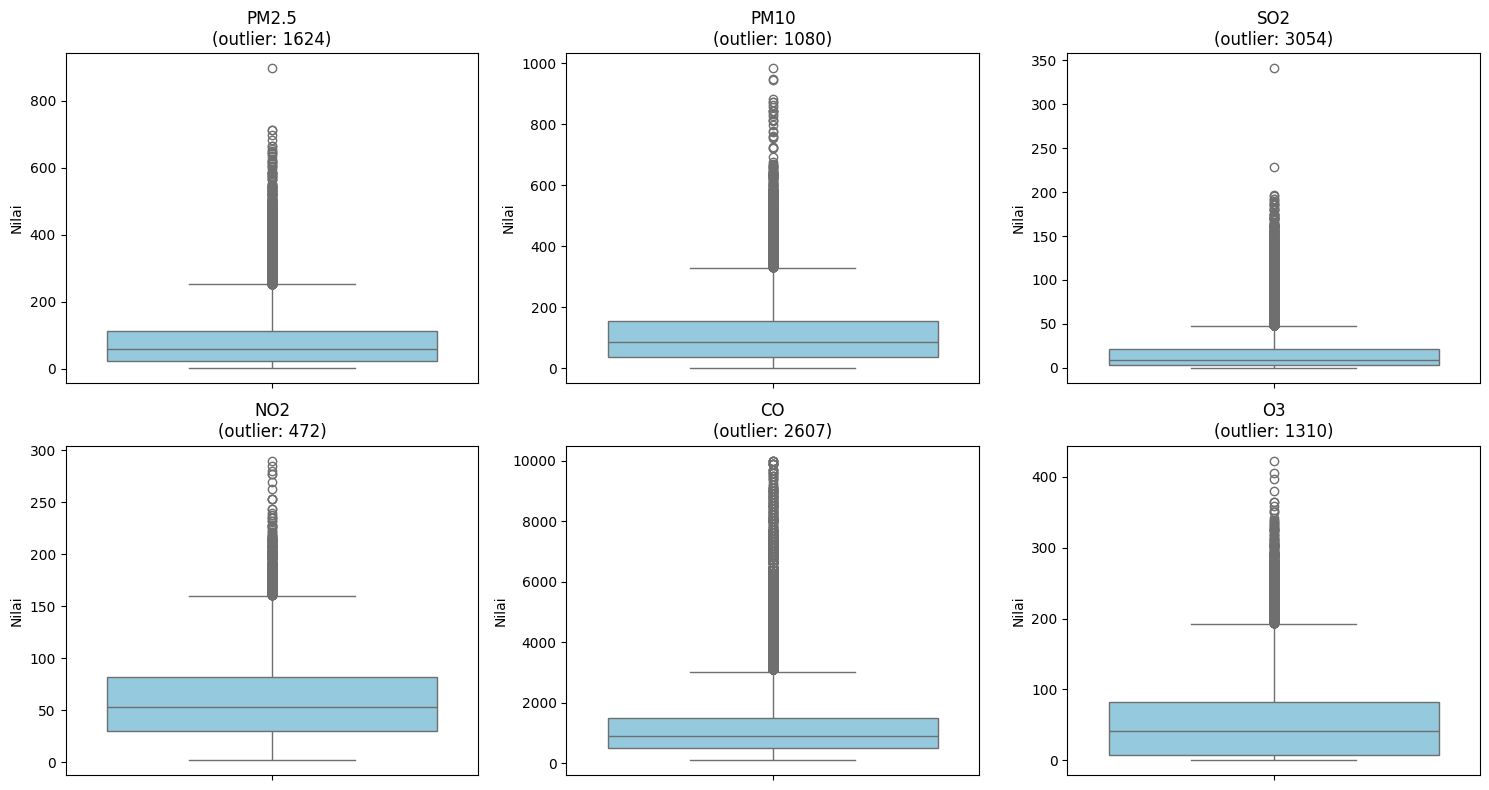

In [107]:
plot_outlier_boxplots(clean_df_list[station_name], pollutant_params)

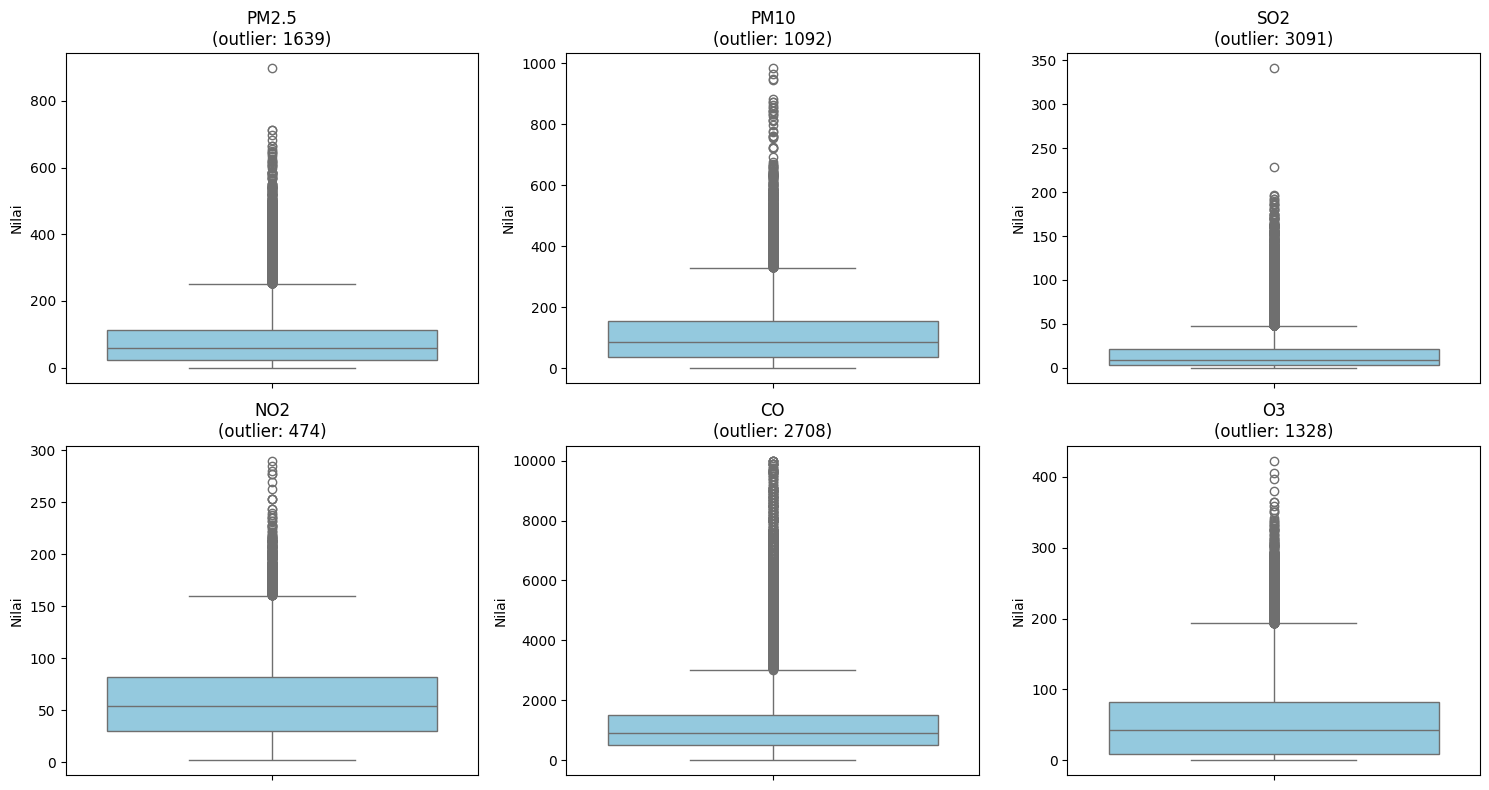

In [108]:
plot_outlier_boxplots(station_df, pollutant_params)

In [109]:
missing_value_result_df_map[station_name] = station_df

###### Station nongzhanguan

In [110]:
station_name = 'nongzhanguan'
station_df = clean_pollutant_col_station(
    clean_df_list[station_name],
    ['linear', 'regression', 'custom', 'linear'],
    pollutant_params
)

linear


regression

Jumlah baris yang memenuhi syarat regresi (1 kolom NaN): 783
Predictor: ['PM10', 'SO2', 'NO2', 'CO', 'O3'] target: PM2.5

Memproses kolom target: PM2.5 (61 baris kandidat)
  [PM2.5] Model dilatih dari 34069 baris, berhasil mengisi 61 baris NaN.
Predictor: ['PM2.5', 'PM10', 'NO2', 'CO', 'O3'] target: SO2

Memproses kolom target: SO2 (1 baris kandidat)
  [SO2] Model dilatih dari 34130 baris, berhasil mengisi 1 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'CO', 'O3'] target: NO2

Memproses kolom target: NO2 (160 baris kandidat)
  [NO2] Model dilatih dari 34131 baris, berhasil mengisi 160 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'O3'] target: CO

Memproses kolom target: CO (550 baris kandidat)
  [CO] Model dilatih dari 34291 baris, berhasil mengisi 550 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO'] target: O3

Memproses kolom target: O3 (11 baris kandidat)
  [O3] Model dilatih dari 34841 baris, berhasil mengisi 11 baris NaN.

custom

[PM2.5]

In [111]:
new_nan_df = create_nan_df(station_df, pollutant_params)
new_nan_df

,start,end,length,col_nan_count,start_season,end_season
0,22835,22889,55,6,Autumn,Autumn


In [112]:
missing_value_result_df_map[station_name] = station_df

###### Station dongsi

In [113]:
station_name = 'dongsi'
station_df = clean_pollutant_col_station(
    clean_df_list[station_name],
    ['linear', 'regression', 'custom', 'linear'],
    pollutant_params
)

linear


regression

Jumlah baris yang memenuhi syarat regresi (1 kolom NaN): 3558
Predictor: ['PM10', 'SO2', 'NO2', 'CO', 'O3'] target: PM2.5

Memproses kolom target: PM2.5 (130 baris kandidat)
  [PM2.5] Model dilatih dari 31097 baris, berhasil mengisi 130 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'CO', 'O3'] target: NO2

Memproses kolom target: NO2 (999 baris kandidat)
  [NO2] Model dilatih dari 31227 baris, berhasil mengisi 999 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'O3'] target: CO

Memproses kolom target: CO (2406 baris kandidat)
  [CO] Model dilatih dari 32226 baris, berhasil mengisi 2406 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO'] target: O3

Memproses kolom target: O3 (23 baris kandidat)
  [O3] Model dilatih dari 34632 baris, berhasil mengisi 23 baris NaN.

custom

[PM2.5] Diisi pakai MEAN (skew rendah): 0 baris
[PM2.5] Diisi pakai MEDIAN (skew tinggi/sampel kecil): 194 baris
[PM2.5] Gagal, perlu fallback musiman: 0 baris

[PM10] Diisi pakai 

In [114]:
new_nan_df = create_nan_df(station_df, pollutant_params)
new_nan_df

,start,end,length,col_nan_count,start_season,end_season
0,28593,28649,57,6,Summer,Summer
1,29770,29824,55,6,Summer,Summer
2,29825,29825,1,4,Summer,Summer


In [115]:
missing_value_result_df_map[station_name] = station_df

###### Station wanshouxigong

In [116]:
station_name = 'wanshouxigong'
station_df = clean_pollutant_col_station(
    clean_df_list[station_name],
    ['linear', 'regression', 'custom', 'linear'],
    pollutant_params
)

linear


regression

Jumlah baris yang memenuhi syarat regresi (1 kolom NaN): 802
Predictor: ['PM10', 'SO2', 'NO2', 'CO', 'O3'] target: PM2.5

Memproses kolom target: PM2.5 (62 baris kandidat)
  [PM2.5] Model dilatih dari 33771 baris, berhasil mengisi 62 baris NaN.
Predictor: ['PM2.5', 'PM10', 'NO2', 'CO', 'O3'] target: SO2

Memproses kolom target: SO2 (30 baris kandidat)
  [SO2] Model dilatih dari 33833 baris, berhasil mengisi 30 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'CO', 'O3'] target: NO2

Memproses kolom target: NO2 (52 baris kandidat)
  [NO2] Model dilatih dari 33863 baris, berhasil mengisi 52 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'O3'] target: CO

Memproses kolom target: CO (380 baris kandidat)
  [CO] Model dilatih dari 33915 baris, berhasil mengisi 380 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO'] target: O3

Memproses kolom target: O3 (278 baris kandidat)
  [O3] Model dilatih dari 34295 baris, berhasil mengisi 278 baris NaN.

custom

[PM2.

In [117]:
new_nan_df = create_nan_df(station_df, pollutant_params)
new_nan_df

,start,end,length,col_nan_count,start_season,end_season
0,8481,8556,76,4,Winter,Winter
1,14480,14533,54,4,Autumn,Autumn


In [118]:
missing_value_result_df_map[station_name] = station_df

###### Station dingling

In [119]:
station_name = 'dingling'
station_df = clean_pollutant_col_station(
    clean_df_list[station_name],
    ['linear', 'regression', 'custom', 'linear'],
    pollutant_params
)

linear


regression

Jumlah baris yang memenuhi syarat regresi (1 kolom NaN): 2139
Predictor: ['PM10', 'SO2', 'NO2', 'CO', 'O3'] target: PM2.5

Memproses kolom target: PM2.5 (107 baris kandidat)
  [PM2.5] Model dilatih dari 32487 baris, berhasil mengisi 107 baris NaN.
Predictor: ['PM2.5', 'PM10', 'NO2', 'CO', 'O3'] target: SO2

Memproses kolom target: SO2 (53 baris kandidat)
  [SO2] Model dilatih dari 32594 baris, berhasil mengisi 53 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'CO', 'O3'] target: NO2

Memproses kolom target: NO2 (394 baris kandidat)
  [NO2] Model dilatih dari 32647 baris, berhasil mengisi 394 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'O3'] target: CO

Memproses kolom target: CO (1180 baris kandidat)
  [CO] Model dilatih dari 33041 baris, berhasil mengisi 1180 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO'] target: O3

Memproses kolom target: O3 (405 baris kandidat)
  [O3] Model dilatih dari 34221 baris, berhasil mengisi 405 baris NaN.

custom

In [120]:
new_nan_df = create_nan_df(station_df, pollutant_params)
new_nan_df

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [121]:
missing_value_result_df_map[station_name] = station_df

###### Station wanliu

In [122]:
station_name = 'wanliu'
station_df = clean_pollutant_col_station(
    clean_df_list[station_name],
    ['linear', 'regression', 'custom', 'linear', 'custom'],
    pollutant_params
)

linear


regression

Jumlah baris yang memenuhi syarat regresi (1 kolom NaN): 2322
Predictor: ['PM10', 'SO2', 'NO2', 'CO', 'O3'] target: PM2.5

Memproses kolom target: PM2.5 (17 baris kandidat)
  [PM2.5] Model dilatih dari 32236 baris, berhasil mengisi 17 baris NaN.
Predictor: ['PM2.5', 'PM10', 'NO2', 'CO', 'O3'] target: SO2

Memproses kolom target: SO2 (43 baris kandidat)
  [SO2] Model dilatih dari 32253 baris, berhasil mengisi 43 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'CO', 'O3'] target: NO2

Memproses kolom target: NO2 (556 baris kandidat)
  [NO2] Model dilatih dari 32296 baris, berhasil mengisi 556 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'O3'] target: CO

Memproses kolom target: CO (934 baris kandidat)
  [CO] Model dilatih dari 32852 baris, berhasil mengisi 934 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO'] target: O3

Memproses kolom target: O3 (772 baris kandidat)
  [O3] Model dilatih dari 33786 baris, berhasil mengisi 772 baris NaN.

custom

[P

In [123]:
new_nan_df = create_nan_df(station_df, pollutant_params)
new_nan_df

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [124]:
missing_value_result_df_map[station_name] = station_df

###### Station changping

In [125]:
station_name = 'changping'
station_df = clean_pollutant_col_station(
    clean_df_list[station_name],
    ['linear', 'regression', 'custom', 'linear'],
    pollutant_params
)

linear


regression

Jumlah baris yang memenuhi syarat regresi (1 kolom NaN): 828
Predictor: ['PM10', 'SO2', 'NO2', 'CO', 'O3'] target: PM2.5

Memproses kolom target: PM2.5 (116 baris kandidat)
  [PM2.5] Model dilatih dari 33848 baris, berhasil mengisi 116 baris NaN.
Predictor: ['PM2.5', 'PM10', 'NO2', 'CO', 'O3'] target: SO2

Memproses kolom target: SO2 (74 baris kandidat)
  [SO2] Model dilatih dari 33964 baris, berhasil mengisi 74 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'CO', 'O3'] target: NO2

Memproses kolom target: NO2 (63 baris kandidat)
  [NO2] Model dilatih dari 34038 baris, berhasil mengisi 63 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'O3'] target: CO

Memproses kolom target: CO (554 baris kandidat)
  [CO] Model dilatih dari 34101 baris, berhasil mengisi 554 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO'] target: O3

Memproses kolom target: O3 (21 baris kandidat)
  [O3] Model dilatih dari 34655 baris, berhasil mengisi 21 baris NaN.

custom

[PM2.

In [126]:
new_nan_df = create_nan_df(station_df, pollutant_params)
new_nan_df

,start,end,length,col_nan_count,start_season,end_season
0,10121,10184,64,6,Spring,Spring
1,22818,22880,63,6,Autumn,Autumn


In [127]:
missing_value_result_df_map[station_name] = station_df

###### Station guanyuan

In [128]:
station_name = 'guanyuan'
station_df = clean_pollutant_col_station(
    clean_df_list[station_name],
    ['linear', 'regression', 'custom', 'linear'],
    pollutant_params
)

linear


regression

Jumlah baris yang memenuhi syarat regresi (1 kolom NaN): 1269
Predictor: ['PM10', 'SO2', 'NO2', 'CO', 'O3'] target: PM2.5

Memproses kolom target: PM2.5 (128 baris kandidat)
  [PM2.5] Model dilatih dari 33216 baris, berhasil mengisi 128 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'CO', 'O3'] target: NO2

Memproses kolom target: NO2 (98 baris kandidat)
  [NO2] Model dilatih dari 33344 baris, berhasil mengisi 98 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'O3'] target: CO

Memproses kolom target: CO (737 baris kandidat)
  [CO] Model dilatih dari 33442 baris, berhasil mengisi 737 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO'] target: O3

Memproses kolom target: O3 (306 baris kandidat)
  [O3] Model dilatih dari 34179 baris, berhasil mengisi 306 baris NaN.

custom

[PM2.5] Diisi pakai MEAN (skew rendah): 0 baris
[PM2.5] Diisi pakai MEDIAN (skew tinggi/sampel kecil): 181 baris
[PM2.5] Gagal, perlu fallback musiman: 0 baris

[PM10] Diisi pakai ME

In [129]:
new_nan_df = create_nan_df(station_df, pollutant_params)
new_nan_df

,start,end,length,col_nan_count,start_season,end_season
0,14531,14633,103,4,Autumn,Autumn


In [130]:
missing_value_result_df_map[station_name] = station_df

###### Station huairou

In [131]:
station_name = 'huairou'
station_df = clean_pollutant_col_station(
    clean_df_list[station_name],
    ['linear', 'regression', 'custom', 'linear'],
    pollutant_params
)

linear


regression

Jumlah baris yang memenuhi syarat regresi (1 kolom NaN): 856
Predictor: ['PM10', 'SO2', 'NO2', 'CO', 'O3'] target: PM2.5

Memproses kolom target: PM2.5 (68 baris kandidat)
  [PM2.5] Model dilatih dari 33676 baris, berhasil mengisi 68 baris NaN.
Predictor: ['PM2.5', 'PM10', 'NO2', 'CO', 'O3'] target: SO2

Memproses kolom target: SO2 (58 baris kandidat)
  [SO2] Model dilatih dari 33744 baris, berhasil mengisi 58 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'CO', 'O3'] target: NO2

Memproses kolom target: NO2 (336 baris kandidat)
  [NO2] Model dilatih dari 33802 baris, berhasil mengisi 336 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'O3'] target: CO

Memproses kolom target: CO (266 baris kandidat)
  [CO] Model dilatih dari 34138 baris, berhasil mengisi 266 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO'] target: O3

Memproses kolom target: O3 (128 baris kandidat)
  [O3] Model dilatih dari 34404 baris, berhasil mengisi 128 baris NaN.

custom

[PM

In [132]:
new_nan_df = create_nan_df(station_df, pollutant_params)
new_nan_df

,start,end,length,col_nan_count,start_season,end_season
0,1604,1810,207,6,Spring,Spring
2,10932,11024,93,6,Spring,Summer
1,1811,1811,1,3,Spring,Spring


In [133]:
missing_value_result_df_map[station_name] = station_df

###### Station tiantan

In [134]:
station_name = 'tiantan'
station_df = clean_pollutant_col_station(
    clean_df_list[station_name],
    ['linear', 'regression', 'custom', 'linear'],
    pollutant_params
)

linear


regression

Jumlah baris yang memenuhi syarat regresi (1 kolom NaN): 928
Predictor: ['PM10', 'SO2', 'NO2', 'CO', 'O3'] target: PM2.5

Memproses kolom target: PM2.5 (9 baris kandidat)
  [PM2.5] Model dilatih dari 33906 baris, berhasil mengisi 9 baris NaN.
Predictor: ['PM2.5', 'PM10', 'NO2', 'CO', 'O3'] target: SO2

Memproses kolom target: SO2 (489 baris kandidat)
  [SO2] Model dilatih dari 33915 baris, berhasil mengisi 489 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'CO', 'O3'] target: NO2

Memproses kolom target: NO2 (25 baris kandidat)
  [NO2] Model dilatih dari 34404 baris, berhasil mengisi 25 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'O3'] target: CO

Memproses kolom target: CO (304 baris kandidat)
  [CO] Model dilatih dari 34429 baris, berhasil mengisi 304 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO'] target: O3

Memproses kolom target: O3 (101 baris kandidat)
  [O3] Model dilatih dari 34733 baris, berhasil mengisi 101 baris NaN.

custom

[PM2.

In [135]:
new_nan_df = create_nan_df(station_df, pollutant_params)
new_nan_df

,start,end,length,col_nan_count,start_season,end_season
0,8481,8556,76,4,Winter,Winter


In [136]:
missing_value_result_df_map[station_name] = station_df

###### Station gucheng

In [137]:
station_name = 'gucheng'
station_df = clean_pollutant_col_station(
    clean_df_list[station_name],
    ['linear', 'regression', 'custom', 'linear'],
    pollutant_params
)

linear


regression

Jumlah baris yang memenuhi syarat regresi (1 kolom NaN): 1258
Predictor: ['PM10', 'SO2', 'NO2', 'CO', 'O3'] target: PM2.5

Memproses kolom target: PM2.5 (142 baris kandidat)
  [PM2.5] Model dilatih dari 33451 baris, berhasil mengisi 142 baris NaN.
Predictor: ['PM2.5', 'PM10', 'NO2', 'CO', 'O3'] target: SO2

Memproses kolom target: SO2 (42 baris kandidat)
  [SO2] Model dilatih dari 33593 baris, berhasil mengisi 42 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'CO', 'O3'] target: NO2

Memproses kolom target: NO2 (160 baris kandidat)
  [NO2] Model dilatih dari 33635 baris, berhasil mengisi 160 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'O3'] target: CO

Memproses kolom target: CO (709 baris kandidat)
  [CO] Model dilatih dari 33795 baris, berhasil mengisi 709 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO'] target: O3

Memproses kolom target: O3 (205 baris kandidat)
  [O3] Model dilatih dari 34504 baris, berhasil mengisi 205 baris NaN.

custom



In [138]:
new_nan_df = create_nan_df(station_df, pollutant_params)
new_nan_df

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [139]:
missing_value_result_df_map[station_name] = station_df

###### Station shunyi

In [140]:
station_name = 'shunyi'
station_df = clean_pollutant_col_station(
    clean_df_list[station_name],
    ['linear', 'regression', 'custom', 'linear', 'custom'],
    pollutant_params
)

linear


regression

Jumlah baris yang memenuhi syarat regresi (1 kolom NaN): 1944
Predictor: ['PM10', 'SO2', 'NO2', 'CO', 'O3'] target: PM2.5

Memproses kolom target: PM2.5 (210 baris kandidat)
  [PM2.5] Model dilatih dari 32349 baris, berhasil mengisi 210 baris NaN.
Predictor: ['PM2.5', 'PM10', 'NO2', 'CO', 'O3'] target: SO2

Memproses kolom target: SO2 (131 baris kandidat)
  [SO2] Model dilatih dari 32559 baris, berhasil mengisi 131 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'CO', 'O3'] target: NO2

Memproses kolom target: NO2 (527 baris kandidat)
  [NO2] Model dilatih dari 32690 baris, berhasil mengisi 527 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'O3'] target: CO

Memproses kolom target: CO (525 baris kandidat)
  [CO] Model dilatih dari 33217 baris, berhasil mengisi 525 baris NaN.
Predictor: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO'] target: O3

Memproses kolom target: O3 (551 baris kandidat)
  [O3] Model dilatih dari 33742 baris, berhasil mengisi 551 baris NaN.

custom

In [141]:
new_nan_df = create_nan_df(station_df, pollutant_params)
new_nan_df

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [142]:
missing_value_result_df_map[station_name] = station_df

In [143]:
for key, value in missing_value_result_df_map.items():
    if value is None: print(key)

##### Support params

Cara menangani missing value dibagi menjadi beberapa kelompok:
1. Kelompok 1: TEMP, PRES, DEWP
1. Kelompok 2: WSPM
1. Kelompok 3: RAIN
---------------------------------------------------------------------

1. Kelompok 1 (TEMP, PRES, DEWP) \
Ketiga parameter ini memiliki karakter yang sama dengan parameter polutan, karena mempunyai korelasi kuat satu sama lain
| Jumlah Kolom NaN	| ≤6 jam | 7-12 jam | 12-48 jam | >48 jam |
|-------------------|--------|----------|-----------|---------|
| 1 kolom           | Linear | Regresi  | Regresi   | Regresi |
| 2 kolom           | Linear | Custom   | Custom    | Custom  |
| 3 kolom           | Linear | Custom   | Custom    | NaN/drop|

1. Kelompok 2 (WSPM) \
Untuk parameter ini, karena bersifat kontinu, maka perlakuan yang perlu dilakukan seharusnya masih sama
| Jam	   | treatment |
|----------|-----------|
| ≤6 jam   | Linear    |
| 6-48 jam | Custom    |
| >48 jam  | NaN/drop  |

1. Kelompok 3 (RAIN) \
Untuk parameter ini, karena sifatnya melompat tiba-tiba alias bukan kontinu dan mayoritas datanya adalah 0, maka yang NaN kita akan mengisi 0

###### Fill RAIN

In [144]:
def fill_rain_nan_with_0(df):
    df['RAIN'] = df['RAIN'].fillna(0)
    return df

###### Research station

In [145]:
station_name = 'aotizhongxin'
params = ['TEMP', 'PRES', 'DEWP']
nan_df = create_nan_df(missing_value_result_df_map[station_name], params)
nan_df

,start,end,length,col_nan_count,start_season,end_season
3,31315,31320,6,3,Autumn,Autumn
6,34083,34088,6,3,Winter,Winter
7,34285,34287,3,3,Winter,Winter
0,16748,16748,1,3,Winter,Winter
1,17263,17263,1,3,Winter,Winter
2,31047,31047,1,3,Autumn,Autumn
4,33872,33872,1,3,Winter,Winter
5,33882,33882,1,3,Winter,Winter


In [146]:
missing_value_result_df_map[station_name].loc[31310:31325]

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
31310,2016-09-25 14:00:00,129.0,129.0,2.0,38.0,1100.0,103.0,26.400000,1010.00,18.2,0.0,NE,0.6,Aotizhongxin,Autumn
31311,2016-09-25 15:00:00,137.0,140.0,4.0,43.0,1500.0,115.0,26.825000,1009.25,18.1,0.0,NE,2.1,Aotizhongxin,Autumn
31312,2016-09-25 16:00:00,162.0,177.0,4.0,49.0,2000.0,123.0,27.150000,1009.00,18.4,0.0,NW,1.3,Aotizhongxin,Autumn
31313,2016-09-25 17:00:00,168.0,168.0,3.0,56.0,2000.0,116.0,26.825000,1009.00,19.1,0.0,NE,1.3,Aotizhongxin,Autumn
31314,2016-09-25 18:00:00,167.0,167.0,3.0,62.0,2100.0,103.0,26.200000,1009.00,19.6,0.0,NE,1.3,Aotizhongxin,Autumn
31315,2016-09-25 19:00:00,168.0,168.0,2.0,77.0,1500.0,65.0,NaN,NaN,NaN,NaN,<NA>,NaN,Aotizhongxin,Autumn
31316,2016-09-25 20:00:00,182.0,182.0,2.0,82.0,1600.0,46.0,NaN,NaN,NaN,NaN,<NA>,NaN,Aotizhongxin,Autumn
31317,2016-09-25 21:00:00,137.0,146.0,2.0,44.0,1400.0,122.0,NaN,NaN,NaN,NaN,<NA>,NaN,Aotizhongxin,Autumn
31318,2016-09-25 22:00:00,107.0,107.0,2.0,34.0,1300.0,108.0,NaN,NaN,NaN,NaN,<NA>,NaN,Aotizhongxin,Autumn
31319,2016-09-25 23:00:00,95.0,95.0,2.0,38.0,1200.0,78.0,NaN,NaN,NaN,NaN,<NA>,NaN,Aotizhongxin,Autumn


In [147]:
new_df = interpolate_linear(missing_value_result_df_map[station_name], params, 6)

In [148]:
new_df.loc[31310:31325]

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
31310,2016-09-25 14:00:00,129.0,129.0,2.0,38.0,1100.0,103.0,26.400000,1010.000000,18.200000,0.0,NE,0.6,Aotizhongxin,Autumn
31311,2016-09-25 15:00:00,137.0,140.0,4.0,43.0,1500.0,115.0,26.825000,1009.250000,18.100000,0.0,NE,2.1,Aotizhongxin,Autumn
31312,2016-09-25 16:00:00,162.0,177.0,4.0,49.0,2000.0,123.0,27.150000,1009.000000,18.400000,0.0,NW,1.3,Aotizhongxin,Autumn
31313,2016-09-25 17:00:00,168.0,168.0,3.0,56.0,2000.0,116.0,26.825000,1009.000000,19.100000,0.0,NE,1.3,Aotizhongxin,Autumn
31314,2016-09-25 18:00:00,167.0,167.0,3.0,62.0,2100.0,103.0,26.200000,1009.000000,19.600000,0.0,NE,1.3,Aotizhongxin,Autumn
31315,2016-09-25 19:00:00,168.0,168.0,2.0,77.0,1500.0,65.0,25.457143,1009.285714,19.357143,NaN,<NA>,NaN,Aotizhongxin,Autumn
31316,2016-09-25 20:00:00,182.0,182.0,2.0,82.0,1600.0,46.0,24.714286,1009.571429,19.114286,NaN,<NA>,NaN,Aotizhongxin,Autumn
31317,2016-09-25 21:00:00,137.0,146.0,2.0,44.0,1400.0,122.0,23.971429,1009.857143,18.871429,NaN,<NA>,NaN,Aotizhongxin,Autumn
31318,2016-09-25 22:00:00,107.0,107.0,2.0,34.0,1300.0,108.0,23.228571,1010.142857,18.628571,NaN,<NA>,NaN,Aotizhongxin,Autumn
31319,2016-09-25 23:00:00,95.0,95.0,2.0,38.0,1200.0,78.0,22.485714,1010.428571,18.385714,NaN,<NA>,NaN,Aotizhongxin,Autumn


In [149]:
station_name = 'aotizhongxin'
params = ['WSPM']
nan_df = create_nan_df(new_df, params)
nan_df

,start,end,length,col_nan_count,start_season,end_season
2,31315,31319,5,1,Autumn,Autumn
3,34083,34087,5,1,Winter,Winter
4,34285,34286,2,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,17263,17263,1,1,Winter,Winter


In [150]:
new_df = interpolate_linear(new_df, params, 6)

In [151]:
new_df.loc[31310:31325]

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
31310,2016-09-25 14:00:00,129.0,129.0,2.0,38.0,1100.0,103.0,26.400000,1010.000000,18.200000,0.0,NE,0.600000,Aotizhongxin,Autumn
31311,2016-09-25 15:00:00,137.0,140.0,4.0,43.0,1500.0,115.0,26.825000,1009.250000,18.100000,0.0,NE,2.100000,Aotizhongxin,Autumn
31312,2016-09-25 16:00:00,162.0,177.0,4.0,49.0,2000.0,123.0,27.150000,1009.000000,18.400000,0.0,NW,1.300000,Aotizhongxin,Autumn
31313,2016-09-25 17:00:00,168.0,168.0,3.0,56.0,2000.0,116.0,26.825000,1009.000000,19.100000,0.0,NE,1.300000,Aotizhongxin,Autumn
31314,2016-09-25 18:00:00,167.0,167.0,3.0,62.0,2100.0,103.0,26.200000,1009.000000,19.600000,0.0,NE,1.300000,Aotizhongxin,Autumn
31315,2016-09-25 19:00:00,168.0,168.0,2.0,77.0,1500.0,65.0,25.457143,1009.285714,19.357143,NaN,<NA>,1.483333,Aotizhongxin,Autumn
31316,2016-09-25 20:00:00,182.0,182.0,2.0,82.0,1600.0,46.0,24.714286,1009.571429,19.114286,NaN,<NA>,1.666667,Aotizhongxin,Autumn
31317,2016-09-25 21:00:00,137.0,146.0,2.0,44.0,1400.0,122.0,23.971429,1009.857143,18.871429,NaN,<NA>,1.850000,Aotizhongxin,Autumn
31318,2016-09-25 22:00:00,107.0,107.0,2.0,34.0,1300.0,108.0,23.228571,1010.142857,18.628571,NaN,<NA>,2.033333,Aotizhongxin,Autumn
31319,2016-09-25 23:00:00,95.0,95.0,2.0,38.0,1200.0,78.0,22.485714,1010.428571,18.385714,NaN,<NA>,2.216667,Aotizhongxin,Autumn


In [152]:
station_name = 'aotizhongxin'
params = ['RAIN']
nan_df = create_nan_df(new_df, params)
nan_df

,start,end,length,col_nan_count,start_season,end_season
3,31315,31320,6,1,Autumn,Autumn
6,34083,34088,6,1,Winter,Winter
7,34285,34287,3,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,17263,17263,1,1,Winter,Winter
2,31047,31047,1,1,Autumn,Autumn
4,33872,33872,1,1,Winter,Winter
5,33882,33882,1,1,Winter,Winter


In [153]:
new_df = fill_rain_nan_with_0(new_df)

In [154]:
new_df.loc[31310:31325]

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
31310,2016-09-25 14:00:00,129.0,129.0,2.0,38.0,1100.0,103.0,26.400000,1010.000000,18.200000,0.0,NE,0.600000,Aotizhongxin,Autumn
31311,2016-09-25 15:00:00,137.0,140.0,4.0,43.0,1500.0,115.0,26.825000,1009.250000,18.100000,0.0,NE,2.100000,Aotizhongxin,Autumn
31312,2016-09-25 16:00:00,162.0,177.0,4.0,49.0,2000.0,123.0,27.150000,1009.000000,18.400000,0.0,NW,1.300000,Aotizhongxin,Autumn
31313,2016-09-25 17:00:00,168.0,168.0,3.0,56.0,2000.0,116.0,26.825000,1009.000000,19.100000,0.0,NE,1.300000,Aotizhongxin,Autumn
31314,2016-09-25 18:00:00,167.0,167.0,3.0,62.0,2100.0,103.0,26.200000,1009.000000,19.600000,0.0,NE,1.300000,Aotizhongxin,Autumn
31315,2016-09-25 19:00:00,168.0,168.0,2.0,77.0,1500.0,65.0,25.457143,1009.285714,19.357143,0.0,<NA>,1.483333,Aotizhongxin,Autumn
31316,2016-09-25 20:00:00,182.0,182.0,2.0,82.0,1600.0,46.0,24.714286,1009.571429,19.114286,0.0,<NA>,1.666667,Aotizhongxin,Autumn
31317,2016-09-25 21:00:00,137.0,146.0,2.0,44.0,1400.0,122.0,23.971429,1009.857143,18.871429,0.0,<NA>,1.850000,Aotizhongxin,Autumn
31318,2016-09-25 22:00:00,107.0,107.0,2.0,34.0,1300.0,108.0,23.228571,1010.142857,18.628571,0.0,<NA>,2.033333,Aotizhongxin,Autumn
31319,2016-09-25 23:00:00,95.0,95.0,2.0,38.0,1200.0,78.0,22.485714,1010.428571,18.385714,0.0,<NA>,2.216667,Aotizhongxin,Autumn


###### Overall

In [155]:
support_result_df_map = {}
for key in missing_value_result_df_map.keys():
    support_result_df_map[key] = None

In [156]:
def show_nan_df_group_temp(df):
    params = ['TEMP', 'PRES', 'DEWP']
    return create_nan_df(df, params)


def show_nan_df_group_wspm(df):
    params = ['WSPM']
    return create_nan_df(df, params)


def show_nan_df_group_rain(df):
    params = ['RAIN']
    return create_nan_df(df, params)

def _clean_temp_col_station(
        df_station: pd.DataFrame,
        steps: list[str],
        params: list[str],
        limit=6,
) -> pd.DataFrame:
    df_result = df_station.copy()

    for step in steps:
        print(f'{step}\n')

        match step:
            case 'linear':
                df_result = _clean_col_station_linear(df_result, params, limit)

            case 'regression':
                df_result = _clean_col_station_regression(df_result, params)

            case 'custom':
                df_result = _clean_col_station_custom(df_result, params)

            case 'season':
                df_result = _clean_col_station_seasonal(df_result, params)

        print()

    check_outlier(df_result, params)

    return df_result


def _clean_wspm_col_station(
        df_station: pd.DataFrame,
        steps: list[str],
        params: list[str],
        limit=6
) -> pd.DataFrame:
    df_result = df_station.copy()

    for step in steps:
        print(f'{step}\n')

        match step:
            case 'linear':
                df_result = _clean_col_station_linear(df_result, params, limit)

            case 'custom':
                df_result = _clean_col_station_custom(df_result, params)

        print()

    check_outlier(df_result, params)

    return df_result



def fill_support_column(
        df_station: pd.DataFrame,
        temp_steps: list[str],
        wspm_steps: list[str],
        limit=6
) -> pd.DataFrame:
    df_result = df_station.copy()

    params = ['TEMP', 'PRES', 'DEWP']
    df_result = _clean_temp_col_station(df_result, temp_steps, params, limit)

    params = ['WSPM']
    df_result = _clean_wspm_col_station(df_result, wspm_steps, params, limit)

    params = ['RAIN']
    df_result = fill_rain_nan_with_0(df_result)

    return df_result

###### Station aotizhongxin

In [157]:
station_name = 'aotizhongxin'
show_nan_df_group_temp(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
3,31315,31320,6,3,Autumn,Autumn
6,34083,34088,6,3,Winter,Winter
7,34285,34287,3,3,Winter,Winter
0,16748,16748,1,3,Winter,Winter
1,17263,17263,1,3,Winter,Winter
2,31047,31047,1,3,Autumn,Autumn
4,33872,33872,1,3,Winter,Winter
5,33882,33882,1,3,Winter,Winter


In [158]:
show_nan_df_group_wspm(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
2,31315,31319,5,1,Autumn,Autumn
3,34083,34087,5,1,Winter,Winter
4,34285,34286,2,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,17263,17263,1,1,Winter,Winter


In [159]:
show_nan_df_group_rain(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
3,31315,31320,6,1,Autumn,Autumn
6,34083,34088,6,1,Winter,Winter
7,34285,34287,3,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,17263,17263,1,1,Winter,Winter
2,31047,31047,1,1,Autumn,Autumn
4,33872,33872,1,1,Winter,Winter
5,33882,33882,1,1,Winter,Winter


In [160]:
new_df = fill_support_column(
    missing_value_result_df_map[station_name],
    temp_steps=['linear'],
    wspm_steps=['linear'],
    limit=6
)

linear


TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
linear


WSPM: 1744 (4.97)


In [161]:
show_nan_df_group_temp(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [162]:
show_nan_df_group_wspm(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [163]:
show_nan_df_group_rain(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [164]:
support_result_df_map[station_name] = new_df

###### Station nongzhanguan

In [165]:
station_name = 'nongzhanguan'
show_nan_df_group_temp(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
3,31315,31320,6,3,Autumn,Autumn
6,34083,34088,6,3,Winter,Winter
7,34285,34287,3,3,Winter,Winter
0,16748,16748,1,3,Winter,Winter
1,17263,17263,1,3,Winter,Winter
2,31047,31047,1,3,Autumn,Autumn
4,33872,33872,1,3,Winter,Winter
5,33882,33882,1,3,Winter,Winter


In [166]:
show_nan_df_group_wspm(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
2,31315,31319,5,1,Autumn,Autumn
3,34083,34087,5,1,Winter,Winter
4,34285,34286,2,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,17263,17263,1,1,Winter,Winter


In [167]:
show_nan_df_group_rain(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
3,31315,31320,6,1,Autumn,Autumn
6,34083,34088,6,1,Winter,Winter
7,34285,34287,3,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,17263,17263,1,1,Winter,Winter
2,31047,31047,1,1,Autumn,Autumn
4,33872,33872,1,1,Winter,Winter
5,33882,33882,1,1,Winter,Winter


In [168]:
new_df = fill_support_column(
    missing_value_result_df_map[station_name],
    temp_steps=['linear'],
    wspm_steps=['linear'],
    limit=6
)

linear


TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
linear


WSPM: 1611 (4.59)


In [169]:
show_nan_df_group_temp(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [170]:
show_nan_df_group_wspm(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [171]:
show_nan_df_group_rain(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [172]:
support_result_df_map[station_name] = new_df

###### Station dongsi

In [173]:
station_name = 'dongsi'
show_nan_df_group_temp(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
3,31315,31320,6,3,Autumn,Autumn
6,34083,34088,6,3,Winter,Winter
7,34285,34287,3,3,Winter,Winter
0,16748,16748,1,3,Winter,Winter
1,17263,17263,1,3,Winter,Winter
2,31047,31047,1,3,Autumn,Autumn
4,33872,33872,1,3,Winter,Winter
5,33882,33882,1,3,Winter,Winter


In [174]:
show_nan_df_group_wspm(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
2,31315,31319,5,1,Autumn,Autumn
3,34083,34087,5,1,Winter,Winter
4,34285,34286,2,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,17263,17263,1,1,Winter,Winter


In [175]:
show_nan_df_group_rain(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
3,31315,31320,6,1,Autumn,Autumn
6,34083,34088,6,1,Winter,Winter
7,34285,34287,3,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,17263,17263,1,1,Winter,Winter
2,31047,31047,1,1,Autumn,Autumn
4,33872,33872,1,1,Winter,Winter
5,33882,33882,1,1,Winter,Winter


In [176]:
new_df = fill_support_column(
    missing_value_result_df_map[station_name],
    temp_steps=['linear'],
    wspm_steps=['linear'],
    limit=6
)

linear


TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
linear


WSPM: 1611 (4.59)


In [177]:
show_nan_df_group_temp(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [178]:
show_nan_df_group_wspm(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [179]:
show_nan_df_group_rain(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [180]:
support_result_df_map[station_name] = new_df

###### Station wanshouxigong

In [181]:
station_name = 'wanshouxigong'
show_nan_df_group_temp(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
2,31315,31320,6,3,Autumn,Autumn
5,34083,34088,6,3,Winter,Winter
6,34285,34287,3,3,Winter,Winter
0,17263,17263,1,3,Winter,Winter
1,31047,31047,1,3,Autumn,Autumn
3,33872,33872,1,3,Winter,Winter
4,33882,33882,1,3,Winter,Winter


In [182]:
show_nan_df_group_wspm(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
1,31315,31319,5,1,Autumn,Autumn
2,34083,34087,5,1,Winter,Winter
3,34285,34286,2,1,Winter,Winter
0,17263,17263,1,1,Winter,Winter


In [183]:
show_nan_df_group_rain(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
2,31315,31320,6,1,Autumn,Autumn
5,34083,34088,6,1,Winter,Winter
6,34285,34287,3,1,Winter,Winter
0,17263,17263,1,1,Winter,Winter
1,31047,31047,1,1,Autumn,Autumn
3,33872,33872,1,1,Winter,Winter
4,33882,33882,1,1,Winter,Winter


In [184]:
new_df = fill_support_column(
    missing_value_result_df_map[station_name],
    temp_steps=['linear'],
    wspm_steps=['linear'],
    limit=6
)

linear


TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
linear


WSPM: 1519 (4.33)


In [185]:
show_nan_df_group_temp(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [186]:
show_nan_df_group_wspm(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [187]:
show_nan_df_group_rain(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [188]:
support_result_df_map[station_name] = new_df

###### Station dingling

In [189]:
station_name = 'dingling'
show_nan_df_group_temp(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
32,31315,31320,6,3,Autumn,Autumn
35,34083,34088,6,3,Winter,Winter
36,34282,34284,3,2,Winter,Winter
9,17052,17053,2,3,Winter,Winter
16,17266,17267,2,3,Winter,Winter
37,34285,34286,2,3,Winter,Winter
0,16748,16748,1,3,Winter,Winter
1,16813,16813,1,3,Winter,Winter
2,16829,16829,1,3,Winter,Winter
3,16873,16873,1,3,Winter,Winter


In [190]:
show_nan_df_group_wspm(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
30,31315,31319,5,1,Autumn,Autumn
31,34083,34087,5,1,Winter,Winter
9,17052,17053,2,1,Winter,Winter
16,17266,17267,2,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,16813,16813,1,1,Winter,Winter
2,16829,16829,1,1,Winter,Winter
3,16873,16873,1,1,Winter,Winter
4,16883,16883,1,1,Winter,Winter
5,16930,16930,1,1,Winter,Winter


In [191]:
show_nan_df_group_rain(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
33,31315,31320,6,1,Autumn,Autumn
36,34083,34088,6,1,Winter,Winter
9,17052,17053,2,1,Winter,Winter
16,17266,17267,2,1,Winter,Winter
37,34285,34286,2,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,16813,16813,1,1,Winter,Winter
2,16829,16829,1,1,Winter,Winter
3,16873,16873,1,1,Winter,Winter
4,16883,16883,1,1,Winter,Winter


In [192]:
new_df = fill_support_column(
    missing_value_result_df_map[station_name],
    temp_steps=['linear'],
    wspm_steps=['linear'],
    limit=6
)

linear


TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
linear


WSPM: 2393 (6.82)


In [193]:
show_nan_df_group_temp(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [194]:
show_nan_df_group_wspm(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [195]:
show_nan_df_group_rain(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [196]:
support_result_df_map[station_name] = new_df

###### Station wanliu

In [197]:
station_name = 'wanliu'
show_nan_df_group_temp(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
3,31315,31320,6,3,Autumn,Autumn
6,34083,34088,6,3,Winter,Winter
7,34285,34287,3,3,Winter,Winter
0,16748,16748,1,3,Winter,Winter
1,17263,17263,1,3,Winter,Winter
2,31047,31047,1,3,Autumn,Autumn
4,33872,33872,1,3,Winter,Winter
5,33882,33882,1,3,Winter,Winter


In [198]:
show_nan_df_group_wspm(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
2,31315,31319,5,1,Autumn,Autumn
3,34083,34087,5,1,Winter,Winter
4,34285,34286,2,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,17263,17263,1,1,Winter,Winter


In [199]:
show_nan_df_group_rain(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
3,31315,31320,6,1,Autumn,Autumn
6,34083,34088,6,1,Winter,Winter
7,34285,34287,3,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,17263,17263,1,1,Winter,Winter
2,31047,31047,1,1,Autumn,Autumn
4,33872,33872,1,1,Winter,Winter
5,33882,33882,1,1,Winter,Winter


In [200]:
new_df = fill_support_column(
    missing_value_result_df_map[station_name],
    temp_steps=['linear'],
    wspm_steps=['linear'],
    limit=6
)

linear


TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
linear


WSPM: 1557 (4.44)


In [201]:
show_nan_df_group_temp(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [202]:
show_nan_df_group_wspm(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [203]:
show_nan_df_group_rain(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [204]:
support_result_df_map[station_name] = new_df

###### Station changping

In [205]:
station_name = 'changping'
show_nan_df_group_temp(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
32,31315,31320,6,3,Autumn,Autumn
35,34083,34088,6,3,Winter,Winter
36,34282,34284,3,2,Winter,Winter
9,17052,17053,2,3,Winter,Winter
16,17266,17267,2,3,Winter,Winter
37,34285,34286,2,3,Winter,Winter
0,16748,16748,1,3,Winter,Winter
1,16813,16813,1,3,Winter,Winter
2,16829,16829,1,3,Winter,Winter
3,16873,16873,1,3,Winter,Winter


In [206]:
show_nan_df_group_wspm(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
30,31315,31319,5,1,Autumn,Autumn
31,34083,34087,5,1,Winter,Winter
9,17052,17053,2,1,Winter,Winter
16,17266,17267,2,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,16813,16813,1,1,Winter,Winter
2,16829,16829,1,1,Winter,Winter
3,16873,16873,1,1,Winter,Winter
4,16883,16883,1,1,Winter,Winter
5,16930,16930,1,1,Winter,Winter


In [207]:
show_nan_df_group_rain(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
33,31315,31320,6,1,Autumn,Autumn
36,34083,34088,6,1,Winter,Winter
9,17052,17053,2,1,Winter,Winter
16,17266,17267,2,1,Winter,Winter
37,34285,34286,2,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,16813,16813,1,1,Winter,Winter
2,16829,16829,1,1,Winter,Winter
3,16873,16873,1,1,Winter,Winter
4,16883,16883,1,1,Winter,Winter


In [208]:
new_df = fill_support_column(
    missing_value_result_df_map[station_name],
    temp_steps=['linear'],
    wspm_steps=['linear'],
    limit=6
)

linear


TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
linear


WSPM: 2393 (6.82)


In [209]:
show_nan_df_group_temp(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [210]:
show_nan_df_group_wspm(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [211]:
show_nan_df_group_rain(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [212]:
support_result_df_map[station_name] = new_df

###### Station guanyuan

In [213]:
station_name = 'guanyuan'
show_nan_df_group_temp(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
3,31315,31320,6,3,Autumn,Autumn
6,34083,34088,6,3,Winter,Winter
7,34285,34287,3,3,Winter,Winter
0,16748,16748,1,3,Winter,Winter
1,17263,17263,1,3,Winter,Winter
2,31047,31047,1,3,Autumn,Autumn
4,33872,33872,1,3,Winter,Winter
5,33882,33882,1,3,Winter,Winter


In [214]:
show_nan_df_group_wspm(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
2,31315,31319,5,1,Autumn,Autumn
3,34083,34087,5,1,Winter,Winter
4,34285,34286,2,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,17263,17263,1,1,Winter,Winter


In [215]:
show_nan_df_group_rain(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
3,31315,31320,6,1,Autumn,Autumn
6,34083,34088,6,1,Winter,Winter
7,34285,34287,3,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,17263,17263,1,1,Winter,Winter
2,31047,31047,1,1,Autumn,Autumn
4,33872,33872,1,1,Winter,Winter
5,33882,33882,1,1,Winter,Winter


In [216]:
new_df = fill_support_column(
    missing_value_result_df_map[station_name],
    temp_steps=['linear'],
    wspm_steps=['linear'],
    limit=6
)

linear


TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
linear


WSPM: 1744 (4.97)


In [217]:
show_nan_df_group_temp(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [218]:
show_nan_df_group_wspm(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [219]:
show_nan_df_group_rain(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [220]:
support_result_df_map[station_name] = new_df

###### Station huairou

In [221]:
station_name = 'huairou'
show_nan_df_group_temp(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
30,31315,31320,6,3,Autumn,Autumn
33,34083,34088,6,3,Winter,Winter
6,16764,16766,3,3,Winter,Winter
34,34285,34287,3,3,Winter,Winter
2,15899,15900,2,3,Winter,Winter
3,16740,16741,2,3,Winter,Winter
7,16810,16811,2,3,Winter,Winter
18,17140,17141,2,3,Winter,Winter
4,16752,16752,1,3,Winter,Winter
5,16761,16761,1,3,Winter,Winter


In [222]:
show_nan_df_group_wspm(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
31,31315,31319,5,1,Autumn,Autumn
32,34083,34087,5,1,Winter,Winter
8,16764,16766,3,1,Winter,Winter
3,15899,15900,2,1,Winter,Winter
4,16740,16741,2,1,Winter,Winter
9,16810,16811,2,1,Winter,Winter
20,17140,17141,2,1,Winter,Winter
33,34285,34286,2,1,Winter,Winter
0,14986,14986,1,1,Autumn,Autumn
1,15118,15118,1,1,Autumn,Autumn


In [223]:
show_nan_df_group_rain(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
31,31315,31320,6,1,Autumn,Autumn
35,34083,34088,6,1,Winter,Winter
6,16764,16766,3,1,Winter,Winter
36,34285,34287,3,1,Winter,Winter
2,15899,15900,2,1,Winter,Winter
3,16740,16741,2,1,Winter,Winter
7,16810,16811,2,1,Winter,Winter
18,17140,17141,2,1,Winter,Winter
0,14986,14986,1,1,Autumn,Autumn
1,15118,15118,1,1,Autumn,Autumn


In [224]:
new_df = fill_support_column(
    missing_value_result_df_map[station_name],
    temp_steps=['linear'],
    wspm_steps=['linear'],
    limit=6
)

linear


TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
linear


WSPM: 2380 (6.79)


In [225]:
show_nan_df_group_temp(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [226]:
show_nan_df_group_wspm(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [227]:
show_nan_df_group_rain(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [228]:
support_result_df_map[station_name] = new_df

###### Station tiantan

In [229]:
station_name = 'tiantan'
show_nan_df_group_temp(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
3,31315,31320,6,3,Autumn,Autumn
6,34083,34088,6,3,Winter,Winter
7,34285,34287,3,3,Winter,Winter
0,16748,16748,1,3,Winter,Winter
1,17263,17263,1,3,Winter,Winter
2,31047,31047,1,3,Autumn,Autumn
4,33872,33872,1,3,Winter,Winter
5,33882,33882,1,3,Winter,Winter


In [230]:
show_nan_df_group_wspm(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
2,31315,31319,5,1,Autumn,Autumn
3,34083,34087,5,1,Winter,Winter
4,34285,34286,2,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,17263,17263,1,1,Winter,Winter


In [231]:
show_nan_df_group_rain(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
3,31315,31320,6,1,Autumn,Autumn
6,34083,34088,6,1,Winter,Winter
7,34285,34287,3,1,Winter,Winter
0,16748,16748,1,1,Winter,Winter
1,17263,17263,1,1,Winter,Winter
2,31047,31047,1,1,Autumn,Autumn
4,33872,33872,1,1,Winter,Winter
5,33882,33882,1,1,Winter,Winter


In [232]:
new_df = fill_support_column(
    missing_value_result_df_map[station_name],
    temp_steps=['linear'],
    wspm_steps=['linear'],
    limit=6
)

linear


TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
linear


WSPM: 1611 (4.59)


In [233]:
show_nan_df_group_temp(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [234]:
show_nan_df_group_wspm(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [235]:
show_nan_df_group_rain(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [236]:
support_result_df_map[station_name] = new_df

###### Station gucheng

In [237]:
station_name = 'gucheng'
show_nan_df_group_temp(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
0,3960,3966,7,3,Summer,Summer
29,31315,31320,6,3,Autumn,Autumn
32,34083,34088,6,3,Winter,Winter
33,34285,34286,2,3,Winter,Winter
2,16766,16766,1,3,Winter,Winter
3,16810,16810,1,3,Winter,Winter
4,16813,16813,1,3,Winter,Winter
5,16874,16874,1,3,Winter,Winter
6,16878,16878,1,3,Winter,Winter
7,16909,16909,1,3,Winter,Winter


In [238]:
show_nan_df_group_wspm(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
29,31315,31319,5,1,Autumn,Autumn
30,34083,34087,5,1,Winter,Winter
1,3962,3963,2,1,Summer,Summer
2,3965,3966,2,1,Summer,Summer
0,3960,3960,1,1,Summer,Summer
3,16766,16766,1,1,Winter,Winter
4,16810,16810,1,1,Winter,Winter
5,16813,16813,1,1,Winter,Winter
6,16874,16874,1,1,Winter,Winter
7,16878,16878,1,1,Winter,Winter


In [239]:
show_nan_df_group_rain(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
27,31315,31320,6,1,Autumn,Autumn
30,34083,34088,6,1,Winter,Winter
31,34285,34286,2,1,Winter,Winter
0,16766,16766,1,1,Winter,Winter
1,16810,16810,1,1,Winter,Winter
2,16813,16813,1,1,Winter,Winter
3,16874,16874,1,1,Winter,Winter
4,16878,16878,1,1,Winter,Winter
5,16909,16909,1,1,Winter,Winter
6,16930,16930,1,1,Winter,Winter


In [240]:
new_df = fill_support_column(
    missing_value_result_df_map[station_name],
    temp_steps=['linear'],
    wspm_steps=['linear'],
    limit=7
)

linear


TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
linear


WSPM: 1642 (4.68)


In [241]:
show_nan_df_group_temp(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [242]:
show_nan_df_group_wspm(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [243]:
show_nan_df_group_rain(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [244]:
support_result_df_map[station_name] = new_df

###### Station shunyi

In [245]:
station_name = 'shunyi'
show_nan_df_group_temp(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
34,31315,31320,6,3,Autumn,Autumn
37,34083,34088,6,3,Winter,Winter
0,2906,2908,3,1,Summer,Summer
3,16812,16813,2,3,Winter,Winter
21,17341,17342,2,3,Winter,Winter
38,34285,34286,2,3,Winter,Winter
1,16760,16760,1,3,Winter,Winter
2,16790,16790,1,3,Winter,Winter
4,16873,16873,1,3,Winter,Winter
5,16907,16907,1,3,Winter,Winter


In [246]:
show_nan_df_group_wspm(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
31,31315,31319,5,1,Autumn,Autumn
32,34083,34087,5,1,Winter,Winter
2,16812,16813,2,1,Winter,Winter
20,17341,17342,2,1,Winter,Winter
0,16760,16760,1,1,Winter,Winter
1,16790,16790,1,1,Winter,Winter
3,16873,16873,1,1,Winter,Winter
4,16907,16907,1,1,Winter,Winter
5,16930,16930,1,1,Winter,Winter
6,16932,16932,1,1,Winter,Winter


In [247]:
show_nan_df_group_rain(missing_value_result_df_map[station_name])

,start,end,length,col_nan_count,start_season,end_season
33,31315,31320,6,1,Autumn,Autumn
36,34083,34088,6,1,Winter,Winter
2,16812,16813,2,1,Winter,Winter
20,17341,17342,2,1,Winter,Winter
37,34285,34286,2,1,Winter,Winter
0,16760,16760,1,1,Winter,Winter
1,16790,16790,1,1,Winter,Winter
3,16873,16873,1,1,Winter,Winter
4,16907,16907,1,1,Winter,Winter
5,16930,16930,1,1,Winter,Winter


In [248]:
new_df = fill_support_column(
    missing_value_result_df_map[station_name],
    temp_steps=['linear'],
    wspm_steps=['linear'],
    limit=6
)

linear


TEMP: 0 (0.00)
PRES: 0 (0.00)
DEWP: 0 (0.00)
linear


WSPM: 1988 (5.67)


In [249]:
show_nan_df_group_temp(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [250]:
show_nan_df_group_wspm(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [251]:
show_nan_df_group_rain(new_df)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season


In [252]:
support_result_df_map[station_name] = new_df

#### Combine all dataframes

In [253]:
def combine_all_df(df_list):
    all_df = pd.concat(df_list.values(), ignore_index=True)
    return all_df


all_df = combine_all_df(support_result_df_map)
all_df.sample(10)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,season
222547,2014-07-20 19:00:00,67.0,90.0,2.0,2.000000,900.0,170.000,32.1,993.2,22.5,0.0,SW,1.3,Huairou,Summer
348798,2016-12-14 06:00:00,8.0,8.0,6.0,30.000000,500.0,39.000,-4.5,1031.6,-17.7,0.0,NE,1.4,Nongzhanguan,Winter
148225,2014-01-27 01:00:00,101.0,122.0,82.0,85.152361,2800.0,16.000,-4.9,1015.4,-7.5,0.0,ENE,1.0,Dongsi,Winter
336298,2015-07-12 10:00:00,168.0,213.0,17.0,45.000000,1400.0,130.000,30.5,996.9,21.3,0.0,ESE,1.3,Nongzhanguan,Summer
360068,2014-03-28 20:00:00,153.0,189.0,33.0,81.000000,2300.0,53.000,15.9,1005.6,9.6,0.0,SE,1.1,Tiantan,Spring
377826,2016-04-06 18:00:00,197.0,197.0,19.0,39.000000,1400.0,114.000,19.2,1001.1,10.7,0.0,NW,1.5,Tiantan,Spring
160933,2015-07-10 13:00:00,45.0,45.0,7.0,17.000000,600.0,162.000,31.0,1006.5,16.6,0.0,SSW,1.9,Dongsi,Summer
251418,2013-11-04 18:00:00,55.0,106.0,8.0,81.000000,1000.0,3.213,10.3,1018.8,0.0,0.0,SSW,1.0,Wanshouxigong,Autumn
396328,2014-05-17 16:00:00,55.0,103.0,23.0,14.681284,800.0,219.000,27.5,1006.2,3.9,0.0,SSW,2.8,Shunyi,Spring
66233,2016-09-19 17:00:00,8.0,16.0,2.0,23.837648,300.0,82.000,23.8,1011.9,9.4,0.0,NE,1.2,Gucheng,Autumn


In [260]:
cols = list(all_df.columns)
idx1, idx2 = cols.index('wd'), cols.index('WSPM')
cols[idx1], cols[idx2] = cols[idx2], cols[idx1]
all_df = all_df[cols]

In [261]:
all_df.head(20)

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,wd,station,season
0,2013-03-01 00:00:00,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,0.5,E,Changping,Spring
1,2013-03-01 01:00:00,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,0.7,ENE,Changping,Spring
2,2013-03-01 02:00:00,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,0.2,ENE,Changping,Spring
3,2013-03-01 03:00:00,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,1.0,NNE,Changping,Spring
4,2013-03-01 04:00:00,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,2.1,N,Changping,Spring
5,2013-03-01 05:00:00,3.0,3.0,10.0,17.0,400.0,71.0,-4.5,1022.6,-19.5,0.0,1.7,NNW,Changping,Spring
6,2013-03-01 06:00:00,4.0,6.0,12.0,22.0,500.0,65.0,-4.5,1023.4,-19.5,0.0,1.8,NNW,Changping,Spring
7,2013-03-01 07:00:00,3.0,6.0,25.0,39.0,600.0,48.0,-2.1,1024.6,-20.0,0.0,2.5,NW,Changping,Spring
8,2013-03-01 08:00:00,9.0,25.0,13.0,42.0,700.0,46.0,-0.2,1025.2,-20.5,0.0,2.8,NNW,Changping,Spring
9,2013-03-01 09:00:00,11.0,29.0,5.0,18.0,500.0,73.0,0.6,1025.3,-20.4,0.0,3.8,NNW,Changping,Spring


In [262]:
len_all_df = len(all_df)

print(f"""Info: {all_df.info()}\n
Duplicated: {all_df.duplicated().sum()}\n
isna: \n{all_df.isna().sum()}\n""")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 15 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   date     420768 non-null  datetime64[ns]
 1   PM2.5    419766 non-null  float64       
 2   PM10     419766 non-null  float64       
 3   SO2      419457 non-null  float64       
 4   NO2      419457 non-null  float64       
 5   CO       419456 non-null  float64       
 6   O3       419457 non-null  float64       
 7   TEMP     420768 non-null  float64       
 8   PRES     420768 non-null  float64       
 9   DEWP     420768 non-null  float64       
 10  RAIN     420768 non-null  float64       
 11  WSPM     420768 non-null  float64       
 12  wd       418946 non-null  string        
 13  station  420768 non-null  string        
 14  season   420768 non-null  object        
dtypes: datetime64[ns](1), float64(11), object(1), string(2)
memory usage: 48.2+ MB
Info: None

Duplicated:

#### Insight

- Cleaning yang dilakukan adalah
    - Drop number column
    - Change station and wind direction data type
    - Combine all time columns
    - Fill inaccurate data with NaN
    - Handle missing values
    - Combine all dataframes

## Exploratory Data Analysis (EDA)

### Measure asymmetric

In [264]:
all_df.describe(include='all')

,date,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,wd,station,season
count,420768,419766.000000,419766.000000,419457.000000,419457.000000,419456.000000,419457.000000,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,418946,420768,420768
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,12,4
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NE,Changping,Spring
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43335,35064,105984
mean,2015-03-01 11:30:00.000001024,79.636159,104.650557,15.820885,50.529225,1230.665110,57.004002,13.531692,1010.753337,2.482421,0.064416,1.730034,NaN,NaN,NaN
min,2013-03-01 00:00:00,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,-19.900000,982.400000,-43.400000,0.000000,0.000000,NaN,NaN,NaN
25%,2014-03-01 05:45:00,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000,NaN,NaN,NaN
50%,2015-03-01 11:30:00,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.000000,0.000000,1.400000,NaN,NaN,NaN
75%,2016-02-29 17:15:00,111.000000,145.000000,19.000000,71.000000,1500.000000,81.000000,23.300000,1019.000000,15.100000,0.000000,2.200000,NaN,NaN,NaN
max,2017-02-28 23:00:00,999.000000,999.000000,411.000000,290.000000,10000.000000,674.000000,41.600000,1042.800000,29.100000,72.500000,13.200000,NaN,NaN,NaN


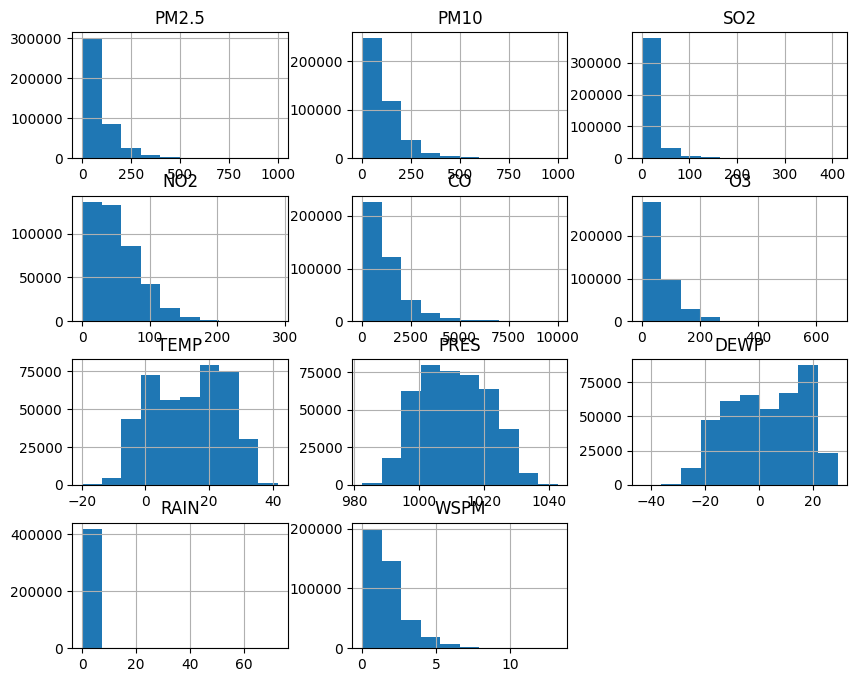

In [265]:
all_df.iloc[:, 1:-3].hist(figsize=(10, 8))
plt.show()

In [266]:
for col in all_df.columns:
    if not pd.api.types.is_numeric_dtype(all_df[col]): continue

    skew = all_df[col].skew()

    if skew < 0:
        print(f"{col} is left skewed ({skew:.2f})")
    elif skew > 0:
        print(f"{col} is right skewed ({skew:.2f})")
    else:
        print(f"{col} is symmetric ({skew:.2f})")

PM2.5 is right skewed (2.03)
PM10 is right skewed (1.93)
SO2 is right skewed (2.96)
NO2 is right skewed (1.05)
CO is right skewed (2.59)
O3 is right skewed (1.48)
TEMP is left skewed (-0.10)
PRES is right skewed (0.11)
DEWP is left skewed (-0.19)
RAIN is right skewed (30.06)
WSPM is right skewed (1.63)


### Data correlation

In [267]:
def show_corr_heatmap(df, title):
    corr_matrix = df.dropna().corr(numeric_only=True)
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm',
        vmin=-1, vmax=1,
        fmt=".2f"
    )
    plt.title(title, fontsize=16)
    plt.show()

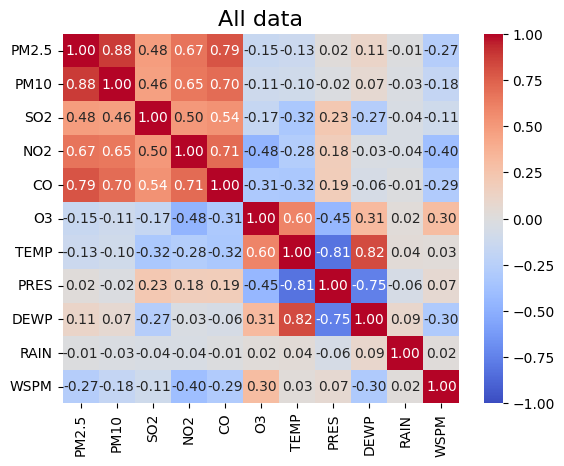

In [268]:
show_corr_heatmap(all_df, "All data")

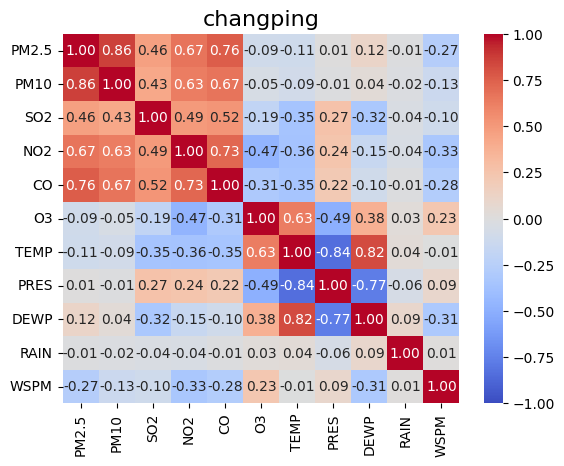

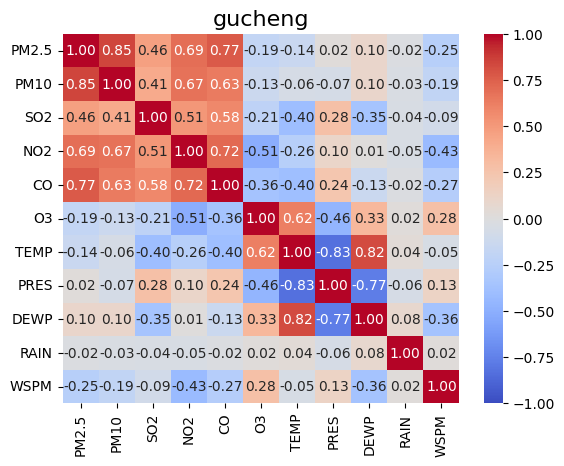

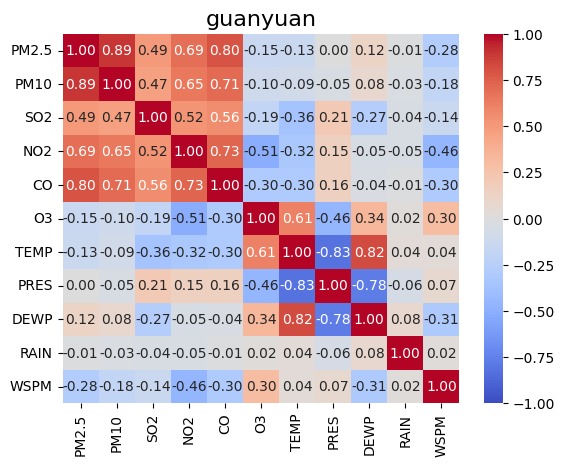

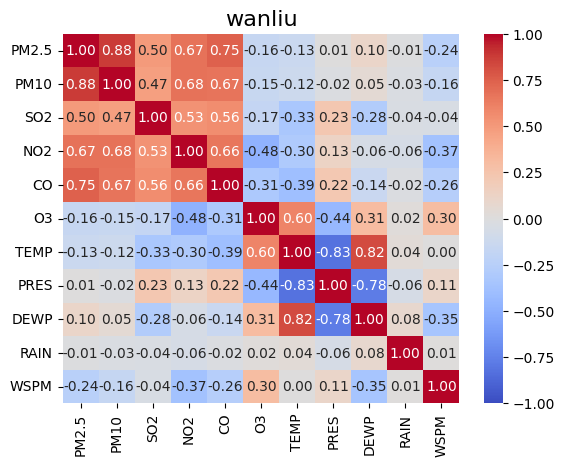

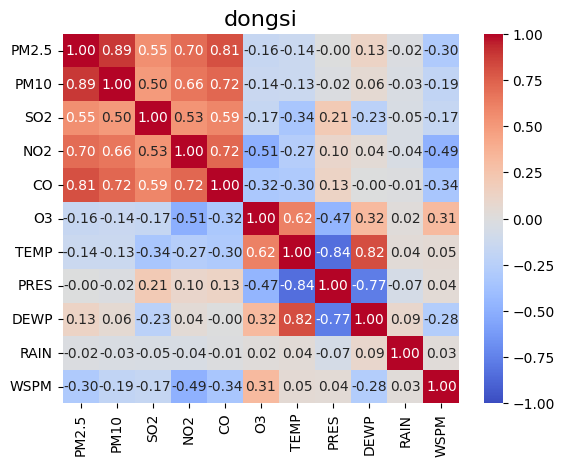

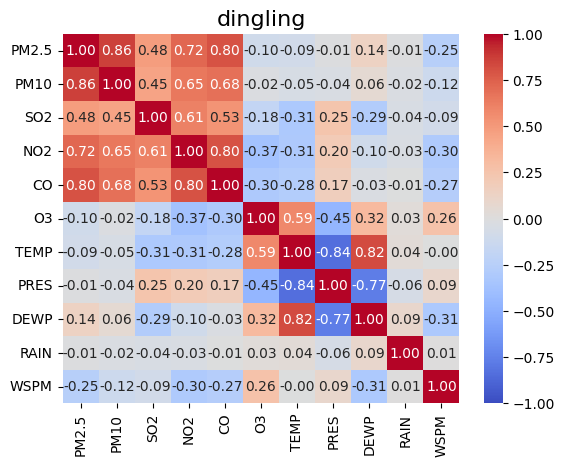

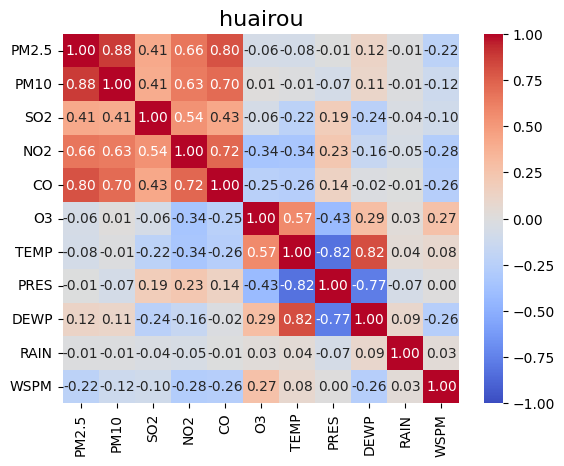

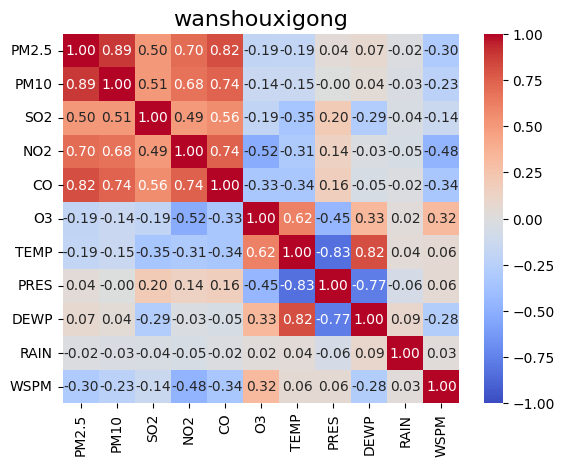

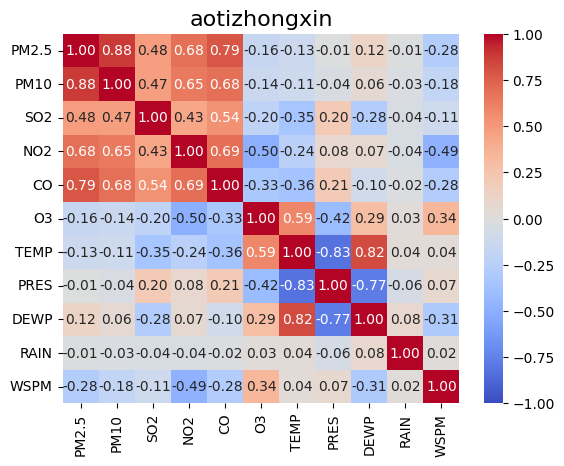

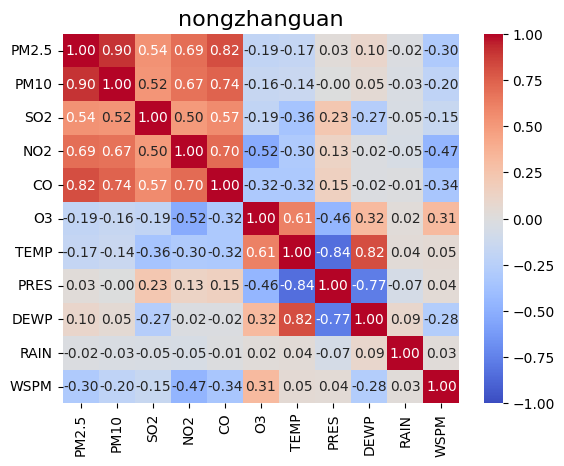

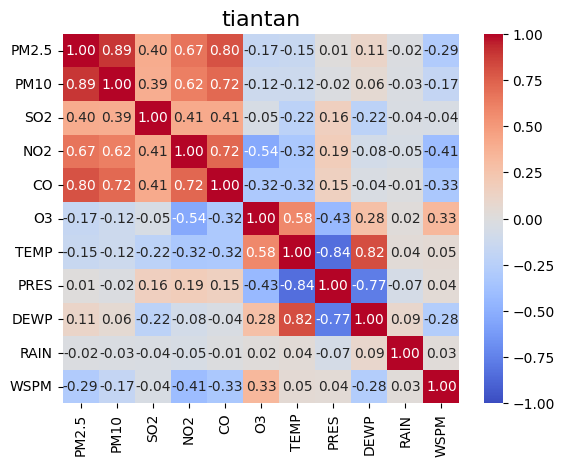

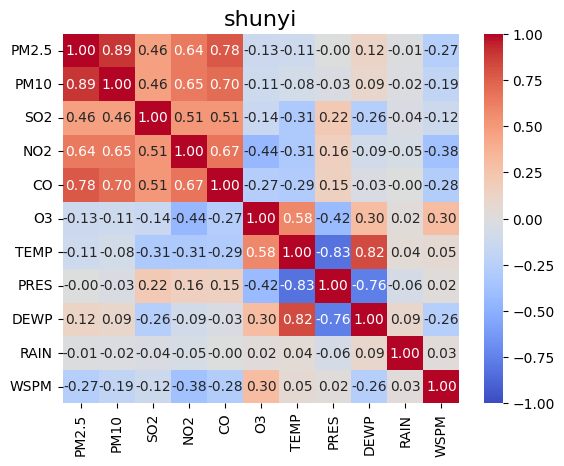

In [269]:
for keys in support_result_df_map.keys():
    show_corr_heatmap(all_df[all_df['station'].str.lower() == keys], keys)
    print()

### Grouping

In [270]:
def create_agg_dict(df, columns, agg_values):
    agg_dict = {}

    for col in columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            agg_dict[col] = agg_values

    return agg_dict

In [272]:
agg_dict = create_agg_dict(
    all_df, primary_params, ['max', 'mean', 'median']
)

all_df.groupby(
    ['station', all_df['date'].dt.year.rename('year')]
).agg(agg_dict)

PM2.5                          PM10              \
                           max        mean     median    max        mean   
station       year                                                         
Aotizhongxin  2013  665.000000   82.439202  62.000000  844.0  112.940836   
              2014  584.000000   91.141880  69.000000  948.0  122.372477   
              2015  657.000000   81.739530  55.000000  984.0  112.145896   
              2016  898.000000   73.990064  49.000000  884.0   94.538422   
              2017  713.000000   94.379237  46.000000  858.0  106.988347   
Changping     2013  443.000000   72.501294  52.000000  653.0   91.176675   
              2014  581.000000   79.834493  54.000000  999.0  106.768687   
              2015  500.000000   68.941369  44.000000  992.0   93.510717   
              2016  882.000000   61.648224  40.000000  933.0   86.568116   
              2017  662.000000   79.802966  38.000000  775.0   94.150777   
Dingling      2013  410.000000   64.946351  44.000000  720.0   78.504766   
              2014  548.000000   74.032951  46.000000  895.0   90.349994   
              2015  647.000000   64.424585  38.000000  905.0   85.456484   
              2016  881.000000   59.608033  37.000000  864.0   80.743558   
              2017  536.000000   68.281780  31.000000  553.0   78.526483   
Dongsi        2013  520.000000   86.542622  66.000000  602.0  104.735880   
              2014  737.000000   87.538893  65.000000  794.0  117.090114   
              2015  685.000000   87.165007  58.000000  816.0  112.116832   
              2016  695.000000   79.662963  54.000000  891.0  102.659767   
              2017  681.000000  102.411353  53.500000  955.0  131.802260   
Guanyuan      2013  512.000000   81.767633  61.000000  999.0  107.725014   
              2014  603.000000   88.108649  66.000000  814.0  115.855251   
              2015  680.000000   82.222457  56.000000  961.0  106.321067   
              2016  639.000000   76.883323  53.000000  906.0  104.638946   
              2017  671.525967   97.394948  53.000000  917.0  116.093573   
Gucheng       2013  500.000000   82.011364  62.000000  983.0  112.757149   
              2014  770.000000   89.446869  68.000000  862.0  133.981741   
              2015  741.000000   83.438480  56.000000  941.0  116.231199   
              2016  646.000000   77.365198  54.000000  986.0  111.050319   
              2017  767.000000  100.655524  52.000000  994.0  126.555085   
Huairou       2013  534.000000   68.502133  48.000000  887.0   94.686729   
              2014  528.000000   77.130807  54.000000  993.0   99.896383   
              2015  762.000000   70.376699  46.000000  991.0   90.165559   
              2016  683.000000   60.876138  39.000000  973.0   82.275918   
              2017  558.000000   73.865819  33.000000  750.0   91.704802   
Nongzhanguan  2013  844.000000   84.354927  63.000000  811.0  103.735090   
              2014  809.000000   90.982614  66.000000  907.0  126.287865   
              2015  667.000000   85.361695  55.000000  899.0  107.605560   
              2016  566.000000   76.041835  51.000000  995.0   96.956683   
              2017  835.000000  101.027542  53.000000  939.0  119.663842   
Shunyi        2013  558.000000   76.743363  57.646144  764.0   94.497958   
              2014  592.000000   84.237209  61.000000  903.0  111.021427   
              2015  689.000000   81.449201  54.000000  999.0  100.468088   
              2016  941.000000   71.095238  47.000000  917.0   87.337432   
              2017  762.000000   95.261299  47.000000  951.0  106.852754   
Tiantan       2013  525.000000   83.210172  63.000000  839.0  108.312704   
              2014  541.000000   86.229049  65.000000  894.0  114.488870   
              2015  671.000000   82.056815  55.000000  887.0  102.847580   
              2016  821.000000   73.801814  51.000000  988.0   97.260189   
              2017  808.000000   97.917373  56.000000  899.0  125.860876 

In [277]:
agg_dict = create_agg_dict(
    all_df, primary_params, ['max', 'mean', 'median']
)

all_df.groupby(
    ['station', 'season']
).agg(agg_dict)

PM2.5                      PM10                   
                        max        mean median    max        mean median
station       season                                                    
Aotizhongxin  Autumn  619.0   86.605028  59.00  671.0  110.202850   87.0
              Spring  665.0   81.220633  63.00  984.0  132.355189  116.0
              Summer  510.0   67.433310  54.00  564.0   81.339147   69.0
              Winter  898.0   96.389208  56.00  884.0  117.092188   80.0
Changping     Autumn  404.0   71.913372  47.00  858.0   90.651671   69.0
              Spring  510.0   71.398023  51.00  976.0  111.973255   94.0
              Summer  540.0   56.889821  40.00  544.0   71.444373   58.0
              Winter  882.0   84.097288  48.00  999.0  104.577147   72.0
Dingling      Autumn  414.0   66.619413  41.00  720.0   79.298468   57.0
              Spring  474.0   67.663567  47.00  895.0  103.499236   83.0
              Summer  368.0   53.066814  37.00  650.0   62.714968   49.0
              Winter  881.0   76.391974  35.25  905.0   89.599885   56.0
Dongsi        Autumn  685.0   88.159471  61.00  794.0  111.333173   86.0
              Spring  520.0   82.466911  65.00  891.0  124.623749  107.0
              Summer  515.0   70.418440  58.00  551.0   82.179587   72.0
              Winter  737.0  102.639563  60.00  955.0  122.811761   81.0
Guanyuan      Autumn  637.0   87.264469  60.00  999.0  108.909856   86.0
              Spring  428.0   77.436504  60.00  987.0  124.561623  110.0
              Summer  512.0   68.693973  56.00  509.0   85.528408   78.0
              Winter  680.0   98.440624  61.00  917.0  117.033980   82.0
Gucheng       Autumn  546.0   87.983852  60.00  699.0  116.963805   96.0
              Spring  533.0   80.696307  64.00  986.0  140.256878  127.0
              Summer  500.0   66.225578  52.00  862.0   96.828136   87.0
              Winter  770.0  100.719092  66.00  994.0  122.217359   91.0
Huairou       Autumn  422.0   69.935350  46.00  993.0   87.119425   65.5
              Spring  534.0   71.008598  53.00  835.0  109.256627   92.0
              Summer  384.0   56.912200  41.00  748.0   75.959282   61.0
              Winter  762.0   79.982941  45.00  991.0   94.412338   60.0
Nongzhanguan  Autumn  638.0   90.537714  61.00  742.0  112.130181   85.0
              Spring  844.0   78.644317  61.00  995.0  120.284318  105.0
              Summer  530.0   66.290634  54.00  492.0   80.970550   72.0
              Winter  835.0  104.405232  63.00  939.0  124.081833   84.0
Shunyi        Autumn  512.0   78.703239  54.00  762.0   97.933310   75.0
              Spring  558.0   78.037662  59.00  999.0  113.101098   98.0
              Summer  500.0   65.429332  52.00  624.0   77.375459   66.0
              Winter  941.0   94.616205  51.00  951.0  107.027043   68.0
Tiantan       Autumn  671.0   83.830987  59.00  671.0  104.191518   81.0
              Spring  498.0   75.848344  59.00  894.0  115.655797  100.0
              Summer  525.0   68.077225  55.00  641.0   84.428000   74.0
              Winter  821.0  100.266351  63.75  988.0  121.711807   85.0
Wanliu        Autumn  555.0   85.667382  58.00  599.0  109.693160   86.0
              Spring  500.0   79.282569  61.00  951.0  126.314521  110.0
              Summer  560.0   68.616429  55.00  615.0   86.037681   76.0
              Winter  957.0  100.002666  65.00  923.0  120.629213   89.0
Wanshouxigong Autumn  687.0   86.175037  60.00  704.0  111.971692   90.0
              Spring  433.0   78.709437  62.00  961.0  122.724139  108.0
              Summer  510.0   66.430382  55.00  732.0   84.185575   76.0
              Winter  999.0  108.333728  69.00  952.0  130.411577   92.0

In [273]:
agg_dict = create_agg_dict(
    all_df, secondary_params, ['median']
)

all_df.groupby(
    ['station', all_df['date'].dt.year.rename('year')]
).agg(agg_dict)

SO2      NO2           CO         O3
                   median   median       median     median
station       year                                        
Aotizhongxin  2013   14.0  60.0000   900.000000  33.201000
              2014   10.0  60.0000   900.000000  32.000000
              2015    7.0  53.0000   900.000000  50.000000
              2016    5.0  40.0000   800.000000  50.000000
              2017   14.0  62.0000   800.000000  49.000000
Changping     2013   10.0  35.0000   800.000000  48.000000
              2014    9.0  38.0000   800.000000  49.000000
              2015    4.0  34.0000   700.000000  48.000000
              2016    4.0  37.0000   800.000000  44.000000
              2017   12.0  42.0000   900.000000  34.000000
Dingling      2013    6.0  20.0000   700.000000  56.000000
              2014    6.0  19.0000   600.000000  63.000000
              2015    6.0  19.0000   600.000000  65.000000
              2016    3.0  17.0000   600.000000  64.000000
              2017   10.0  22.5000   600.000000  57.000000
Dongsi        2013   14.0  52.0000  1100.000000  47.000000
              2014   12.0  53.0000  1100.000000  44.000000
              2015    8.0  42.0000   900.000000  43.000000
              2016    6.0  43.0000   900.000000  46.000000
              2017   14.0  52.0000   900.000000  35.000000
Guanyuan      2013   12.0  53.0000   900.000000  39.488916
              2014   10.0  58.0000  1000.000000  38.000000
              2015    6.0  46.0000   900.000000  41.000000
              2016    6.0  46.0000   900.000000  41.000000
              2017   13.0  59.0000   800.000000  38.000000
Gucheng       2013    8.0  58.0000  1049.310650  44.062600
              2014    9.0  59.0000  1000.000000  43.000000
              2015    5.0  43.0000   900.000000  48.000000
              2016    4.0  43.0000   800.000000  47.000000
              2017   14.0  58.0000  1100.000000  27.000000
Huairou       2013    7.0  29.0000   800.000000  50.122800
              2014    6.0  30.0000   900.000000  57.000000
              2015    3.0  21.0000   700.000000  49.000000
              2016    3.0  20.0000   700.000000  42.000000
              2017    6.0  32.0000   900.000000  43.000000
Nongzhanguan  2013   13.0  54.0000  1032.592882  42.000000
              2014   12.0  57.0000  1000.000000  43.000000
              2015    8.0  48.0000   900.000000  47.000000
              2016    6.0  45.0000   900.000000  48.000000
              2017   13.0  54.0000   800.000000  34.000000
Shunyi        2013    6.0  35.0000  1000.000000  46.000000
              2014    7.0  39.0000   900.000000  43.000000
              2015    3.0  37.0000   800.000000  39.000000
              2016    3.5  34.0000   700.000000  48.000000
              2017   15.0  54.0000  1000.000000  43.000000
Tiantan       2013    9.0  49.0000  1000.000000  37.849600
              2014   10.0  50.0000  1000.000000  38.000000
              2015    6.0  44.0000   900.000000  44.000000
              2016    5.0  43.0000   800.000000  42.000000
              2017    9.0  59.0000   900.000000  31.000000
Wanliu        2013   15.0  65.2854  1000.000000  31.012648
              2014   13.0  71.0000   900.000000  24.000000
              2015    8.0  52.0000   900.000000  31.000000
              2016    4.0  52.0000   800.000000  38.000000
              2017   14.0  70.0000  1000.000000  30.000000
Wanshouxigong 2013   11.0  52.0000  1100.000000  38.000000
              2014    9.0  55.3000  1100.000000  40.166667
              2015    6.0  44.0000   900.000000  46.000000
              2016    4.0  43.0000   900.000000  44.000000
              2017   12.0  59.0000   900.000000  30.000000

In [279]:
agg_dict = create_agg_dict(
    all_df, secondary_params, ['max', 'median']
)

all_df.groupby(
    ['station', 'season']
).agg(agg_dict)

SO2                  NO2              CO  \
                           max   median         max median      max   
station       season                                                  
Aotizhongxin  Autumn  161.0000   6.0000  290.000000   65.0   9600.0   
              Spring  182.0000  14.0000  226.000000   50.0   6900.0   
              Summer  107.0000   4.0000  228.000000   44.0   9000.0   
              Winter  341.0000  21.0000  218.000000   61.0  10000.0   
Changping     Autumn  122.0000   4.0000  195.000000   45.0   9100.0   
              Spring  310.0000   9.0000  199.000000   38.0   6500.0   
              Summer  160.0000   2.0000  188.000000   25.0   5000.0   
              Winter  257.0000  18.0000  226.000000   51.0  10000.0   
Dingling      Autumn  124.2360   4.0000  190.313100   22.0   5800.0   
              Spring  131.0000   7.0000  184.000000   22.0   6900.0   
              Summer   89.0000   3.0000   93.341857   14.0   7000.0   
              Winter  156.0000  15.0000  205.000000   26.0  10000.0   
Dongsi        Autumn  196.0000   8.0000  256.000000   57.0   9600.0   
              Spring  198.0000  14.0000  258.000000   44.0   6800.0   
              Summer  109.0992   4.5696  160.000000   38.0  10000.0   
              Winter  300.0000  22.0000  213.209249   57.0  10000.0   
Guanyuan      Autumn  170.0000   6.0000  239.000000   59.0   9800.0   
              Spring  189.0000  13.0000  270.000000   49.0   6799.0   
              Summer  240.0000   4.0000  149.000000   39.0  10000.0   
              Winter  293.0000  22.0000  225.000000   66.0  10000.0   
Gucheng       Autumn  124.0000   4.0000  226.000000   57.0   8100.0   
              Spring  248.0000  12.0000  240.000000   52.0   9800.0   
              Summer  227.0000   2.0000  200.000000   38.0   9000.0   
              Winter  247.0000  22.0000  276.000000   62.0  10000.0   
Huairou       Autumn  193.0000   3.0000  231.000000   28.0   6000.0   
              Spring  160.0000   8.0000  219.000000   28.0   8000.0   
              Summer  120.0000   3.0000   94.000000   16.0  10000.0   
              Winter  315.0000  11.0000  174.000000   40.0  10000.0   
Nongzhanguan  Autumn  234.0000   8.0000  239.000000   59.0   9900.0   
              Spring  202.0000  14.0000  273.000000   52.0   7300.0   
              Summer  105.0000   4.0000  201.000000   38.0  10000.0   
              Winter  257.0000  22.0000  265.000000   63.0  10000.0   
Shunyi        Autumn  162.0000   3.0000  207.000000   42.0   9900.0   
              Spring  207.0000   9.0000  238.000000   43.0   8000.0   
              Summer   77.0000   2.0000  161.000000   25.0  10000.0   
              Winter  239.0000  16.0000  258.000000   49.0  10000.0   
Tiantan       Autumn  273.0000   4.0000  206.000000   54.0   9300.0   
              Spring  230.0000  11.0000  230.000000   43.0   8199.0   
              Summer   92.0000   4.0000  192.000000   36.0  10000.0   
              Winter  202.0000  14.0000  241.000000   62.0  10000.0   
Wanliu        Autumn  121.0000   8.0000  239.000000   63.0   8300.0   
              Spring  183.0000  13.0000  253.000000   66.0  10000.0   
              Summer  141.6576   5.7120  168.000000   45.0  10000.0   
              Winter  282.0000  23.0000  264.000000   75.0  10000.0   
Wanshouxigong Autumn  174.0000   5.0000  218.000000   58.0   9500.0   
              Spring  245.0000  12.0000  241.000000   46.0   8599.0   
              Summer  120.0000   3.0000  215.000000   37.0   9000.0   
              Winter  411.0000  21.0000  251.000000   63.0   9800.0   

                                         O3             
                           median       max     median  
station       season                                    
Aotizhongxin  Autumn  1000.000000  267.0000  15.000000  
              Spring   800.000000  342.0000  62.000000  
              Summer   700.000000  423.0000  79.000000  
              Winter  1300.000000  216.0000  20.000000  
Changp

### Insight

- Measuring Asymmetric
    - PM2.5 is right skewed
    - PM10 is right skewed
    - SO2 is right skewed
    - NO2 is right skewed
    - CO is right skewed
    - O3 is right skewed
    - TEMP is left skewed
    - PRES is right skewed
    - DEWP is left skewed
    - RAIN is right skewed
    - WSPM is right skewed
- Data correlation (Urutan data yang paling mempengaruhi polutan)
    - PM2.5: PM10, CO, NO2, SO2
    - PM10: PM2.5, CO, NO2, SO2
    - TEMP: DEWP, PRES (berbanding terbalik)
- Dari grouping
    - Per station dan per tahun, data median menunjukkan bahwa PM2.5 & PM10 cenderung menurun setiap tahunnya.
    - Per station dan per musim, data median menunjukkan bahwa PM 10 cenderung paling tinggi di musim Spring

## Visualization & Explanatory Analysis

In [290]:
# =====================================================================
# Helper: pastikan kolom bantu (year, season) tersedia
# =====================================================================
def _ensure_time_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "date" not in df.columns:
        raise ValueError("Kolom 'datetime' tidak ditemukan di dataframe.")
    df["date"] = pd.to_datetime(df["date"])

    if "year" not in df.columns:
        df["year"] = df["date"].dt.year
    if "month" not in df.columns:
        df["month"] = df["date"].dt.month

    return df


# =====================================================================
# 1. Heatmap korelasi - 1 station, seluruh tahun digabung
# =====================================================================
def plot_correlation_heatmap_station(
    df: pd.DataFrame,
    parameters: list,
    station_name: str = None,
    figsize: tuple = (8, 6),
):
    """
    Menampilkan heatmap korelasi untuk 1 station (seluruh tahun digabung).

    Parameters:
        df           : dataframe (idealnya sudah difilter 1 station)
        parameters   : list nama kolom numerik yang ingin dikorelasikan
        station_name : nama station untuk judul plot (opsional, akan
                        dideteksi otomatis dari kolom 'station' jika ada
                        dan tidak diisi manual)
        figsize      : ukuran gambar
        save_path    : path penyimpanan file
    """
    if station_name is None and "station" in df.columns:
        unique_stations = df["station"].unique()
        station_name = unique_stations[0] if len(unique_stations) == 1 else "Multiple Stations"

    corr_matrix = df[parameters].corr()

    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, square=True, linewidths=0.5)
    plt.title(f"Korelasi Parameter - Station: {station_name}")
    plt.tight_layout()
    plt.show()


# =====================================================================
# 2. Heatmap korelasi PER TAHUN - 1 station, subplot per tahun
# =====================================================================
def plot_correlation_heatmap_per_year(
    df: pd.DataFrame,
    parameters: list,
    station_name: str = None,
    ncols: int = 3,
    figsize_per_plot: tuple = (5, 4.5),
):
    """
    Menampilkan heatmap korelasi untuk 1 station, dipecah per tahun
    (subplot terpisah untuk tiap tahun), agar terlihat apakah kekuatan
    hubungan antar faktor berubah dari tahun ke tahun.

    Parameters:
        df           : dataframe (idealnya sudah difilter 1 station),
                        harus punya kolom 'datetime'
        parameters   : list nama kolom numerik yang ingin dikorelasikan
        station_name : nama station untuk judul (opsional)
        ncols        : jumlah kolom grid subplot
        figsize_per_plot : ukuran per subplot
        save_path    : path penyimpanan file
    """
    df = _ensure_time_columns(df)

    if station_name is None and "station" in df.columns:
        unique_stations = df["station"].unique()
        station_name = unique_stations[0] if len(unique_stations) == 1 else "Multiple Stations"

    years = sorted(df["year"].unique())
    n_years = len(years)
    nrows = int(np.ceil(n_years / ncols))

    fig_width = figsize_per_plot[0] * ncols
    fig_height = figsize_per_plot[1] * nrows

    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height))
    axes = np.array(axes).reshape(nrows, ncols).flatten(order="C")

    for i, year in enumerate(years):
        df_year = df[df["year"] == year]
        corr_matrix = df_year[parameters].corr()

        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
                    vmin=-1, vmax=1, square=True, linewidths=0.5,
                    ax=axes[i], cbar=(i == 0), annot_kws={"size": 7})
        axes[i].set_title(f"Tahun {year}")
        axes[i].tick_params(axis="both", labelsize=7)

    for j in range(n_years, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Korelasi Parameter per Tahun - Station: {station_name}", fontsize=14)
    plt.tight_layout()
    plt.show()


# =====================================================================
# 3. Scatter plot faktor kunci (misal TEMP vs PM2.5, WSPM vs NO2, dst)
# =====================================================================
def plot_scatter_key_factors(
    df: pd.DataFrame,
    pairs: list,
    station_name: str = None,
    ncols: int = 3,
    figsize_per_plot: tuple = (5, 4),
    sample_frac: float = None,
):
    """
    Menampilkan scatter plot untuk pasangan (x, y) parameter tertentu,
    untuk memvalidasi apakah hubungan antar faktor benar-benar linear
    atau punya pola lain (non-linear, threshold effect, dsb).

    Parameters:
        df           : dataframe (idealnya sudah difilter 1 station)
        pairs        : list of tuple (x_col, y_col), misal:
                        [("TEMP", "PM2.5"), ("WSPM", "NO2"), ("RAIN", "PM2.5")]
        station_name : nama station untuk judul (opsional)
        ncols        : jumlah kolom grid subplot
        figsize_per_plot : ukuran per subplot
        sample_frac  : opsional, ambil sampel sebagian data (0-1) supaya
                        scatter tidak terlalu padat/berat untuk data besar
        save_path    : path penyimpanan file
    """
    if station_name is None and "station" in df.columns:
        unique_stations = df["station"].unique()
        station_name = unique_stations[0] if len(unique_stations) == 1 else "Multiple Stations"

    plot_df = df.sample(frac=sample_frac, random_state=42) if sample_frac else df

    n_pairs = len(pairs)
    nrows = int(np.ceil(n_pairs / ncols))

    fig_width = figsize_per_plot[0] * ncols
    fig_height = figsize_per_plot[1] * nrows

    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height))
    axes = np.array(axes).reshape(nrows, ncols).flatten(order="C")

    for i, (x_col, y_col) in enumerate(pairs):
        if x_col not in plot_df.columns or y_col not in plot_df.columns:
            print(f"Peringatan: '{x_col}' atau '{y_col}' tidak ditemukan, dilewati.")
            axes[i].axis("off")
            continue

        sns.scatterplot(data=plot_df, x=x_col, y=y_col, ax=axes[i],
                         alpha=0.3, s=10, color="steelblue")

        # Tambahkan garis tren sederhana (regresi linear) sebagai bantuan visual
        sns.regplot(data=plot_df, x=x_col, y=y_col, ax=axes[i],
                    scatter=False, color="red", line_kws={"linewidth": 1.5})

        corr_val = plot_df[[x_col, y_col]].corr().iloc[0, 1]
        axes[i].set_title(f"{x_col} vs {y_col}\n(corr: {corr_val:.2f})")

    for j in range(n_pairs, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Scatter Plot Faktor Kunci - Station: {station_name}", fontsize=14)
    plt.tight_layout()
    plt.show()


# =====================================================================
# 4. Boxplot per musim
# =====================================================================
def plot_boxplot_by_season(
    df: pd.DataFrame,
    parameters: list,
    station_name: str = None,
    season_order: list = None,
    ncols: int = 3,
    figsize_per_plot: tuple = (5, 4),
):
    """
    Menampilkan boxplot untuk tiap parameter, dikelompokkan per musim,
    untuk melihat pola musiman (misal dugaan heating season musim dingin).

    Parameters:
        df           : dataframe (idealnya sudah difilter 1 station),
                        harus punya kolom 'datetime'
        parameters   : list nama kolom numerik yang ingin ditampilkan
        station_name : nama station untuk judul (opsional)
        season_order : urutan musim pada sumbu-x, default
                        ["Spring", "Summer", "Autumn", "Winter"]
        ncols        : jumlah kolom grid subplot
        figsize_per_plot : ukuran per subplot
    """
    df = _ensure_time_columns(df)

    if station_name is None and "station" in df.columns:
        unique_stations = df["station"].unique()
        station_name = unique_stations[0] if len(unique_stations) == 1 else "Multiple Stations"

    if season_order is None:
        season_order = ["Spring", "Summer", "Autumn", "Winter"]

    n_params = len(parameters)
    nrows = int(np.ceil(n_params / ncols))

    fig_width = figsize_per_plot[0] * ncols
    fig_height = figsize_per_plot[1] * nrows

    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height))
    axes = np.array(axes).reshape(nrows, ncols).flatten(order="C")

    for i, col in enumerate(parameters):
        if col not in df.columns:
            print(f"Peringatan: kolom '{col}' tidak ditemukan, dilewati.")
            axes[i].axis("off")
            continue

        sns.boxplot(data=df, x="season", y=col, order=season_order,
                    ax=axes[i], color="lightgreen")
        axes[i].set_title(col)
        axes[i].tick_params(axis="x", rotation=30)

    for j in range(n_params, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Distribusi Parameter per Musim - Station: {station_name}", fontsize=14)
    plt.tight_layout()
    plt.show()


### Pertanyaan 1: Faktor apa saja yang memengaruhi tingginya konsentrasi polutan di setiap station tiap tahun?

#### Visualization

##### Station aotizhongxin

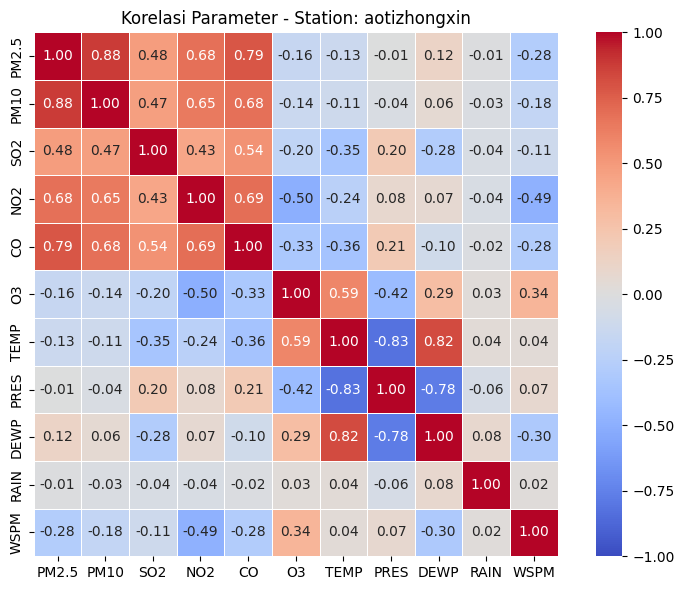

In [291]:
station_name = 'aotizhongxin'
station_df = all_df[all_df['station'].str.lower() == station_name]
plot_correlation_heatmap_station(station_df, all_params, station_name)

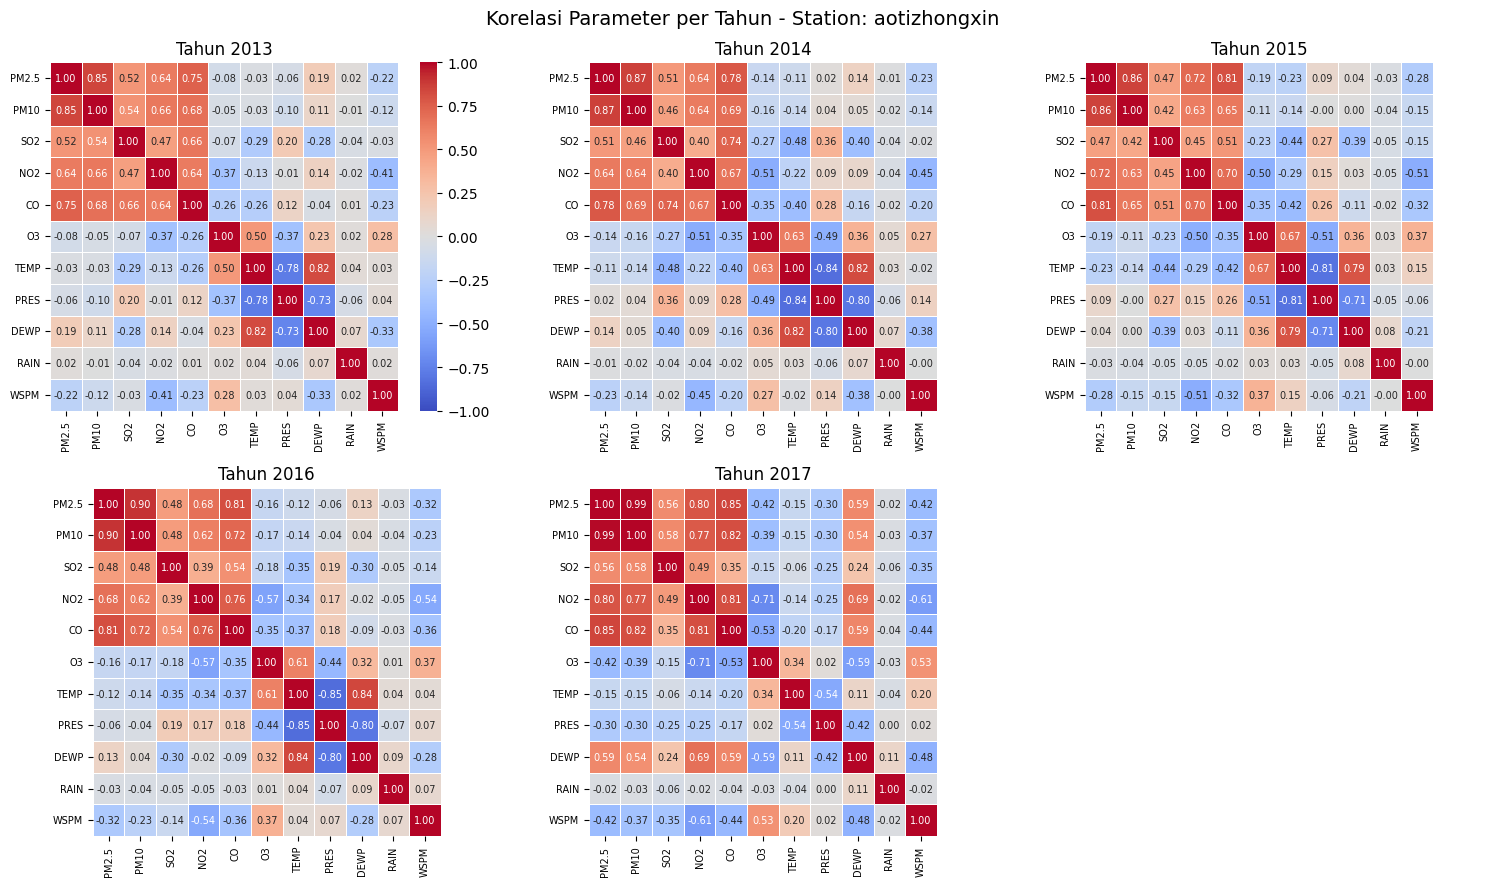

In [287]:
plot_correlation_heatmap_per_year(station_df, all_params, station_name)

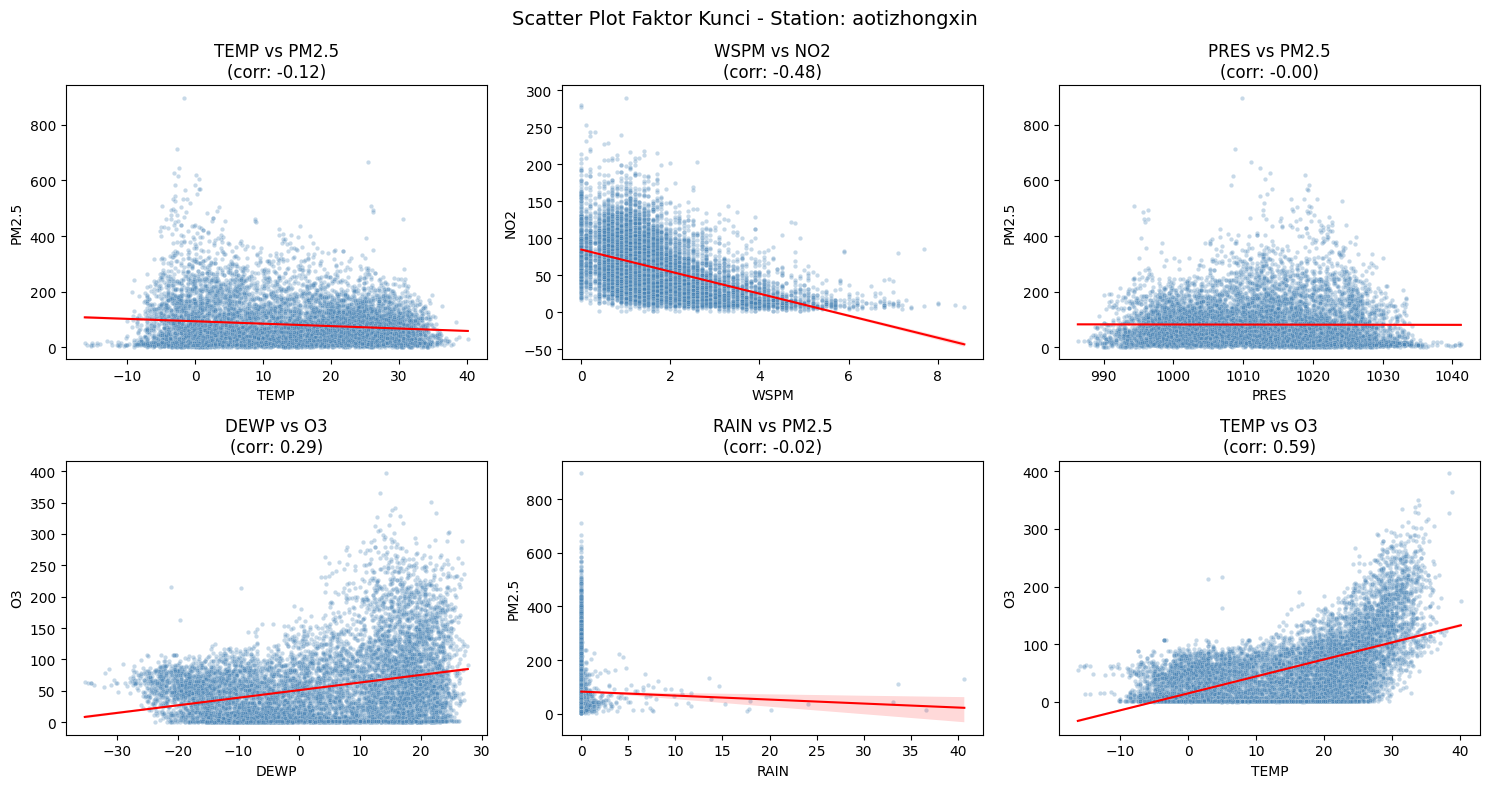

In [297]:
key_pairs = [
    ("TEMP", "PM2.5"), ("WSPM", "NO2"), ("PRES", "PM2.5"),
    ("DEWP", "O3"), ("RAIN", "PM2.5"), ("TEMP", "O3"),
]
plot_scatter_key_factors(station_df, key_pairs, station_name, sample_frac=0.3)

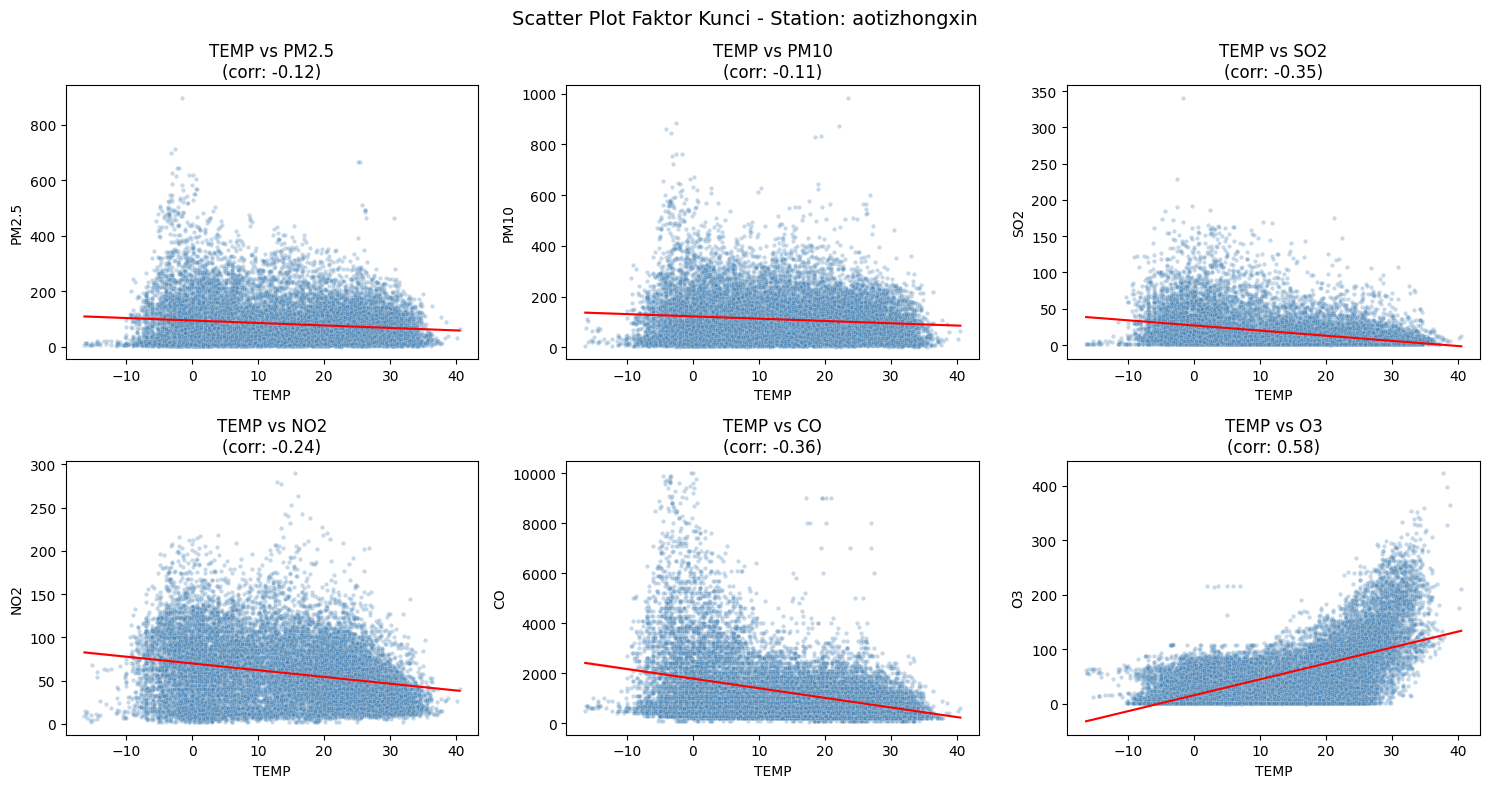

In [299]:
key_pairs = [
    ("TEMP", "PM2.5"), ("TEMP", "PM10"), ("TEMP", "SO2"),
    ("TEMP", "NO2"), ("TEMP", "CO"), ("TEMP", "O3")
]
plot_scatter_key_factors(station_df, key_pairs, station_name, sample_frac=0.5)

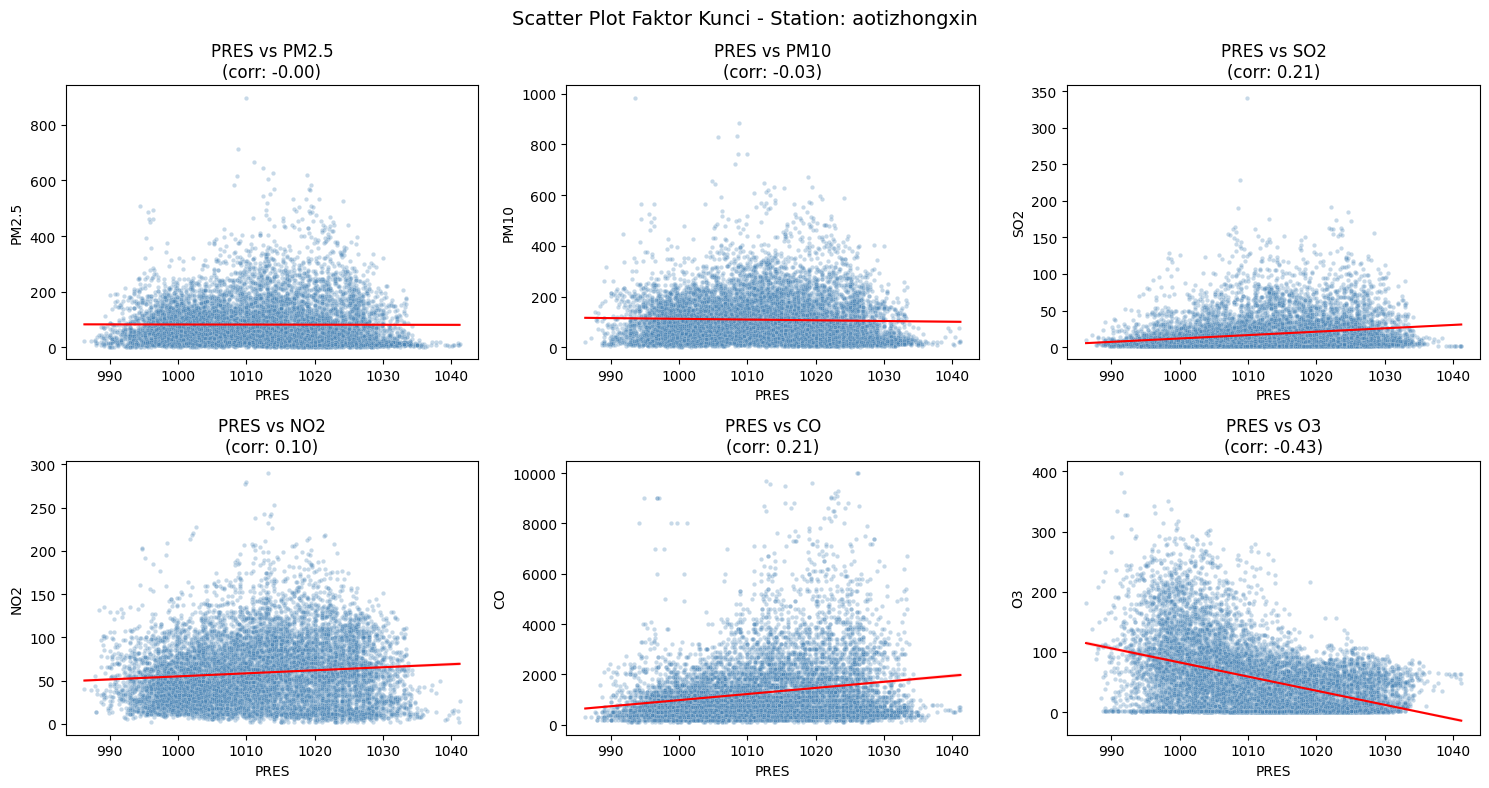

In [300]:
key_pairs = [
    ("PRES", "PM2.5"), ("PRES", "PM10"), ("PRES", "SO2"),
    ("PRES", "NO2"), ("PRES", "CO"), ("PRES", "O3")
]
plot_scatter_key_factors(station_df, key_pairs, station_name, sample_frac=0.3)

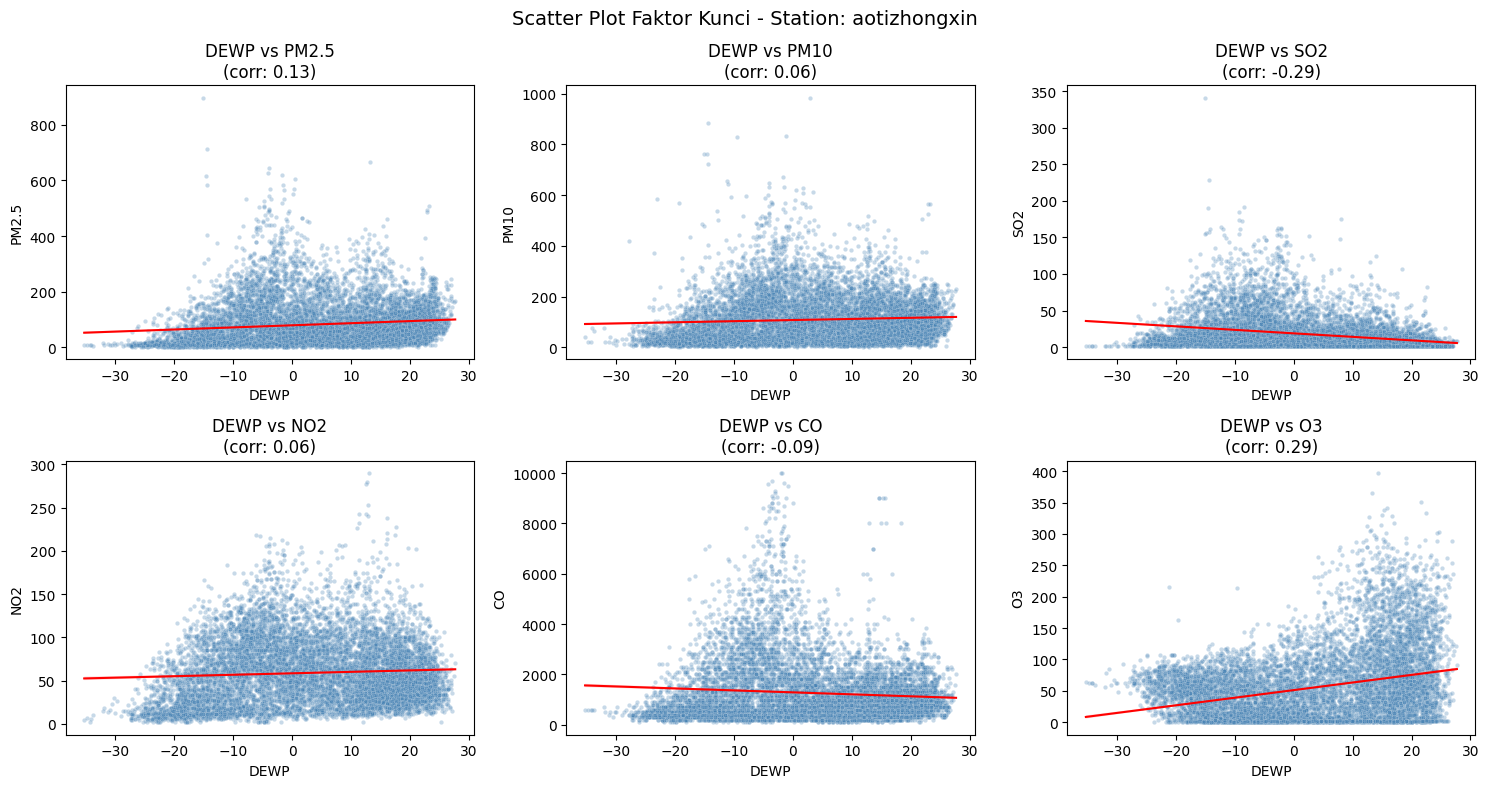

In [301]:
key_pairs = [
    ("DEWP", "PM2.5"), ("DEWP", "PM10"), ("DEWP", "SO2"),
    ("DEWP", "NO2"), ("DEWP", "CO"), ("DEWP", "O3")
]
plot_scatter_key_factors(station_df, key_pairs, station_name, sample_frac=0.3)

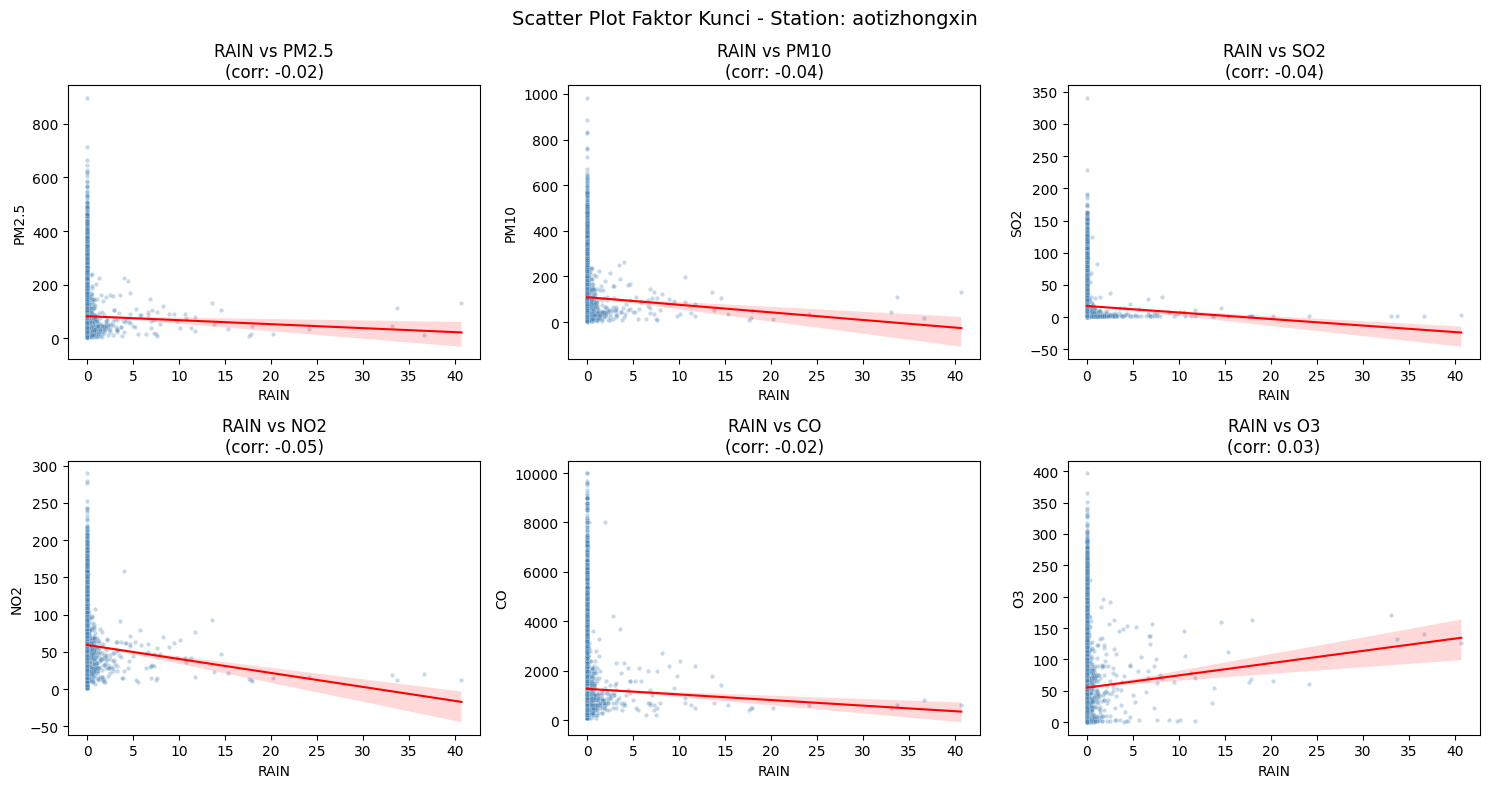

In [302]:
key_pairs = [
    ("RAIN", "PM2.5"), ("RAIN", "PM10"), ("RAIN", "SO2"),
    ("RAIN", "NO2"), ("RAIN", "CO"), ("RAIN", "O3")
]
plot_scatter_key_factors(station_df, key_pairs, station_name, sample_frac=0.3)

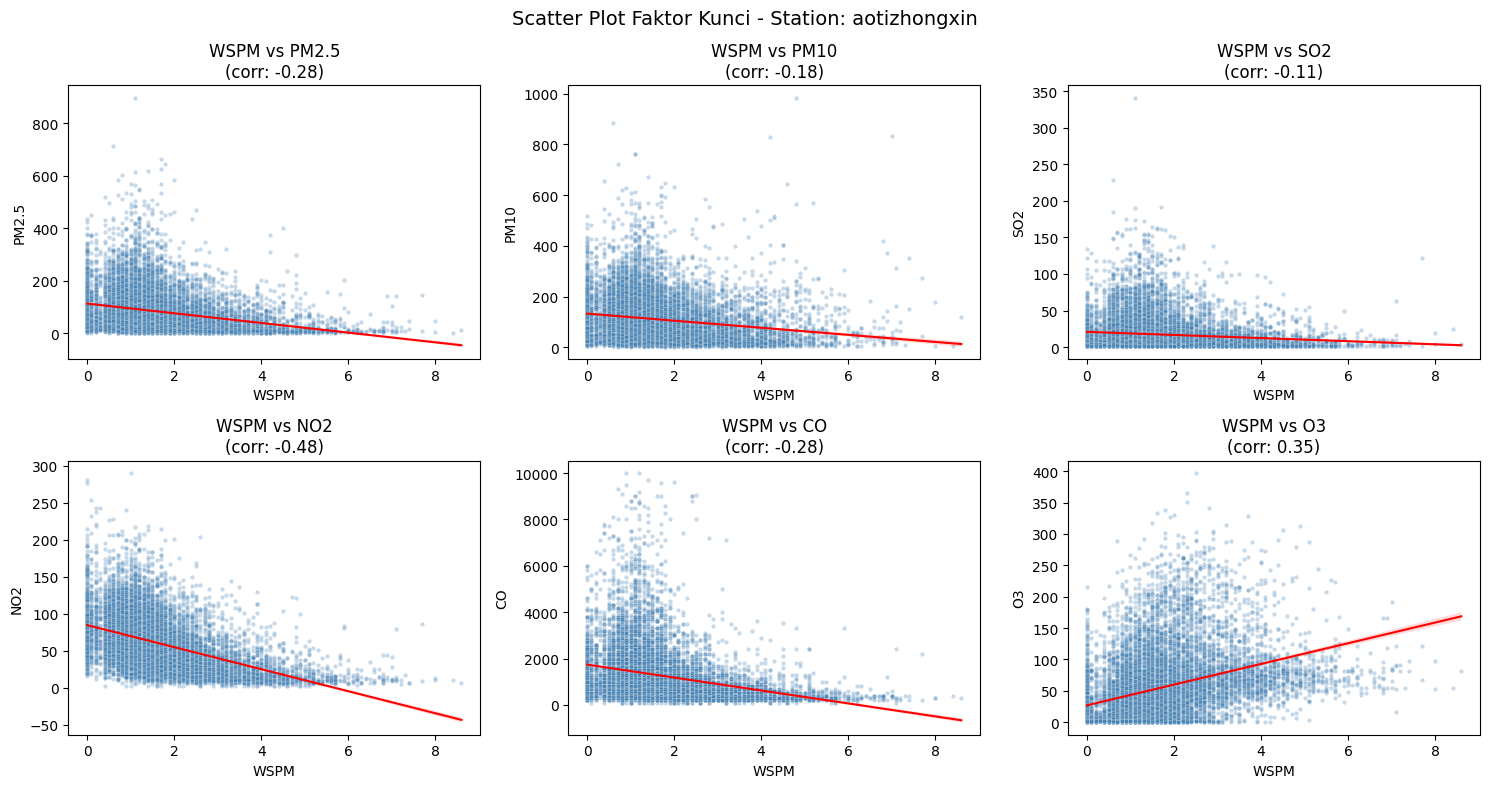

In [303]:
key_pairs = [
    ("WSPM", "PM2.5"), ("WSPM", "PM10"), ("WSPM", "SO2"),
    ("WSPM", "NO2"), ("WSPM", "CO"), ("WSPM", "O3")
]
plot_scatter_key_factors(station_df, key_pairs, station_name, sample_frac=0.3)

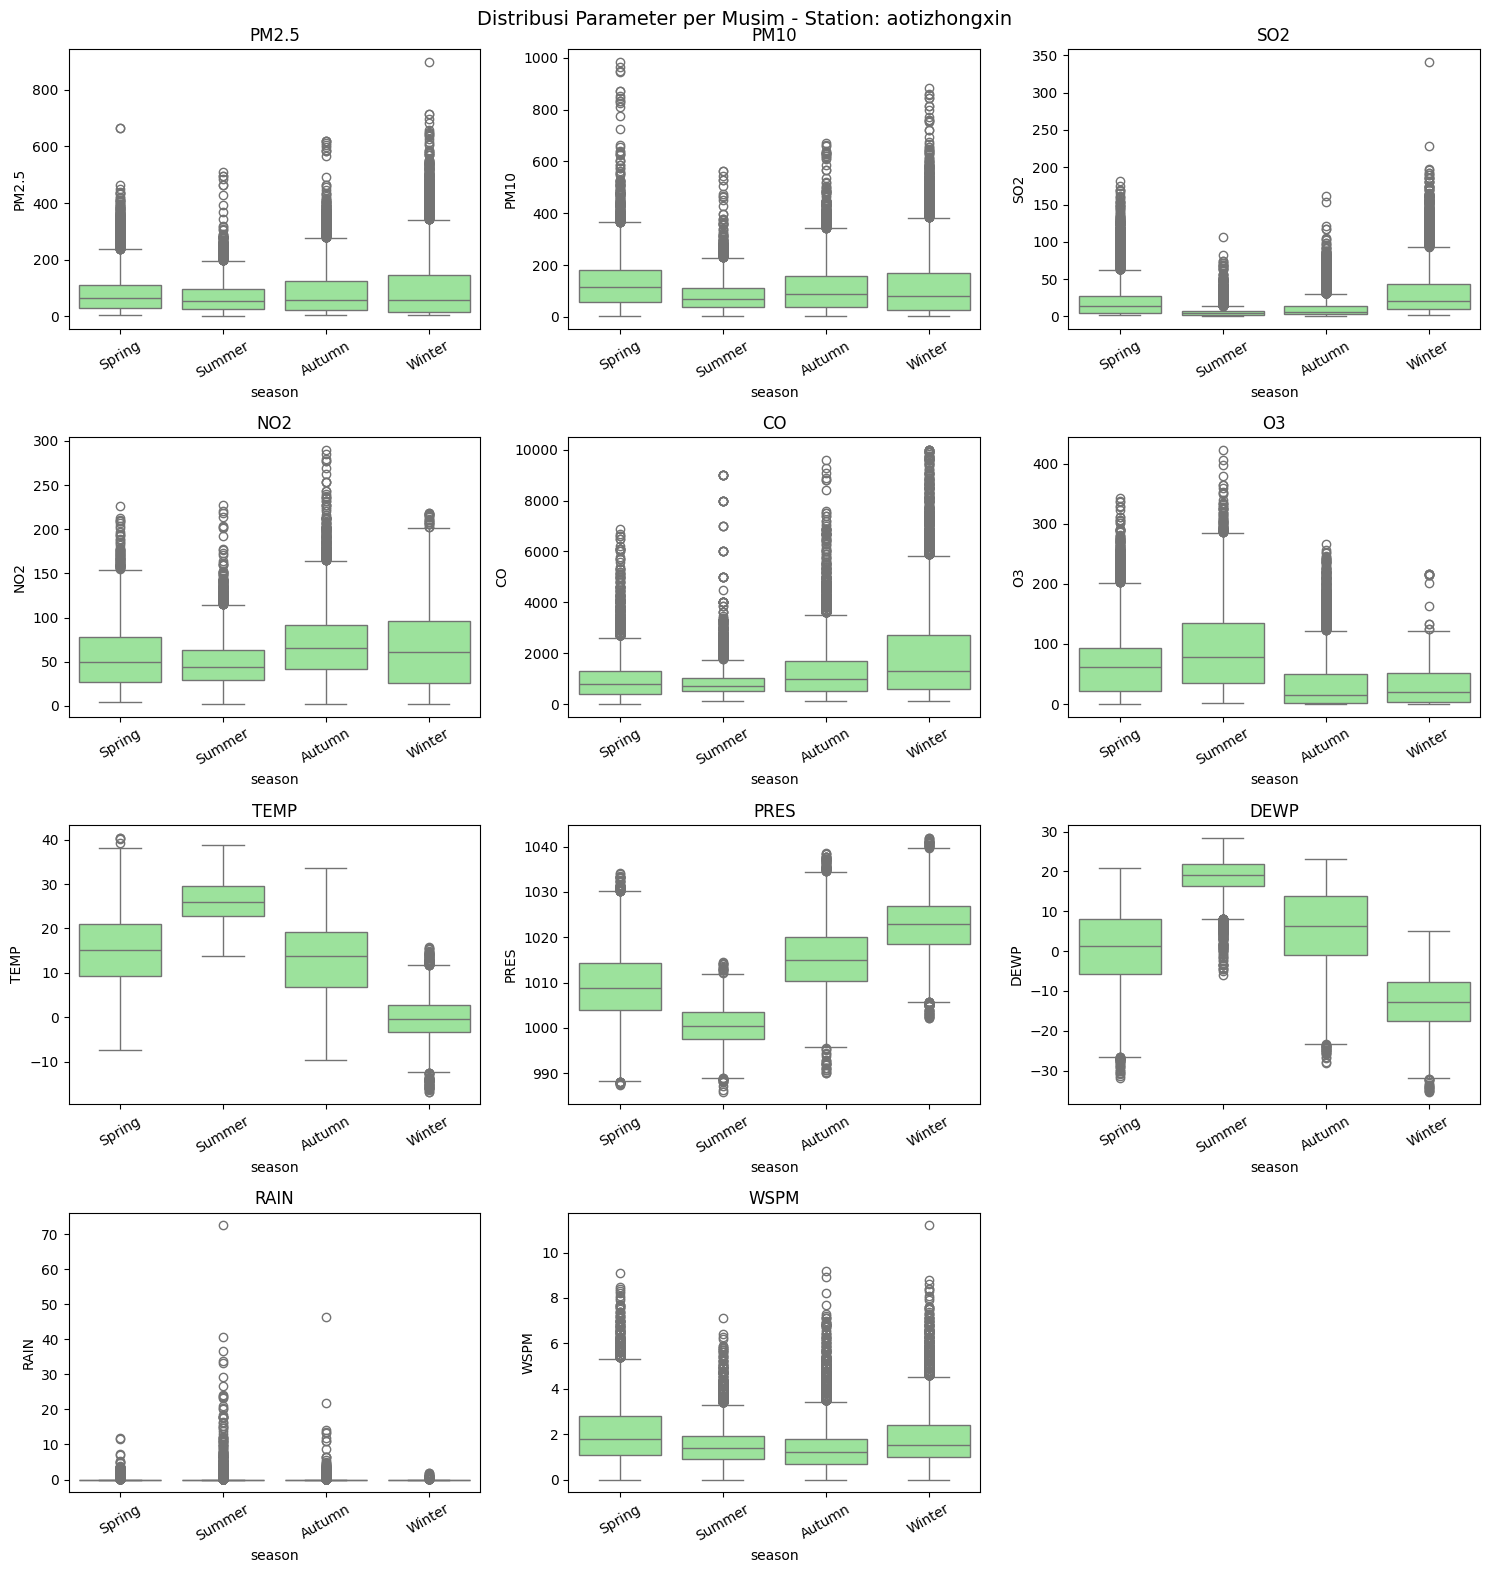

In [296]:
plot_boxplot_by_season(station_df, all_params, station_name)

##### Station nongzhanguan

##### Station dongsi

##### Station wanshouxigong

##### Station dingling

##### Station wanliu

##### Station changping

##### Station guanyuan

##### Station huairou

##### Station tiantan

##### Station gucheng

##### Station shunyi

#### Explanatory Analysis

### Pertanyaan 2: Apakah konsentrasi rata-rata polutan menunjukkan perbaikan kualitas udara dari 2013-207 di setiap station?

#### Visualization

##### Station aotizhongxin

##### Station nongzhanguan

##### Station dongsi

##### Station wanshouxigong

##### Station dingling

##### Station wanliu

##### Station changping

##### Station guanyuan

##### Station huairou

##### Station tiantan

##### Station gucheng

##### Station shunyi

#### Explanatory analysis

**Insight:** (Opsional)
- xxx
- xxx

## Analisis Lanjutan (Opsional)

**Insight:** (Opsional)
- xxx
- xxx

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** xxx
- **Conclusion pertanyaan 2:** xxx
- ...

**Rekomendasi Action Item:**
- xxx
- xxx